# Category 3 : Prescriptive Analysis Questions

In [1]:
# Install Seaborn if needed.

!pip install pandas numpy matplotlib seaborn plotly
#Install Advanced Visualisation Libraries
!pip install bokeh altair holoviews hvplot
!pip install networkx squarify wordcloud
!pip install scipy statsmodels scikit-learn
!pip install streamlit
!pip install dash dash-bootstrap-components
!pip install panel


In [3]:
#Importing all the Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots




# Advanced Visualisation
import networkx as nx
import squarify
from wordcloud import WordCloud


# Dashboarding
import streamlit as st
import dash
import panel as pn

<p style="font-family: Cambria; font-size: 20px;"><b>Read the Datasets</b></p>

In [5]:
# Define the main project folder
project_folder = Path(
    r'C:\Neha Career\Numpy Ninja\Python\Python Hackthon\Hackthon 2026\Python_Hackathon_Sep_2026\cardiac_failure'
)

# Define the folder containing the original datasets
raw_data_folder = project_folder / "raw_data"

# Define the folder for cleaned datasets and reports
output_folder = project_folder / "cleaned_data"

# Create the output folder if it does not already exist
output_folder.mkdir(exist_ok=True)

print("Project Folder:", project_folder)
print("Raw Data Folder:", raw_data_folder)
print("Output Folder:", output_folder)

Project Folder: C:\Neha Career\Numpy Ninja\Python\Python Hackthon\Hackthon 2026\Python_Hackathon_Sep_2026\cardiac_failure
Raw Data Folder: C:\Neha Career\Numpy Ninja\Python\Python Hackthon\Hackthon 2026\Python_Hackathon_Sep_2026\cardiac_failure\raw_data
Output Folder: C:\Neha Career\Numpy Ninja\Python\Python Hackthon\Hackthon 2026\Python_Hackathon_Sep_2026\cardiac_failure\cleaned_data


In [6]:
# Read the original Demography dataset
demo = pd.read_csv(output_folder / "Team7_CodeAvengers_Category1_DataCleaning_demography.csv")
labs = pd.read_csv(output_folder / "Team7_CodeAvengers_Category1_DataCleaning_labs.csv")
cc = pd.read_csv(output_folder / "Team7_CodeAvengers_Category1_DataCleaning_cardiac_complications.csv")
resp = pd.read_csv(output_folder / "Team7_CodeAvengers_Category1_DataCleaning_responsivenes.csv")
pp = pd.read_csv(output_folder / "Team7_CodeAvengers_Category1_DataCleaning_patient_precriptions.csv")
ph = pd.read_csv(output_folder / "Team7_CodeAvengers_Category1_DataCleaning_patienthistory_cleaned.csv")
hd = pd.read_csv(output_folder / "Team7_CodeAvengers_Category1_DataCleaning_hospitalization_discharge.csv")

# Demography : Display the first five records
print("Demography Table")
display(demo.head())

# Responsivenes :  Display the first five records
print("Responsivees Table")
display(resp.head())

# Labs : Display the first five records
print("Labs Table")
display(labs.head())

# Cardiac Condition : Display the first five records
print("Cardiac Condition Table")
display(cc.head())

# Patients Prescription : Display the first five records
print("Patients Prescription Table")
display(pp.head())

# Patient History : Display the first five records
print("Patients History Table")
display(ph.head())

# Hospitalization Discharge : Display the first five records
print("Patients History Table")
display(hd.head())


Demography Table


,inpatient_number,gender,weight,height,bmi,occupation,agecat
0,827040,Female,50.0,1.45,23.781213,Unknown,69-79
1,857781,Male,50.0,1.64,18.590125,UrbanResident,69-79
2,743087,Female,51.0,1.63,19.195303,UrbanResident,69-79
3,866418,Male,70.0,1.70,24.221453,farmer,59-69
4,775928,Male,65.0,1.70,22.491349,UrbanResident,69-79


Responsivees Table


,inpatient_number,eye_opening,verbal_response,movement,consciousness,gcs
0,857781,4,5,6,Clear,15
1,743087,4,5,6,Clear,15
2,866418,4,5,6,Clear,15
3,775928,4,5,6,Clear,15
4,810128,4,5,6,Clear,15


Labs Table


...

,inpatient_number,drug_name
0,857781,Sulfotanshinone sodium injection
1,857781,Furosemide tablet
2,857781,Enoxaparin Sodium injection
3,857781,Meglumine Adenosine Cyclophosphate for injection
4,857781,Furosemide injection


Patients History Table


,inpatient_number,cerebrovascular_disease,dementia,chronic_obstructive_pulmonary_disease,connective_tissue_disease,peptic_ulcer_disease,diabetes,moderate_to_severe_chronic_kidney_disease,hemiplegia,leukemia,malignant_lymphoma,solid_tumor,liver_disease,aids,cci_score,type_ii_respiratory_failure,acute_renal_failure
0,857781,0,0,1,0,0.0,1,0.0,0,0,0,0,0.0,0,2.0,nontypeii,0
1,743087,0,0,0,0,0.0,0,0.0,0,0,0,0,0.0,0,0.0,nontypeii,0
2,866418,0,0,0,0,0.0,0,0.0,0,0,0,0,0.0,0,0.0,nontypeii,0
3,775928,0,0,1,0,0.0,0,1.0,0,0,0,0,0.0,0,2.0,nontypeii,0
4,810128,0,0,0,0,0.0,0,0.0,0,0,0,0,0.0,0,0.0,nontypeii,0


Patients History Table


,inpatient_number,destinationdischarge,admission_ward,admission_way,discharge_department,visit_times,respiratory_support,oxygen_inhalation,dischargeday,admission_date,...,death_within_28_days,re_admission_within_28_days,death_within_3_months,re_admission_within_3_months,death_within_6_months,re_admission_within_6_months,time_of_death__days_from_admission,readmission_time_days_from_admission,return_to_emergency_department_within_6_months,time_to_emergency_department_within_6_months
0,857781,Home,Cardiology,NonEmergency,Cardiology,1,NaN,OxygenTherapy,11,2017-01-24,...,0,0,0,0,0,0,NaN,NaN,0.0,NaN
1,743087,Home,Cardiology,NonEmergency,Cardiology,1,NaN,OxygenTherapy,8,2017-05-05,...,0,0,0,0,0,0,NaN,NaN,0.0,NaN
2,866418,Home,Cardiology,NonEmergency,Cardiology,2,NaN,OxygenTherapy,5,2016-11-18,...,0,0,0,0,0,0,NaN,NaN,0.0,NaN
3,775928,Home,Cardiology,Emergency,Cardiology,1,NaN,OxygenTherapy,11,2017-10-02,...,0,1,0,1,0,1,NaN,19.0,1.0,19.0
4,810128,Home,Cardiology,NonEmergency,Cardiology,1,NaN,OxygenTherapy,5,2019-11-17,...,0,0,0,0,0,0,NaN,NaN,0.0,NaN


<p style="font-family: Cambria; font-size: 20px;"><b>Question 1 :  Which patient profiles should be prioritized for closer monitoring based on abnormal responsiveness, comorbidity burden, and cardiac markers? </b></p>
<p style="font-family: Cambria; font-size: 16px;"><b>Reason : </b>This is a strong prescriptive-analysis question because descriptive analysis tells you what patterns exist, while this question uses those patterns to identify where closer review could be concentrated. Responsiveness captures an immediate observable status, CCI represents overall comorbidity burden, and BNP/LVEF provide complementary cardiac information. Evaluating them together is more informative than using any single variable alone.</p>

In [7]:
# ------------------------------------------------------------------------------
# Step 1.  Merge Demography, Responsivenes, Patient History, Cardiac Condition, Labs 
# ------------------------------------------------------------------------------


df_priority = (
    demo[
        ["inpatient_number", "agecat", "gender"]
    ]
    .merge(
        resp[
            ["inpatient_number", "consciousness"]
        ],
        on="inpatient_number",
        how="inner"
    )
    .merge(
        ph[
            ["inpatient_number", "cci_score"]
        ],
        on="inpatient_number",
        how="inner"
    )
    .merge(
        cc[
            ["inpatient_number", "lvef"]
        ],
        on="inpatient_number",
        how="inner"
    )
    .merge(
        labs[
            ["inpatient_number", "brain_natriuretic_peptide"]
        ],
        on="inpatient_number",
        how="inner"
    )
)

All required columns are available.

DATASET-DERIVED THRESHOLDS
--------------------------------
75th percentile CCI: 2.0
75th percentile BNP: 1738.52
25th percentile LVEF: 41.0

PATIENT PROFILE RISK MARKERS (%)
--------------------------------


,Abnormal Responsiveness,Higher CCI,Higher BNP,Lower LVEF
Patient_Profile,,,,
21-29 | Female,0.0,0.0,33.3,33.3
21-29 | Male,0.0,0.0,0.0,0.0
29-39 | Female,0.0,20.0,40.0,20.0
29-39 | Male,0.0,42.9,85.7,0.0
39-49 | Female,0.0,33.3,11.1,16.7
39-49 | Male,0.0,44.7,23.7,7.9
49-59 | Female,5.9,47.1,13.7,9.8
49-59 | Male,3.6,43.6,34.5,16.4
59-69 | Female,1.1,53.2,15.8,5.8


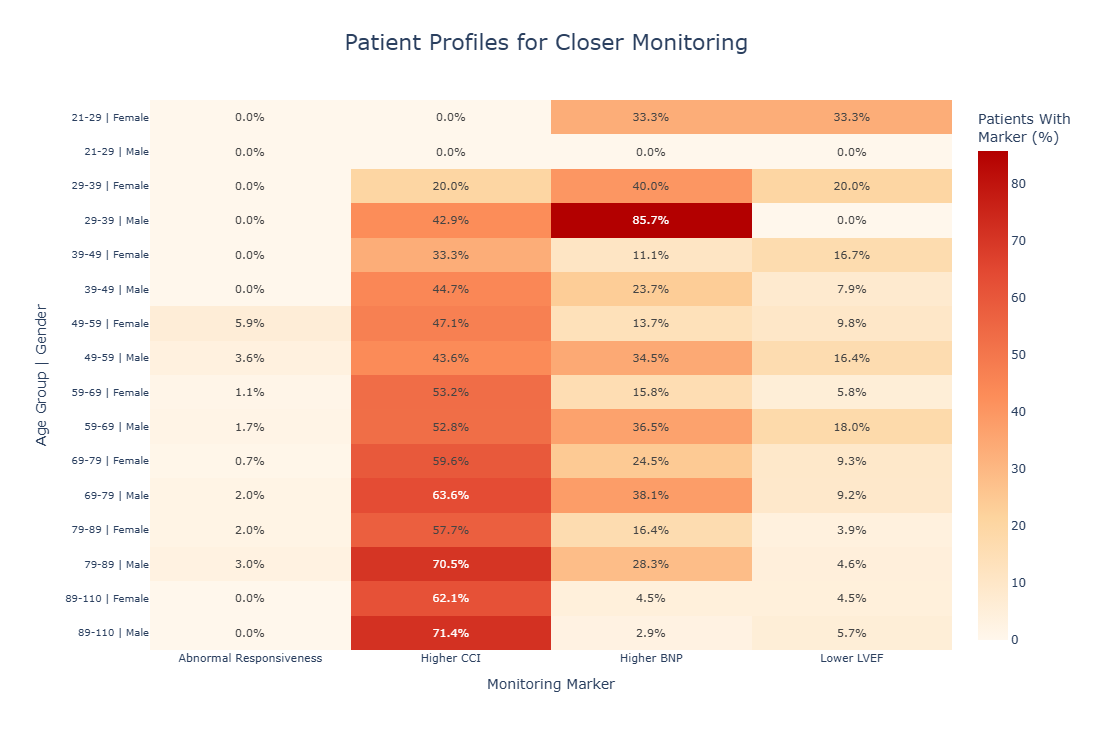


PATIENT MONITORING PRIORITY SUMMARY
--------------------------------


,agecat,gender,Patients,Multiple_Marker_Patients,Average_Marker_Count,Multiple_Marker_Percent,Patient_Profile
0,21-29,Female,3,0,0.666667,0.00,21-29 | Female
1,21-29,Male,1,0,0.000000,0.00,21-29 | Male
14,89-110,Female,66,3,0.712121,4.55,89-110 | Female
15,89-110,Male,35,3,0.800000,8.57,89-110 | Male
4,39-49,Female,18,2,0.611111,11.11,39-49 | Female
12,79-89,Female,409,54,0.799511,13.20,79-89 | Female
8,59-69,Female,190,26,0.757895,13.68,59-69 | Female
5,39-49,Male,38,6,0.763158,15.79,39-49 | Male
10,69-79,Female,421,80,0.940618,19.00,69-79 | Female
6,49-59,Female,51,10,0.764706,19.61,49-59 | Female


In [8]:
# ------------------------------------------------------------
# STEP 2: CHECK REQUIRED COLUMNS
# ------------------------------------------------------------

required_cols = [
    "inpatient_number",
    "agecat",
    "gender",
    "consciousness",
    "cci_score",
    "lvef",
    "brain_natriuretic_peptide"
]

missing_cols = [
    col for col in required_cols
    if col not in df_priority.columns
]

if missing_cols:
    print("Missing columns:", missing_cols)
else:
    print("All required columns are available.")


# ------------------------------------------------------------
# STEP 3: CONVERT CLINICAL MARKERS TO NUMERIC
# ------------------------------------------------------------

numeric_cols = [
    "cci_score",
    "lvef",
    "brain_natriuretic_peptide"
]

for col in numeric_cols:
    df_priority[col] = pd.to_numeric(
        df_priority[col],
        errors="coerce"
    )


# ------------------------------------------------------------
# STEP 4: CREATE ABNORMAL RESPONSIVENESS FLAG
# ------------------------------------------------------------

# Clear consciousness = 0
# Any other recorded consciousness state = 1

df_priority["Abnormal_Response"] = (
    df_priority["consciousness"]
    .astype(str)
    .str.strip()
    .str.lower()
    .ne("clear")
).astype(int)


# ------------------------------------------------------------
# STEP 5: CALCULATE DATASET-DERIVED THRESHOLDS
# ------------------------------------------------------------

# Higher CCI = top 25% of CCI values
cci_q75 = df_priority[
    "cci_score"
].quantile(0.75)

# Higher BNP = top 25% of BNP values
bnp_q75 = df_priority[
    "brain_natriuretic_peptide"
].quantile(0.75)

# Lower LVEF = bottom 25% of LVEF values
lvef_q25 = df_priority[
    "lvef"
].quantile(0.25)


# Display thresholds
print("\nDATASET-DERIVED THRESHOLDS")
print("--------------------------------")

print(
    "75th percentile CCI:",
    round(cci_q75, 2)
)

print(
    "75th percentile BNP:",
    round(bnp_q75, 2)
)

print(
    "25th percentile LVEF:",
    round(lvef_q25, 2)
)


# ------------------------------------------------------------
# STEP 6: CREATE MONITORING MARKER FLAGS
# ------------------------------------------------------------

# Higher CCI
df_priority["High_CCI"] = (
    df_priority["cci_score"] >= cci_q75
).astype(int)


# Higher BNP
df_priority["Higher_BNP"] = (
    df_priority[
        "brain_natriuretic_peptide"
    ] >= bnp_q75
).astype(int)


# Lower LVEF
df_priority["Lower_LVEF"] = (
    df_priority["lvef"] <= lvef_q25
).astype(int)


# ------------------------------------------------------------
# STEP 7: CREATE PATIENT PROFILE
# ------------------------------------------------------------

# Combine Age Group and Gender

df_priority["Patient_Profile"] = (
    df_priority["agecat"]
    .astype(str)
    .str.strip()
    + " | "
    + df_priority["gender"]
    .astype(str)
    .str.strip()
)


# ------------------------------------------------------------
# STEP 8: SUMMARIZE RISK MARKERS BY PATIENT PROFILE
# ------------------------------------------------------------

profile_summary = (
    df_priority
    .groupby("Patient_Profile")
    .agg(

        Patients=(
            "inpatient_number",
            "count"
        ),

        Abnormal_Response=(
            "Abnormal_Response",
            "mean"
        ),

        High_CCI=(
            "High_CCI",
            "mean"
        ),

        Higher_BNP=(
            "Higher_BNP",
            "mean"
        ),

        Lower_LVEF=(
            "Lower_LVEF",
            "mean"
        )
    )
)


# ------------------------------------------------------------
# STEP 9: CONVERT MARKER RATES TO PERCENTAGES
# ------------------------------------------------------------

heatmap_data = (
    profile_summary[
        [
            "Abnormal_Response",
            "High_CCI",
            "Higher_BNP",
            "Lower_LVEF"
        ]
    ] * 100
)


# Rename columns for chart
heatmap_data.columns = [
    "Abnormal Responsiveness",
    "Higher CCI",
    "Higher BNP",
    "Lower LVEF"
]


print("\nPATIENT PROFILE RISK MARKERS (%)")
print("--------------------------------")

display(
    heatmap_data.round(1)
)


# ------------------------------------------------------------
# STEP 10: CREATE INTERACTIVE PRESCRIPTIVE HEATMAP
# ------------------------------------------------------------

fig_heatmap = go.Figure(

    data=go.Heatmap(

        z=heatmap_data.values,

        x=heatmap_data.columns,

        y=heatmap_data.index,

        # Percentage displayed inside cells
        text=np.round(
            heatmap_data.values,
            1
        ),

        texttemplate="%{text:.1f}%",

        textfont=dict(
            size=11
        ),

        # Custom color scale
        colorscale=[
            [0.00, "#FFF7EC"],
            [0.25, "#FDD49E"],
            [0.50, "#FC8D59"],
            [0.75, "#E34A33"],
            [1.00, "#B30000"]
        ],

        # Interactive hover
        hovertemplate=(
            "<b>Patient Profile:</b> %{y}<br>"
            "<b>Monitoring Marker:</b> %{x}<br>"
            "<b>Patients With Marker:</b> %{z:.1f}%"
            "<extra></extra>"
        ),

        colorbar=dict(
            title="Patients With<br>Marker (%)"
        )
    )
)


# ------------------------------------------------------------
# STEP 11: FORMAT INTERACTIVE HEATMAP
# ------------------------------------------------------------

fig_heatmap.update_layout(

    title=dict(
        text=(
            "Patient Profiles for Closer Monitoring"
        ),
        x=0.5,
        xanchor="center",
        font=dict(
            size=22
        )
    ),

    xaxis=dict(
        title="Monitoring Marker",
        tickfont=dict(size=11)
    ),

    yaxis=dict(
        title="Age Group | Gender",
        tickfont=dict(size=10),
        autorange="reversed"
    ),

    width=1000,
    height=750,

    template="plotly_white",

    margin=dict(
        l=150,
        r=100,
        t=100,
        b=100
    )
)


# Display interactive heatmap
fig_heatmap.show()


# ------------------------------------------------------------
# STEP 12: CREATE TOTAL MARKER COUNT FOR EACH PATIENT
# ------------------------------------------------------------

marker_cols = [
    "Abnormal_Response",
    "High_CCI",
    "Higher_BNP",
    "Lower_LVEF"
]


df_priority["Marker_Count"] = (
    df_priority[
        marker_cols
    ].sum(axis=1)
)


# ------------------------------------------------------------
# STEP 13: IDENTIFY PATIENTS WITH MULTIPLE MARKERS
# ------------------------------------------------------------

# Patient has multiple markers when 2 or more
# monitoring indicators are present

df_priority["Multiple_Markers"] = (
    df_priority["Marker_Count"] >= 2
).astype(int)


# ------------------------------------------------------------
# STEP 14: CREATE MONITORING PRIORITY LEVEL
# ------------------------------------------------------------

def assign_priority(marker_count):

    if marker_count >= 3:
        return "High Priority"

    elif marker_count == 2:
        return "Moderate Priority"

    else:
        return "Routine Priority"


df_priority["Monitoring_Priority"] = (
    df_priority["Marker_Count"]
    .apply(assign_priority)
)


# ------------------------------------------------------------
# STEP 15: CREATE PRIORITY SUMMARY BY AGE AND GENDER
# ------------------------------------------------------------

priority_summary = (
    df_priority
    .groupby(
        ["agecat", "gender"]
    )
    .agg(

        Patients=(
            "inpatient_number",
            "count"
        ),

        Multiple_Marker_Patients=(
            "Multiple_Markers",
            "sum"
        ),

        Average_Marker_Count=(
            "Marker_Count",
            "mean"
        )
    )
    .reset_index()
)


# ------------------------------------------------------------
# STEP 16: CALCULATE MULTIPLE-MARKER PERCENTAGE
# ------------------------------------------------------------

priority_summary[
    "Multiple_Marker_Percent"
] = (

    priority_summary[
        "Multiple_Marker_Patients"
    ]

    /

    priority_summary[
        "Patients"
    ]

    * 100

).round(2)


# ------------------------------------------------------------
# STEP 17: CREATE PATIENT PROFILE FOR BAR CHART
# ------------------------------------------------------------

priority_summary["Patient_Profile"] = (

    priority_summary[
        "agecat"
    ].astype(str)

    + " | "

    + priority_summary[
        "gender"
    ].astype(str)
)


# ------------------------------------------------------------
# STEP 18: SORT PATIENT PROFILES
# ------------------------------------------------------------

priority_summary = (
    priority_summary
    .sort_values(
        "Multiple_Marker_Percent",
        ascending=True
    )
)


print(
    "\nPATIENT MONITORING PRIORITY SUMMARY"
)

print(
    "--------------------------------"
)

display(
    priority_summary
)


# ------------------------------------------------------------
# STEP 19: CREATE INTERACTIVE PRIORITY BAR CHART
# ------------------------------------------------------------

fig_priority = px.bar(

    priority_summary,

    x="Multiple_Marker_Percent",

    y="Patient_Profile",

    orientation="h",

    color="Multiple_Marker_Percent",

    color_continuous_scale=[
        "#FFF7EC",
        "#FDD49E",
        "#FC8D59",
        "#E34A33",
        "#B30000"
    ],

    text="Multiple_Marker_Percent",

    hover_data={

        "Patients": True,

        "Multiple_Marker_Patients":
            True,

        "Average_Marker_Count":
            ":.2f",

        "Multiple_Marker_Percent":
            ":.1f"
    },

    labels={

        "Multiple_Marker_Percent":
            "Patients With Multiple Risk Markers (%)",

        "Patient_Profile":
            "Age Group | Gender"
    },

    title=(
        "Patient Profiles Prioritized "
        "for Closer Monitoring"
    )
)








<p style="font-family: Cambria; font-size: 16px;"><b>Actual Insight :</b> From your previous analysis, abnormal responsiveness is uncommon overall: 34 patients were classified as abnormal compared with 1,974 Clear/Normal patients. By raw count, abnormal responsiveness was most concentrated in the 79–89 age group, with 15 abnormal cases, and your comorbidity analysis also showed increasing multiple-comorbidity prevalence among older groups, reaching 26.73% in the 89–110 group.</p>

<p style="font-family: Cambria; font-size: 20px;"><b>Question 2 :  Which patient groups warrant closer cardiac assessment based on high BNP and low LVEF patterns?</b></p>
<p style="font-family: Cambria; font-size: 16px;"><b>Reason : </b>This is a useful prescriptive-analysis question because it moves from simply describing BNP or LVEF individually to identifying patient groups where both patterns occur together. BNP provides biomarker information relevant to cardiac stress/heart-failure assessment, while LVEF describes ventricular pumping function. AHA guidance also emphasizes that EF is only one part of heart-failure assessment, so combining markers is more informative than treating either measure alone as definitive.</p>

In [9]:
# -------------------------------------------------------
# Step 1. Merge Demography, Cardiac Condition, Labs 
# -------------------------------------------------------
df_cardiac = (
    labs[
        ["inpatient_number", "brain_natriuretic_peptide"]
    ]
    .merge(
        cc[
            ["inpatient_number", "lvef"]
        ],
        on="inpatient_number",
        how="inner"
    )
    .merge(
        demo[
            ["inpatient_number", "agecat", "gender"]
        ],
        on="inpatient_number",
        how="inner"
    )
)

print(df_cardiac.shape)
df_cardiac.head()

(2008, 5)


,inpatient_number,brain_natriuretic_peptide,lvef,agecat,gender
0,857781,1500.17,NaN,69-79,Male
1,743087,361.70,NaN,69-79,Female
2,866418,293.95,NaN,59-69,Male
3,775928,1071.40,NaN,69-79,Male
4,810128,372.87,NaN,69-79,Female


Higher BNP threshold: 1736.98
Lower LVEF threshold: 41.0
Cardiac_Priority
0    548
1     78
Name: count, dtype: int64


,agecat,gender,Total_Patients,Priority_Patients,Priority_Percent,Median_BNP,Median_LVEF
0,21-29,Female,2,0,0.00,3251.32,34.0
1,21-29,Male,1,0,0.00,441.98,52.0
2,29-39,Female,3,1,33.33,2400.35,71.0
3,39-49,Female,8,1,12.50,724.44,50.0
4,39-49,Male,7,1,14.29,1371.36,49.0
5,49-59,Female,19,2,10.53,359.83,49.0
6,49-59,Male,17,3,17.65,603.18,41.0
7,59-69,Female,59,4,6.78,386.81,50.0
8,59-69,Male,63,17,26.98,1140.78,41.0
9,69-79,Female,138,21,15.22,712.72,52.0


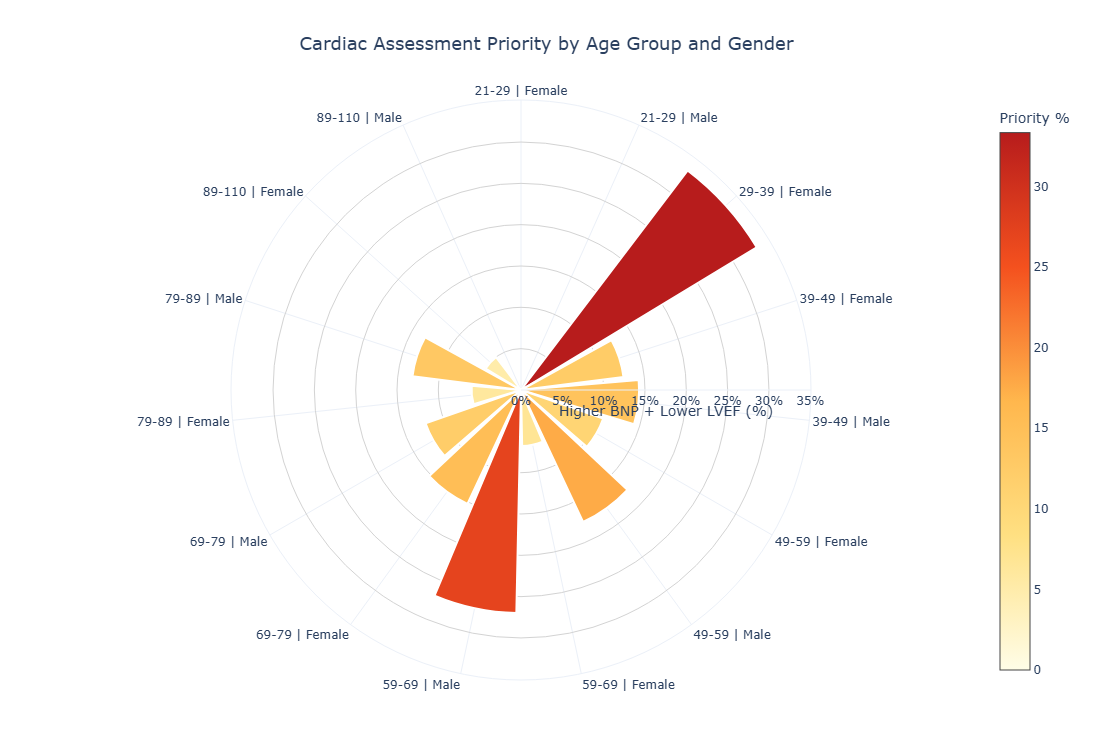

In [10]:
# -------------------------------------------------------
# Step 2. Convert BNP and LVEF to numeric
# -------------------------------------------------------
df_cardiac["brain_natriuretic_peptide"] = pd.to_numeric(
    df_cardiac["brain_natriuretic_peptide"],
    errors="coerce"
)

df_cardiac["lvef"] = pd.to_numeric(
    df_cardiac["lvef"],
    errors="coerce"
)

df_cardiac = df_cardiac.dropna(
    subset=[
        "brain_natriuretic_peptide",
        "lvef",
        "agecat",
        "gender"
    ]
)

# -------------------------------------------------------
# Step 3. Define Higher BNP and Lower LVEF
# -------------------------------------------------------
bnp_q75 = df_cardiac[
    "brain_natriuretic_peptide"
].quantile(0.75)

lvef_q25 = df_cardiac[
    "lvef"
].quantile(0.25)

print(
    "Higher BNP threshold:",
    round(bnp_q75, 2)
)

print(
    "Lower LVEF threshold:",
    round(lvef_q25, 2)
)

# -------------------------------------------------------
# Step 4. Identify patients with both patterns
# -------------------------------------------------------
df_cardiac["Higher_BNP"] = (
    df_cardiac["brain_natriuretic_peptide"]
    >= bnp_q75
)

df_cardiac["Lower_LVEF"] = (
    df_cardiac["lvef"]
    <= lvef_q25
)

df_cardiac["Cardiac_Priority"] = (
    df_cardiac["Higher_BNP"]
    &
    df_cardiac["Lower_LVEF"]
).astype(int)
print(
    df_cardiac["Cardiac_Priority"]
    .value_counts()
)

# -------------------------------------------------------
# Step 5. Calculate the percentage for each patient group
# -------------------------------------------------------
polar_data = (
    df_cardiac
    .groupby(
        ["agecat", "gender"],
        observed=True
    )
    .agg(
        Total_Patients=(
            "inpatient_number",
            "count"
        ),

        Priority_Patients=(
            "Cardiac_Priority",
            "sum"
        ),

        Priority_Percent=(
            "Cardiac_Priority",
            "mean"
        ),

        Median_BNP=(
            "brain_natriuretic_peptide",
            "median"
        ),

        Median_LVEF=(
            "lvef",
            "median"
        )
    )
    .reset_index()
)

polar_data["Priority_Percent"] = (
    polar_data["Priority_Percent"] * 100
)

polar_data = polar_data.sort_values(
    ["agecat", "gender"]
)

display(
    polar_data.round(2)
)

# -----------------------------------------------------------------
# Step 6. Create labels for the radial heatmap
# -----------------------------------------------------------------
polar_data["Patient_Group"] = (
    polar_data["agecat"].astype(str)
    + " | "
    + polar_data["gender"].astype(str)
)

# -----------------------------------------------------------------
# Step 7. Create the interactive Radial / Polar Heatmap
# -----------------------------------------------------------------

fig = go.Figure()

fig.add_trace(
    go.Barpolar(

        # Length of each sector
        r=polar_data["Priority_Percent"],

        # Patient groups around circle
        theta=polar_data["Patient_Group"],

        # Color based on priority percentage
        marker=dict(

            color=polar_data[
                "Priority_Percent"
            ],

            colorscale=[
                [0.00, "#FFFDE7"],
                [0.25, "#FFE082"],
                [0.50, "#FFB74D"],
                [0.75, "#F4511E"],
                [1.00, "#B71C1C"]
            ],

            colorbar=dict(
                title="Priority %"
            ),

            line=dict(
                color="white",
                width=2
            )
        ),

        customdata=polar_data[
            [
                "Total_Patients",
                "Priority_Patients",
                "Median_BNP",
                "Median_LVEF"
            ]
        ],

        hovertemplate=(
            "<b>%{theta}</b><br><br>"
            "Higher BNP + Lower LVEF: %{r:.1f}%<br>"
            "Total Patients: %{customdata[0]}<br>"
            "Priority Patients: %{customdata[1]}<br>"
            "Median BNP: %{customdata[2]:.2f}<br>"
            "Median LVEF: %{customdata[3]:.2f}"
            "<extra></extra>"
        )
    )
)

# -----------------------------------------------------------------
# Step 7. Format the chart
# -----------------------------------------------------------------

fig.update_layout(

    title=dict(
        text=(
            "Cardiac Assessment Priority by "
            "Age Group and Gender"
        ),
        x=0.5,
        font=dict(size=18)
    ),

    polar=dict(

        radialaxis=dict(
            title="Higher BNP + Lower LVEF (%)",
            ticksuffix="%",
            showgrid=True,
            gridcolor="lightgray"
        ),

        angularaxis=dict(
            direction="clockwise",
            rotation=90
        )
    ),

    template="plotly_white",

    width=900,
    height=750,

    margin=dict(
        l=70,
        r=120,
        t=100,
        b=70
    )
)

fig.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Actual Insight :</b> The radial heatmap identifies the age–gender groups with the highest concentration of the combined higher-BNP and lower-LVEF pattern. Darker and longer sectors represent groups with a greater percentage of patients meeting both exploratory criteria, highlighting patient groups that may warrant closer analytical cardiac assessment.</p>

<p style="font-family: Cambria; font-size: 20px;"><b>Question 3  :  Which laboratory and cardiac markers show the strongest relationships with one another and with patient comorbidity burden?</b></p>
<p style="font-family: Cambria; font-size: 16px;"><b>Reason : </b>This is a useful prescriptive-analysis question because patients often have multiple abnormalities occurring together. Examining correlations helps identify which cardiac, renal, and laboratory markers tend to move together and which markers are most closely associated with greater comorbidity burden.
A correlation heatmap is particularly suitable because it compares all marker pairs simultaneously, making clusters of related markers immediately visible. Similar biomarker/multimorbidity research uses Spearman correlation matrices and heatmaps to identify shared and distinct biomarker relationships.</p>

In [11]:
# ------------------------------------------------------------
# Step 1.  Merge Patient History, Cardiac Condition, Labs 
# ------------------------------------------------------------

df_corr = (
    ph[
        [
            "inpatient_number",
            "cci_score"
        ]
    ]
    .merge(
        cc[
            [
                "inpatient_number",
                "lvef"
            ]
        ],
        on="inpatient_number",
        how="inner"
    )
    .merge(
        labs[
            [
                "inpatient_number",
                "brain_natriuretic_peptide",
                "high_sensitivity_troponin",
                "creatinine_enzymatic_method",
                "glomerular_filtration_rate"
            ]
        ],
        on="inpatient_number",
        how="inner"
    )
)


Missing Values
----------------------------------------
cci_score                         5
lvef                           1373
brain_natriuretic_peptide        35
high_sensitivity_troponin        79
creatinine_enzymatic_method      23
glomerular_filtration_rate       63
dtype: int64

Spearman Correlation Matrix
----------------------------------------


,CCI Score,LVEF,BNP,Troponin,Creatinine,GFR
CCI Score,1.00,0.03,0.06,0.13,0.25,-0.25
LVEF,0.03,1.00,-0.54,-0.31,-0.09,0.01
BNP,0.06,-0.54,1.00,0.53,0.25,-0.18
Troponin,0.13,-0.31,0.53,1.00,0.33,-0.28
Creatinine,0.25,-0.09,0.25,0.33,1.00,-0.94
GFR,-0.25,0.01,-0.18,-0.28,-0.94,1.00


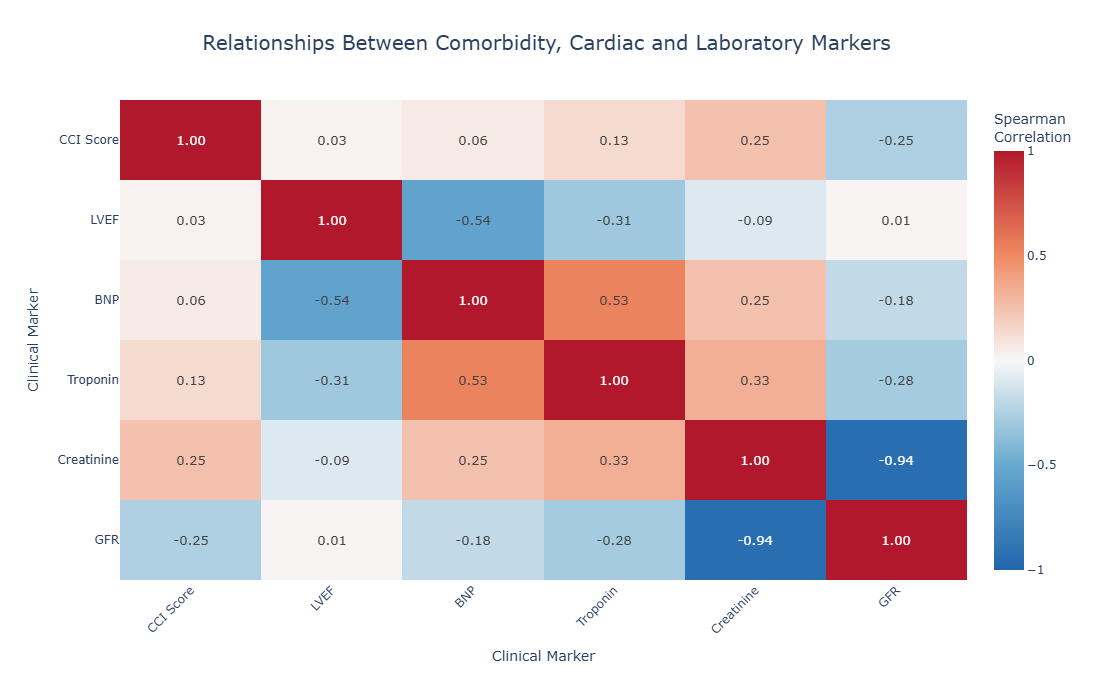


Strongest Relationships
----------------------------------------


,Marker_1,Marker_2,Correlation,Relationship
0,Creatinine,GFR,-0.944,Negative
1,LVEF,BNP,-0.545,Negative
2,BNP,Troponin,0.530,Positive
3,Troponin,Creatinine,0.330,Positive
4,LVEF,Troponin,-0.307,Negative
5,Troponin,GFR,-0.285,Negative
6,CCI Score,GFR,-0.250,Negative
7,BNP,Creatinine,0.247,Positive
8,CCI Score,Creatinine,0.247,Positive
9,BNP,GFR,-0.183,Negative


In [12]:
# ------------------------------------------------------------
# STEP 2: DEFINE VARIABLES FOR ANALYSIS
# ------------------------------------------------------------

analysis_cols = [
    "cci_score",
    "lvef",
    "brain_natriuretic_peptide",
    "high_sensitivity_troponin",
    "creatinine_enzymatic_method",
    "glomerular_filtration_rate"
]


# ------------------------------------------------------------
# STEP 3: CONVERT VARIABLES TO NUMERIC
# ------------------------------------------------------------

for col in analysis_cols:
    
    df_corr[col] = pd.to_numeric(
        df_corr[col],
        errors="coerce"
    )


# ------------------------------------------------------------
# STEP 4: CHECK MISSING VALUES
# ------------------------------------------------------------

print("Missing Values")
print("-" * 40)

print(
    df_corr[
        analysis_cols
    ].isnull().sum()
)


# ------------------------------------------------------------
# STEP 5: CREATE SPEARMAN CORRELATION MATRIX
# ------------------------------------------------------------

correlation_matrix = (
    df_corr[
        analysis_cols
    ]
    .corr(
        method="spearman"
    )
)


# ------------------------------------------------------------
# STEP 6: GIVE VARIABLES READABLE NAMES
# ------------------------------------------------------------

readable_names = {
    
    "cci_score":
        "CCI Score",
    
    "lvef":
        "LVEF",
    
    "brain_natriuretic_peptide":
        "BNP",
    
    "high_sensitivity_troponin":
        "Troponin",
    
    "creatinine_enzymatic_method":
        "Creatinine",
    
    "glomerular_filtration_rate":
        "GFR"
}


correlation_matrix = (
    correlation_matrix.rename(
        index=readable_names,
        columns=readable_names
    )
)


# Display correlation table
print("\nSpearman Correlation Matrix")
print("-" * 40)

display(
    correlation_matrix.round(2)
)


# ------------------------------------------------------------
# STEP 7: CREATE INTERACTIVE CORRELATION HEATMAP
# ------------------------------------------------------------

fig_heatmap = go.Figure(

    data=go.Heatmap(

        # Correlation values
        z=correlation_matrix.values,

        # Marker names
        x=correlation_matrix.columns,

        y=correlation_matrix.index,

        # Display values inside cells
        text=np.round(
            correlation_matrix.values,
            2
        ),

        texttemplate="%{text:.2f}",

        textfont=dict(
            size=13
        ),

        # Diverging color scale
        colorscale=[
            [0.00, "#2166AC"],
            [0.25, "#67A9CF"],
            [0.50, "#F7F7F7"],
            [0.75, "#EF8A62"],
            [1.00, "#B2182B"]
        ],

        # Correlation range
        zmin=-1,
        zmax=1,
        zmid=0,

        # Interactive hover
        hovertemplate=(
            "<b>Marker 1:</b> %{y}<br>"
            "<b>Marker 2:</b> %{x}<br>"
            "<b>Spearman Correlation:</b> %{z:.3f}"
            "<extra></extra>"
        ),

        colorbar=dict(
            title="Spearman<br>Correlation",
            tickvals=[
                -1,
                -0.5,
                0,
                0.5,
                1
            ]
        )
    )
)


# ------------------------------------------------------------
# STEP 8: FORMAT INTERACTIVE HEATMAP
# ------------------------------------------------------------

fig_heatmap.update_layout(

    title=dict(

        text=(
            "Relationships Between Comorbidity, "
            "Cardiac and Laboratory Markers"
        ),

        x=0.5,

        xanchor="center",

        font=dict(
            size=20
        )
    ),

    xaxis=dict(

        title="Clinical Marker",

        tickangle=-45,

        side="bottom"
    ),

    yaxis=dict(

        title="Clinical Marker",

        autorange="reversed"
    ),

    width=850,

    height=700,

    template="plotly_white",

    margin=dict(
        l=120,
        r=100,
        t=100,
        b=120
    )
)


fig_heatmap.show()


# ------------------------------------------------------------
# STEP 9: FIND UNIQUE CORRELATION PAIRS
# ------------------------------------------------------------

corr_pairs = (

    correlation_matrix
    .stack()
    .reset_index()
)


corr_pairs.columns = [
    "Marker_1",
    "Marker_2",
    "Correlation"
]


# ------------------------------------------------------------
# STEP 10: REMOVE SAME-VARIABLE CORRELATIONS
# ------------------------------------------------------------

corr_pairs = corr_pairs[

    corr_pairs["Marker_1"]
    !=
    corr_pairs["Marker_2"]

].copy()


# ------------------------------------------------------------
# STEP 11: REMOVE DUPLICATE PAIRS
# ------------------------------------------------------------

corr_pairs["Pair"] = (

    corr_pairs.apply(

        lambda row:

        " | ".join(
            sorted(
                [
                    row["Marker_1"],
                    row["Marker_2"]
                ]
            )
        ),

        axis=1
    )
)


corr_pairs = (

    corr_pairs
    .drop_duplicates(
        subset="Pair"
    )
    .copy()
)


# ------------------------------------------------------------
# STEP 12: CALCULATE ABSOLUTE CORRELATION
# ------------------------------------------------------------

corr_pairs[
    "Absolute_Correlation"
] = (

    corr_pairs[
        "Correlation"
    ].abs()
)


# Sort strongest to weakest
corr_pairs = (

    corr_pairs
    .sort_values(
        "Absolute_Correlation",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


# ------------------------------------------------------------
# STEP 13: CLASSIFY DIRECTION
# ------------------------------------------------------------

corr_pairs[
    "Relationship"
] = np.where(

    corr_pairs[
        "Correlation"
    ] >= 0,

    "Positive",

    "Negative"
)


# Display results
print(
    "\nStrongest Relationships"
)

print("-" * 40)


display(

    corr_pairs[
        [
            "Marker_1",
            "Marker_2",
            "Correlation",
            "Relationship"
        ]
    ]
    .round(3)
)


# ------------------------------------------------------------
# STEP 14: CREATE TOP RELATIONSHIPS DATA
# ------------------------------------------------------------

# Select strongest 10 relationships
top_relationships = (

    corr_pairs
    .head(10)
    .copy()
)


# Use readable pair labels
top_relationships[
    "Relationship_Pair"
] = (

    top_relationships[
        "Marker_1"
    ]

    + " ↔ "

    + top_relationships[
        "Marker_2"
    ]
)


# Reverse for horizontal chart
top_relationships = (

    top_relationships
    .sort_values(
        "Absolute_Correlation",
        ascending=True
    )
)


# ------------------------------------------------------------
# STEP 15: CREATE INTERACTIVE RANKED BAR CHART
# ------------------------------------------------------------

fig_pairs = px.bar(

    top_relationships,

    x="Absolute_Correlation",

    y="Relationship_Pair",

    orientation="h",

    color="Relationship",

    color_discrete_map={
        "Positive": "#D95F59",
        "Negative": "#4C78A8"
    },

    text="Correlation",

    hover_data={
        "Marker_1": True,
        "Marker_2": True,
        "Correlation": ":.3f",
        "Absolute_Correlation": ":.3f",
        "Relationship": True
    },

    title=(
        "Strongest Relationships Between "
        "Clinical and Cardiac Markers"
    ),

    labels={

        "Absolute_Correlation":
            "Absolute Spearman Correlation",

        "Relationship_Pair":
            "Marker Relationship"
    }
)




<p style="font-family: Cambria; font-size: 16px;"><b>Actual Insight :</b> The correlation analysis identifies the marker pair with the strongest relationship across the cardiac and laboratory measures and separately identifies the marker most strongly associated with CCI score. Strong positive correlations indicate markers that tend to increase together, while strong negative correlations indicate that one tends to decrease as the other increases. These relationships highlight combinations of markers that may be useful for coordinated analytical review in patients with greater comorbidity burden.</p>

<p style="font-family: Cambria; font-size: 20px;"><b>Question 4  : Which laboratory markers are most strongly associated with abnormal patient responsiveness and therefore may be useful for prioritizing follow-up?</b></p>
<p style="font-family: Cambria; font-size: 16px;"><b>Reason : </b>The lollipop chart directly answers “which laboratory markers are strongest?” by ranking markers according to their association with abnormal responsiveness. Unlike a correlation heatmap, which is more useful for many pairwise relationships, this chart focuses on one target outcome and makes the strongest signals immediately visible.</p>

In [13]:
# -------------------------------------------------------
# Step 1. Merge responsiveness and labs
# -------------------------------------------------------

df_lab = labs.merge(
    resp[
        [
            "inpatient_number",
            "consciousness"
        ]
    ],
    on="inpatient_number",
    how="inner"
)

Abnormal_Response
0    1974
1      34
Name: count, dtype: int64


,Marker,Association,Absolute_Association
7,Partial Oxygen Pressure,0.008,0.008
6,Respiration,0.020,0.020
5,Oxygen Saturation,-0.029,0.029
0,BNP,0.048,0.048
3,Urea,0.104,0.104
4,GFR,-0.106,0.106
2,Creatinine,0.107,0.107
1,Troponin,0.121,0.121


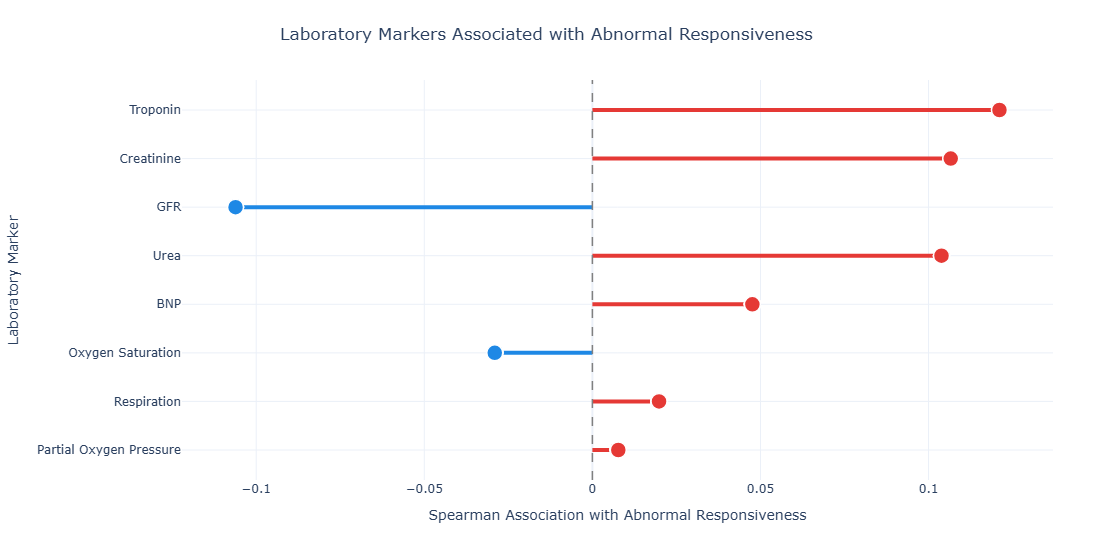

In [14]:
# -------------------------------------------------------
# Step 2 Create Normal/Abnormal responsiveness
# -------------------------------------------------------
df_lab["Abnormal_Response"] = (
    df_lab["consciousness"]
    .astype(str)
    .str.strip()
    .str.lower()
    .ne("clear")
).astype(int)

print(
    df_lab["Abnormal_Response"]
    .value_counts()
)

# -------------------------------------------------------
# Step 3. Select laboratory markers
# -------------------------------------------------------

lab_markers = [
    "brain_natriuretic_peptide",
    "high_sensitivity_troponin",
    "creatinine_enzymatic_method",
    "urea",
    "glomerular_filtration_rate",
    "oxygen_saturation",
    "respiration",
    "partial_oxygen_pressure"
]

for col in lab_markers:

    df_lab[col] = pd.to_numeric(
        df_lab[col],
        errors="coerce"
    )
    
# ------------------------------------------------------------
# Step 4. Calculate association with abnormal responsiveness
# ------------------------------------------------------------

associations = []

for marker in lab_markers:

    corr = df_lab[
        marker
    ].corr(
        df_lab["Abnormal_Response"],
        method="spearman"
    )

    associations.append(
        {
            "Marker": marker,
            "Association": corr,
            "Absolute_Association": abs(corr)
        }
    )

association_df = pd.DataFrame(
    associations
)

# -------------------------------------------------------
# Step 5. Give markers readable names
# -------------------------------------------------------

name_map = {

    "brain_natriuretic_peptide":
        "BNP",

    "high_sensitivity_troponin":
        "Troponin",

    "creatinine_enzymatic_method":
        "Creatinine",

    "urea":
        "Urea",

    "glomerular_filtration_rate":
        "GFR",

    "oxygen_saturation":
        "Oxygen Saturation",

    "respiration":
        "Respiration",

    "partial_oxygen_pressure":
        "Partial Oxygen Pressure"
}

association_df["Marker"] = (
    association_df["Marker"]
    .replace(name_map)
)

# -------------------------------------------------------
# Step 6. Rank the markers
# -------------------------------------------------------

association_df = (
    association_df
    .dropna(
        subset=["Association"]
    )
    .sort_values(
        "Absolute_Association",
        ascending=True
    )
)

display(
    association_df.round(3)
)

# -------------------------------------------------------
# Step 7. Create interactive colored lollipop chart
# -------------------------------------------------------

colors = [
    "#E53935"
    if x > 0
    else "#1E88E5"
    for x in association_df[
        "Association"
    ]
]

fig = go.Figure()

for _, row in association_df.iterrows():

    line_color = (
        "#E53935"
        if row["Association"] > 0
        else "#1E88E5"
    )

    fig.add_trace(
        go.Scatter(
            x=[
                0,
                row["Association"]
            ],

            y=[
                row["Marker"],
                row["Marker"]
            ],

            mode="lines",

            line=dict(
                color=line_color,
                width=4
            ),

            hoverinfo="skip",

            showlegend=False
        )
    )

    fig.add_trace(
    go.Scatter(

        x=association_df[
            "Association"
        ],

        y=association_df[
            "Marker"
        ],

        mode="markers",

        marker=dict(
            size=16,
            color=colors,

            line=dict(
                color="white",
                width=1.5
            )
        ),

        customdata=association_df[
            "Absolute_Association"
        ],

        hovertemplate=(
            "<b>%{y}</b><br>"
            "Association: %{x:.3f}<br>"
            "Absolute Strength: %{customdata:.3f}"
            "<extra></extra>"
        ),

        showlegend=False
    )
)

# -------------------------------------------------------
# Step 8. Add zero reference line
# -------------------------------------------------------

fig.add_vline(
    x=0,
    line_width=1.5,
    line_dash="dash",
    line_color="gray"
)

# -------------------------------------------------------
# Step 9. Format the interactive chart
# -------------------------------------------------------

fig.update_layout(

    title=dict(
        text=(
            "Laboratory Markers Associated with "
            "Abnormal Responsiveness"
        ),
        x=0.5
    ),

    xaxis_title=(
        "Spearman Association with "
        "Abnormal Responsiveness"
    ),

    yaxis_title=(
        "Laboratory Marker"
    ),

    template="plotly_white",

    width=900,
    height=550,

    hoverlabel=dict(
        font_size=13
    ),

    margin=dict(
        l=170,
        r=40,
        t=80,
        b=70
    )
)

fig.show()






<p style="font-family: Cambria; font-size: 16px;"><b>Actual Insight :</b> The ranked lollipop chart identifies the laboratory markers with the strongest positive or negative associations with abnormal responsiveness. Markers positioned farther from zero show stronger relationships and may therefore be useful candidates for closer analytical follow-up. Positive and negative directions should be interpreted according to the clinical meaning of each marker, rather than treating one color as universally better or worse.</p>

<p style="font-family: Cambria; font-size: 20px;"><b>Question 5  : Which patient profiles should be prioritized for intensive monitoring and post-discharge follow-up based on demographics, medical history, medication use, laboratory abnormalities, cardiac complications, responsiveness, and hospitalization outcomes? </b></p>
<p style="font-family: Cambria; font-size: 16px;"><b>Reason : </b>A bubble priority matrix is especially suitable because your question combines many variables from all seven tables. Instead of displaying seven separate charts, it converts the major indicators into interpretable risk dimensions and visually identifies the patient profiles that warrant greater attention.</p>

In [17]:
# -------------------------------------------------------
# 1. Merge All 7 Tables
# -------------------------------------------------------
#Convert important columns to numeric

labs["brain_natriuretic_peptide"] = pd.to_numeric(
    labs["brain_natriuretic_peptide"],
    errors="coerce"
)

cc["lvef"] = pd.to_numeric(
    cc["lvef"],
    errors="coerce"
)

cc["nyha_cardiac_function_classification"] = pd.to_numeric(
    cc["nyha_cardiac_function_classification"],
    errors="coerce"
)

ph["cci_score"] = pd.to_numeric(
    ph["cci_score"],
    errors="coerce"
)

resp["gcs"] = pd.to_numeric(
    resp["gcs"],
    errors="coerce"
)

#Calculate medication burden
med_count = (
    pp
    .groupby("inpatient_number")["drug_name"]
    .nunique()
    .reset_index(name="medication_count")
)

med_count.head()

# Select the important fields

demo_small = demo[
    ["inpatient_number", "agecat", "gender", "bmi"]
]

history_small = ph[
    [
        "inpatient_number",
        "cci_score",
        "diabetes",
        "moderate_to_severe_chronic_kidney_disease",
        "acute_renal_failure"
    ]
]

labs_small = labs[
    [
        "inpatient_number",
        "brain_natriuretic_peptide",
        "creatinine_enzymatic_method",
        "glomerular_filtration_rate"
    ]
]

cardiac_small = cc[
    [
        "inpatient_number",
        "lvef",
        "nyha_cardiac_function_classification",
        "congestive_heart_failure"
    ]
]

response_small = resp[
    ["inpatient_number", "gcs", "consciousness"]
]

hospital_small = hd[
    [
        "inpatient_number",
        "visit_times",
        "re_admission_within_28_days",
        "re_admission_within_3_months",
        "return_to_emergency_department_within_6_months"
    ]
]

# Merge all 7 tables

df = (
    demo_small
    .merge(history_small, on="inpatient_number", how="left")
    .merge(med_count, on="inpatient_number", how="left")
    .merge(labs_small, on="inpatient_number", how="left")
    .merge(cardiac_small, on="inpatient_number", how="left")
    .merge(response_small, on="inpatient_number", how="left")
    .merge(hospital_small, on="inpatient_number", how="left")
)

print("Final dataset shape:", df.shape)

df.head()

Final dataset shape: (2008, 21)


,inpatient_number,agecat,gender,bmi,cci_score,diabetes,moderate_to_severe_chronic_kidney_disease,acute_renal_failure,medication_count,brain_natriuretic_peptide,...,glomerular_filtration_rate,lvef,nyha_cardiac_function_classification,congestive_heart_failure,gcs,consciousness,visit_times,re_admission_within_28_days,re_admission_within_3_months,return_to_emergency_department_within_6_months
0,827040,69-79,Female,23.781213,1.0,0,0.0,0,3.0,70.83,...,71.88,NaN,3,1,15,Clear,1,0,0,1.0
1,857781,69-79,Male,18.590125,2.0,1,0.0,0,13.0,1500.17,...,58.57,NaN,3,0,15,Clear,1,0,0,0.0
2,743087,69-79,Female,19.195303,0.0,0,0.0,0,3.0,361.70,...,85.43,NaN,3,0,15,Clear,1,0,0,0.0
3,866418,59-69,Male,24.221453,0.0,0,0.0,0,7.0,293.95,...,31.51,NaN,2,0,15,Clear,2,0,0,0.0
4,775928,69-79,Male,22.491349,2.0,0,1.0,0,8.0,1071.40,...,58.01,NaN,3,0,15,Clear,1,1,1,1.0


Cardiac/Lab Risk Cutoff: 51.26
Clinical Risk Cutoff: 35.76


,Priority_Level,Patients
0,Critical Priority,680
1,High Clinical Priority,517
2,Routine Priority,489
3,High Cardiac/Lab Priority,322


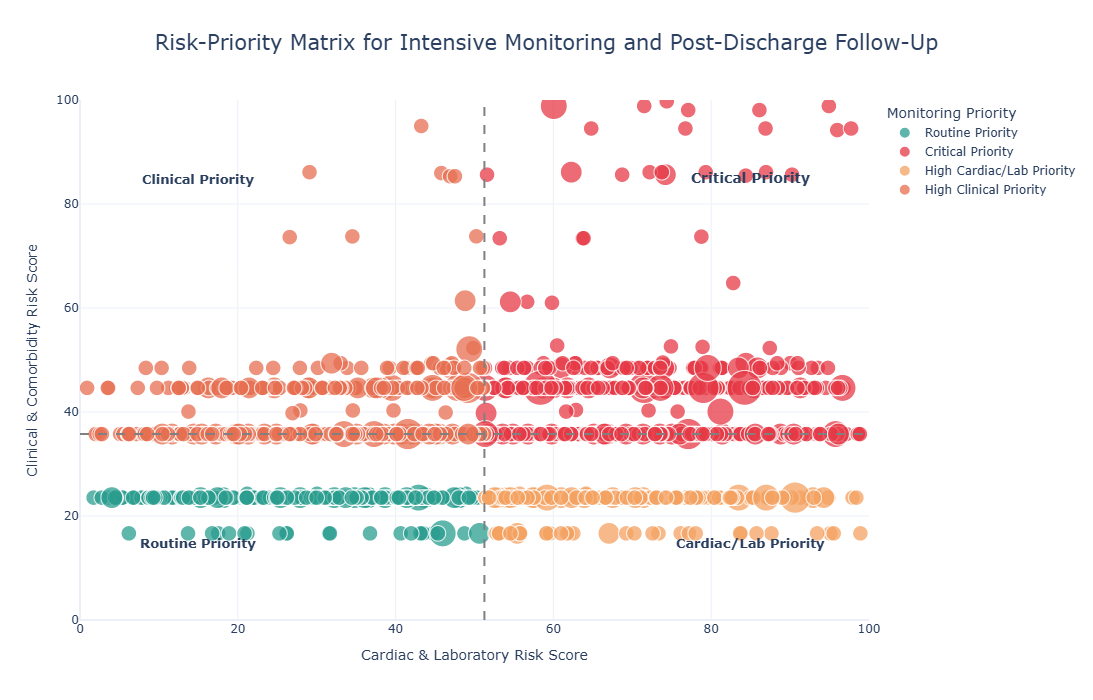


Highest-Priority Patient Profiles:


,inpatient_number,Patient_Profile,Cardiac_Lab_Risk,Clinical_Risk,Hospital_Burden,Priority_Level
1028,790433,69-79 | Male,74.366242,99.750665,1,Critical Priority
1111,730841,79-89 | Female,94.913835,98.843692,1,Critical Priority
1997,750447,79-89 | Male,71.507708,98.843692,1,Critical Priority
1058,834443,79-89 | Male,60.050351,98.843692,3,Critical Priority
1952,736630,59-69 | Female,86.110231,98.063479,1,Critical Priority
1963,789663,49-59 | Male,77.082506,98.063479,1,Critical Priority
1391,828678,69-79 | Male,97.733108,94.518050,1,Critical Priority
945,788087,79-89 | Male,86.886102,94.518050,1,Critical Priority
784,753274,79-89 | Female,76.731376,94.518050,1,Critical Priority
759,830537,49-59 | Female,64.790922,94.518050,1,Critical Priority


In [19]:
# -------------------------------------------------------
# STEP 1: CREATE WORKING DATAFRAME
# -------------------------------------------------------

risk_df = df.copy()


# -------------------------------------------------------
# STEP 2: SELECT IMPORTANT RISK VARIABLES
# -------------------------------------------------------

numeric_cols = [
    "cci_score",
    "lvef",
    "brain_natriuretic_peptide",
    "creatinine_enzymatic_method",
    "glomerular_filtration_rate",
    "gcs"
]


# -------------------------------------------------------
# STEP 3: CONVERT TO NUMERIC
# -------------------------------------------------------

for col in numeric_cols:

    if col in risk_df.columns:

        risk_df[col] = pd.to_numeric(
            risk_df[col],
            errors="coerce"
        )


# -------------------------------------------------------
# STEP 4: CREATE ABNORMAL RESPONSIVENESS FLAG
# -------------------------------------------------------

risk_df["Abnormal_Response"] = np.where(

    risk_df["consciousness"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("clear"),

    0,
    1
)


# -------------------------------------------------------
# STEP 5: CREATE PERCENTILE-BASED RISK SCORES
# -------------------------------------------------------

# Higher CCI = higher risk
risk_df["CCI_Risk"] = (
    risk_df["cci_score"]
    .rank(pct=True)
)


# Higher BNP = higher risk
risk_df["BNP_Risk"] = (
    risk_df["brain_natriuretic_peptide"]
    .rank(pct=True)
)


# Higher Creatinine = higher risk
risk_df["Creatinine_Risk"] = (
    risk_df["creatinine_enzymatic_method"]
    .rank(pct=True)
)


# Lower GFR = higher risk
risk_df["GFR_Risk"] = (
    1
    -
    risk_df["glomerular_filtration_rate"]
    .rank(pct=True)
)


# Lower LVEF = higher risk
risk_df["LVEF_Risk"] = (
    1
    -
    risk_df["lvef"]
    .rank(pct=True)
)


# Lower GCS = higher risk
risk_df["GCS_Risk"] = (
    1
    -
    risk_df["gcs"]
    .rank(pct=True)
)


# -------------------------------------------------------
# STEP 6: CREATE CARDIAC + LABORATORY RISK SCORE
# -------------------------------------------------------

risk_df["Cardiac_Lab_Risk"] = (

    risk_df[
        [
            "BNP_Risk",
            "Creatinine_Risk",
            "GFR_Risk",
            "LVEF_Risk"
        ]
    ]

    .mean(axis=1)

    * 100
)


# -------------------------------------------------------
# STEP 7: CREATE CLINICAL / COMORBIDITY RISK
# -------------------------------------------------------

risk_df["Clinical_Risk"] = (

    risk_df[
        [
            "CCI_Risk",
            "GCS_Risk",
            "Abnormal_Response"
        ]
    ]

    .mean(axis=1)

    * 100
)


# -------------------------------------------------------
# STEP 8: MEDICATION BURDEN
# -------------------------------------------------------

# If medication_count already exists, use it.
# Otherwise assign 1 so the bubble chart can still run.

if "medication_count" not in risk_df.columns:

    risk_df["medication_count"] = 1


risk_df["medication_count"] = pd.to_numeric(
    risk_df["medication_count"],
    errors="coerce"
).fillna(0)


# -------------------------------------------------------
# STEP 9: HOSPITALIZATION BURDEN
# -------------------------------------------------------

# If visit_times exists, use it as bubble size.

if "visit_times" in risk_df.columns:

    risk_df["Hospital_Burden"] = pd.to_numeric(
        risk_df["visit_times"],
        errors="coerce"
    )

else:

    risk_df["Hospital_Burden"] = 1


risk_df["Hospital_Burden"] = (
    risk_df["Hospital_Burden"]
    .fillna(1)
)


# Plotly bubble sizes must be positive
risk_df["Bubble_Size"] = (
    risk_df["Hospital_Burden"]
    .clip(lower=1)
)


# -------------------------------------------------------
# STEP 10: CALCULATE DATA-DRIVEN RISK CUT-OFFS
# -------------------------------------------------------

cardiac_cutoff = (
    risk_df["Cardiac_Lab_Risk"]
    .median()
)

clinical_cutoff = (
    risk_df["Clinical_Risk"]
    .median()
)


print(
    "Cardiac/Lab Risk Cutoff:",
    round(cardiac_cutoff, 2)
)

print(
    "Clinical Risk Cutoff:",
    round(clinical_cutoff, 2)
)


# -------------------------------------------------------
# STEP 11: CREATE PRIORITY LEVELS
# -------------------------------------------------------

def assign_priority(row):

    cardiac_high = (
        row["Cardiac_Lab_Risk"]
        >= cardiac_cutoff
    )

    clinical_high = (
        row["Clinical_Risk"]
        >= clinical_cutoff
    )


    # Both risk dimensions high
    if cardiac_high and clinical_high:

        return "Critical Priority"


    # High clinical risk only
    elif clinical_high:

        return "High Clinical Priority"


    # High cardiac/lab risk only
    elif cardiac_high:

        return "High Cardiac/Lab Priority"


    # Both dimensions below median
    else:

        return "Routine Priority"


risk_df["Priority_Level"] = (
    risk_df.apply(
        assign_priority,
        axis=1
    )
)


# -------------------------------------------------------
# STEP 12: CREATE PATIENT PROFILE
# -------------------------------------------------------

if (
    "agecat" in risk_df.columns
    and
    "gender" in risk_df.columns
):

    risk_df["Patient_Profile"] = (

        risk_df["agecat"]
        .astype(str)

        + " | "

        + risk_df["gender"]
        .astype(str)
    )

else:

    risk_df["Patient_Profile"] = (
        "Patient"
    )


# -------------------------------------------------------
# STEP 13: DISPLAY PRIORITY DISTRIBUTION
# -------------------------------------------------------

priority_summary = (

    risk_df[
        "Priority_Level"
    ]

    .value_counts()

    .reset_index()
)


priority_summary.columns = [
    "Priority_Level",
    "Patients"
]


display(priority_summary)


# -------------------------------------------------------
# STEP 14: DEFINE COLORS
# -------------------------------------------------------

priority_colors = {

    "Routine Priority":
        "#2A9D8F",

    "High Cardiac/Lab Priority":
        "#F4A261",

    "High Clinical Priority":
        "#E76F51",

    "Critical Priority":
        "#E63946"
}


# -------------------------------------------------------
# STEP 15: SELECT HOVER INFORMATION
# -------------------------------------------------------

hover_columns = {

    "Patient_Profile": True,

    "cci_score": ":.2f",

    "brain_natriuretic_peptide": ":.2f",

    "lvef": ":.2f",

    "creatinine_enzymatic_method": ":.2f",

    "glomerular_filtration_rate": ":.2f",

    "Cardiac_Lab_Risk": ":.1f",

    "Clinical_Risk": ":.1f",

    "Hospital_Burden": True,

    "Bubble_Size": False
}


# -------------------------------------------------------
# STEP 16: CREATE INTERACTIVE BUBBLE MATRIX
# -------------------------------------------------------

fig = px.scatter(

    risk_df,

    x="Cardiac_Lab_Risk",

    y="Clinical_Risk",

    size="Bubble_Size",

    color="Priority_Level",

    color_discrete_map=priority_colors,

    hover_name="Patient_Profile",

    hover_data=hover_columns,

    size_max=35,

    opacity=0.75,

    labels={

        "Cardiac_Lab_Risk":
            "Cardiac & Laboratory Risk Score",

        "Clinical_Risk":
            "Clinical & Comorbidity Risk Score",

        "Priority_Level":
            "Monitoring Priority"
    },

    title=(
        "Risk-Priority Matrix for Intensive Monitoring "
        "and Post-Discharge Follow-Up"
    )
)


# -------------------------------------------------------
# STEP 17: ADD VERTICAL RISK CUT-OFF
# -------------------------------------------------------

fig.add_vline(

    x=cardiac_cutoff,

    line_width=2,

    line_dash="dash",

    line_color="gray"
)


# -------------------------------------------------------
# STEP 18: ADD HORIZONTAL RISK CUT-OFF
# -------------------------------------------------------

fig.add_hline(

    y=clinical_cutoff,

    line_width=2,

    line_dash="dash",

    line_color="gray"
)


# -------------------------------------------------------
# STEP 19: ADD QUADRANT LABELS
# -------------------------------------------------------

fig.add_annotation(

    x=15,
    y=15,

    text="<b>Routine Priority</b>",

    showarrow=False,

    font=dict(
        size=13
    )
)


fig.add_annotation(

    x=85,
    y=15,

    text="<b>Cardiac/Lab Priority</b>",

    showarrow=False,

    font=dict(
        size=13
    )
)


fig.add_annotation(

    x=15,
    y=85,

    text="<b>Clinical Priority</b>",

    showarrow=False,

    font=dict(
        size=13
    )
)


fig.add_annotation(

    x=85,
    y=85,

    text="<b>Critical Priority</b>",

    showarrow=False,

    font=dict(
        size=14
    )
)


# -------------------------------------------------------
# STEP 20: FORMAT CHART
# -------------------------------------------------------

fig.update_layout(

    title=dict(

        x=0.5,

        xanchor="center",

        font=dict(
            size=21
        )
    ),

    xaxis=dict(

        title=(
            "Cardiac & Laboratory Risk Score"
        ),

        range=[0, 100]
    ),

    yaxis=dict(

        title=(
            "Clinical & Comorbidity Risk Score"
        ),

        range=[0, 100]
    ),

    legend=dict(

        title=(
            "Monitoring Priority"
        )
    ),

    width=1050,

    height=700,

    template="plotly_white",

    margin=dict(
        l=80,
        r=80,
        t=100,
        b=80
    )
)


# -------------------------------------------------------
# STEP 21: DISPLAY CHART
# -------------------------------------------------------

fig.show()


# -------------------------------------------------------
# STEP 22: FIND HIGHEST-PRIORITY PATIENTS
# -------------------------------------------------------

critical_patients = (

    risk_df[

        risk_df[
            "Priority_Level"
        ]
        ==
        "Critical Priority"

    ]

    .sort_values(

        [
            "Clinical_Risk",
            "Cardiac_Lab_Risk"
        ],

        ascending=False
    )
)


print(
    "\nHighest-Priority Patient Profiles:"
)


display(

    critical_patients[

        [
            "inpatient_number",
            "Patient_Profile",
            "Cardiac_Lab_Risk",
            "Clinical_Risk",
            "Hospital_Burden",
            "Priority_Level"
        ]

    ].head(20)
)

<p style="font-family: Cambria; font-size: 16px;"><b>Actual Insight : </b>Patients positioned in the upper-right quadrant represent the highest analytical priority because they combine elevated cardiac/laboratory risk with greater overall clinical burden. Larger bubbles indicate greater hospitalization burden, helping identify patients who may warrant closer monitoring and structured post-discharge follow-up.</p>

<p style="font-family: Cambria; font-size: 20px;"><b>Question 6  : Which patients have simultaneous cardiac, renal, and responsiveness abnormalities and may warrant priority review? </b></p>
<p style="font-family: Cambria; font-size: 16px;"><b>Reason : </b>The question is useful because it moves beyond examining one marker at a time. It identifies patients with simultaneous abnormalities across cardiac, renal, and responsiveness domains, allowing the analysis to focus on multidomain patterns.</p>

In [20]:
# -------------------------------------------------------
# Step 1. Merge the required tables
# -------------------------------------------------------

df = (
    labs[
        [
            "inpatient_number",
            "brain_natriuretic_peptide",
            "creatinine_enzymatic_method",
            "glomerular_filtration_rate"
        ]
    ]
    .merge(
        cc[
            [
                "inpatient_number",
                "lvef"
            ]
        ],
        on="inpatient_number",
        how="inner"
    )
    .merge(
        resp[
            [
                "inpatient_number",
                "consciousness"
            ]
        ],
        on="inpatient_number",
        how="inner"
    )
)

print(df.shape)
df.head()

(2008, 6)


,inpatient_number,brain_natriuretic_peptide,creatinine_enzymatic_method,glomerular_filtration_rate,lvef,consciousness
0,857781,1500.17,108.3,58.57,NaN,Clear
1,743087,361.70,62.0,85.43,NaN,Clear
2,866418,293.95,185.1,31.51,NaN,Clear
3,775928,1071.40,104.8,58.01,NaN,Clear
4,810128,372.87,83.9,60.52,NaN,Clear


BNP 75th percentile: 1738.52
LVEF 25th percentile: 41.0
Creatinine 75th percentile: 122.7
GFR 25th percentile: 41.6
Cardiac abnormality: 579
Renal abnormality: 562
Abnormal responsiveness: 34
Patients with all three abnormalities: 10


,Cardiac,Renal,Responsiveness,Patients,Combination
0,False,False,False,1055,No Abnormality
1,True,False,False,379,Cardiac
2,False,True,False,354,Renal
3,True,True,False,186,Cardiac + Renal
4,False,True,True,12,Renal + Responsiveness
5,True,True,True,10,Cardiac + Renal + Responsiveness
6,False,False,True,8,Responsiveness
7,True,False,True,4,Cardiac + Responsiveness


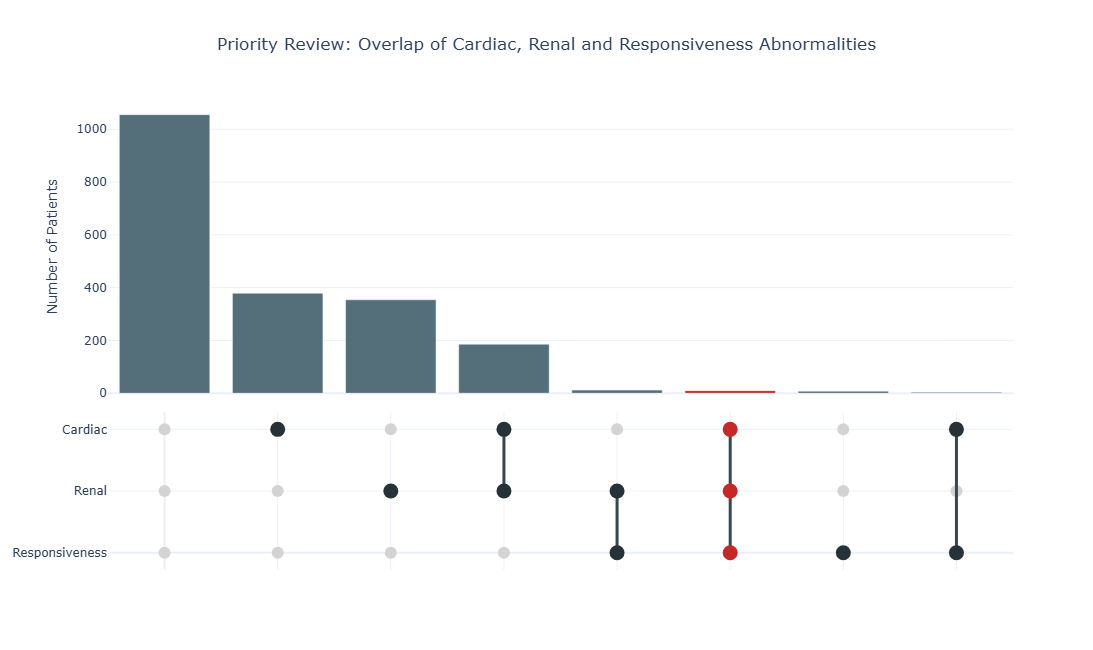

,inpatient_number,brain_natriuretic_peptide,lvef,creatinine_enzymatic_method,glomerular_filtration_rate,consciousness
504,794946,3827.40,20.0,134.3,49.12,Responsive To Sound
870,816910,1873.91,57.0,124.8,50.04,Responsive To Sound
923,798002,5000.00,NaN,172.3,33.17,Responsive To Sound
1035,790433,2971.98,53.0,151.8,37.07,Nonresponsive
1088,830368,1846.38,45.0,154.4,29.99,Responsive To Pain
1120,730841,2670.02,NaN,578.7,5.31,Nonresponsive
1163,827471,5000.00,NaN,237.7,16.47,Responsive To Sound
1258,765343,4152.92,45.0,140.2,39.68,Nonresponsive
1398,828678,4651.31,NaN,636.8,6.98,Responsive To Pain
2006,744870,2614.12,NaN,191.1,32.75,Nonresponsive


Priority-review patients: 10
Percentage of patients: 0.5 %


In [21]:
# -------------------------------------------------------
# Step2. Convert markers to numeric
# -------------------------------------------------------
numeric_cols = [
    "brain_natriuretic_peptide",
    "lvef",
    "creatinine_enzymatic_method",
    "glomerular_filtration_rate"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

# -------------------------------------------------------
# Step 3. Create exploratory thresholds
# -------------------------------------------------------

bnp_q75 = df["brain_natriuretic_peptide"].quantile(0.75)
lvef_q25 = df["lvef"].quantile(0.25)

creatinine_q75 = df["creatinine_enzymatic_method"].quantile(0.75)
gfr_q25 = df["glomerular_filtration_rate"].quantile(0.25)

print("BNP 75th percentile:", round(bnp_q75, 2))
print("LVEF 25th percentile:", round(lvef_q25, 2))
print("Creatinine 75th percentile:", round(creatinine_q75, 2))
print("GFR 25th percentile:", round(gfr_q25, 2))

# -------------------------------------------------------
# Step 4. Create the three abnormality flags
# -------------------------------------------------------

df["Cardiac"] = (
    (df["brain_natriuretic_peptide"] >= bnp_q75)
    |
    (df["lvef"] <= lvef_q25)
)

df["Renal"] = (
    (df["creatinine_enzymatic_method"] >= creatinine_q75)
    |
    (df["glomerular_filtration_rate"] <= gfr_q25)
)

df["Responsiveness"] = (
    df["consciousness"]
    .astype(str)
    .str.strip()
    .str.lower()
    .ne("clear")
)

print("Cardiac abnormality:", df["Cardiac"].sum())
print("Renal abnormality:", df["Renal"].sum())
print("Abnormal responsiveness:", df["Responsiveness"].sum())

# -------------------------------------------------------
# Step 5.Create priority-review flag
# -------------------------------------------------------
df["Priority_Review"] = (
    df["Cardiac"]
    &
    df["Renal"]
    &
    df["Responsiveness"]
)
print(
    "Patients with all three abnormalities:",
    df["Priority_Review"].sum()
)

# -------------------------------------------------------
# Step 6. Build the intersection data
# -------------------------------------------------------

intersection_data = (
    df.groupby(
        [
            "Cardiac",
            "Renal",
            "Responsiveness"
        ]
    )
    .size()
    .reset_index(
        name="Patients"
    )
)

intersection_data

def combination_name(row):

    conditions = []

    if row["Cardiac"]:
        conditions.append("Cardiac")

    if row["Renal"]:
        conditions.append("Renal")

    if row["Responsiveness"]:
        conditions.append("Responsiveness")

    if len(conditions) == 0:
        return "No Abnormality"

    return " + ".join(conditions)


intersection_data["Combination"] = (
    intersection_data.apply(
        combination_name,
        axis=1
    )
)

intersection_data = (
    intersection_data
    .sort_values(
        "Patients",
        ascending=False
    )
    .reset_index(drop=True)
)

display(intersection_data)

# -------------------------------------------------------
# Step 7. Interactive UpSet Plot
# -------------------------------------------------------

from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Remove combinations with zero patients
plot_df = intersection_data[
    intersection_data["Patients"] > 0
].copy()

plot_df = plot_df.reset_index(drop=True)

x_pos = list(range(len(plot_df)))

fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    row_heights=[0.65, 0.35],
    vertical_spacing=0.04
)

bar_colors = [
    "#C62828"
    if (
        row["Cardiac"]
        and row["Renal"]
        and row["Responsiveness"]
    )
    else "#546E7A"

    for _, row in plot_df.iterrows()
]

fig.add_trace(
    go.Bar(
        x=x_pos,
        y=plot_df["Patients"],

        marker_color=bar_colors,

        customdata=plot_df[
            ["Combination"]
        ],

        hovertemplate=(
            "<b>%{customdata[0]}</b><br>"
            "Patients: %{y}"
            "<extra></extra>"
        ),

        name="Patients"
    ),
    row=1,
    col=1
)

# -------------------------------------------------------
# Step 8. Add the UpSet dots
# -------------------------------------------------------

conditions = [
    "Cardiac",
    "Renal",
    "Responsiveness"
]

y_positions = {
    "Cardiac": 2,
    "Renal": 1,
    "Responsiveness": 0
}

for i, row in plot_df.iterrows():

    for condition in conditions:

        fig.add_trace(
            go.Scatter(
                x=[i],
                y=[y_positions[condition]],

                mode="markers",

                marker=dict(
                    size=12,
                    color="#D3D3D3"
                ),

                hoverinfo="skip",
                showlegend=False
            ),
            row=2,
            col=1
        )

for i, row in plot_df.iterrows():

    active_y = []

    for condition in conditions:

        if row[condition]:

            active_y.append(
                y_positions[condition]
            )

    # Connecting line
    if len(active_y) > 1:

        fig.add_trace(
            go.Scatter(
                x=[i, i],
                y=[
                    min(active_y),
                    max(active_y)
                ],

                mode="lines",

                line=dict(
                    color="#37474F",
                    width=3
                ),

                hoverinfo="skip",
                showlegend=False
            ),
            row=2,
            col=1
        )

    # Active dots
    for y in active_y:

        priority = (
            row["Cardiac"]
            and row["Renal"]
            and row["Responsiveness"]
        )

        dot_color = (
            "#C62828"
            if priority
            else "#263238"
        )

        fig.add_trace(
            go.Scatter(
                x=[i],
                y=[y],

                mode="markers",

                marker=dict(
                    size=15,
                    color=dot_color
                ),

                hovertemplate=(
                    f"<b>{row['Combination']}</b><br>"
                    f"Patients: {row['Patients']}"
                    "<extra></extra>"
                ),

                showlegend=False
            ),
            row=2,
            col=1
        )

# -------------------------------------------------------
# Step 9. Format the chart
# -------------------------------------------------------

fig.update_yaxes(
    title_text="Number of Patients",
    row=1,
    col=1
)

fig.update_yaxes(
    tickmode="array",
    tickvals=[0, 1, 2],
    ticktext=[
        "Responsiveness",
        "Renal",
        "Cardiac"
    ],
    row=2,
    col=1
)

fig.update_xaxes(
    showticklabels=False,
    row=2,
    col=1
)

fig.update_layout(
    title=dict(
        text=(
            "Priority Review: Overlap of Cardiac, "
            "Renal and Responsiveness Abnormalities"
        ),
        x=0.5
    ),

    template="plotly_white",

    width=950,
    height=650,

    showlegend=False,

    hoverlabel=dict(
        font_size=13
    )
)

fig.show()
priority_patients = df[
    df["Priority_Review"]
].copy()

display(
    priority_patients[
        [
            "inpatient_number",
            "brain_natriuretic_peptide",
            "lvef",
            "creatinine_enzymatic_method",
            "glomerular_filtration_rate",
            "consciousness"
        ]
    ]
)

print(
    "Priority-review patients:",
    len(priority_patients)
)

print(
    "Percentage of patients:",
    round(
        len(priority_patients)
        / len(df) * 100,
        2
    ),
    "%"
)


# <center>Team 7 — Code Avengers </center>
## Labs + Prescription Medication Analysis
### Descriptive Analysis and Prescriptive Analysis

- **Primary dataset 1: Labs** — 2,008 patient-level rows and a wide range of physiologic/laboratory variables.
- **Primary dataset 2: Patient Prescriptions** — medication exposure records with multiple drugs per patient.
- **Supporting dataset: Demography** — used only for meaningful segmentation such as **age category, gender, BMI, weight and height**.

> **Important:** Prescriptive analysis here means **what the analytics team should review or investigate next**.  
> It does **not** prescribe medications or provide clinical treatment recommendations.

# Import, File Loading and Merging

In [22]:
# Optional one-time installation if your local Jupyter environment needs it:
# %pip install pandas numpy plotly scipy nbformat

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import spearmanr, mannwhitneyu


In [23]:
# Define the main project folder
project_folder = Path(
    r"C:\Users\swith\OneDrive\Desktop\Swithi\Numpy Ninja\Python Hackathon Sept 2026\Python_Hackathon_Sep_2026\cardiac_failure\__Final_Cleaned Dataset"
)

# Define CSV filenames
FILES = {
    "labs": "Team7_CodeAvengers_Category1_DataCleaning_labs.csv",
    "prescriptions": "Team7_CodeAvengers_Category1_DataCleaning_patient_precriptions.csv",
    "demography": "Team7_CodeAvengers_Category1_DataCleaning_demography.csv",
}

# Read the cleaned datasets
labs = pd.read_csv(project_folder / FILES["labs"])
prescriptions = pd.read_csv(project_folder / FILES["prescriptions"])
demography = pd.read_csv(project_folder / FILES["demography"])

# Verify successful loading
print("Labs:", labs.shape)
print("Prescriptions:", prescriptions.shape)
print("Demography:", demography.shape)

Labs: (2008, 107)
Prescriptions: (15362, 2)
Demography: (2008, 7)


In [24]:
# Validate patient-level uniqueness before merging.
for name, df in {"labs": labs, "demography": demography}.items():
    print("\t")
    print(
        f"{name:12s} rows={len(df):,} | "
        f"unique patients={df['inpatient_number'].nunique():,} | "
        f"duplicate patient IDs={df['inpatient_number'].duplicated().sum():,}"
    )
print("\t")
print(
    f"prescriptions rows={len(prescriptions):,} | "
    f"unique patients={prescriptions['inpatient_number'].nunique():,} | "
    f"unique drug names={prescriptions['drug_name'].nunique():,}"
)

# Clean drug-name whitespace only; do not change clinical content.
rx = prescriptions.copy()
rx["drug_name"] = rx["drug_name"].astype(str).str.strip()

# Aggregate prescriptions BEFORE patient-level merge to avoid multiplying lab rows.
rx_summary = (
    rx.groupby("inpatient_number")
      .agg(
          prescription_rows=("drug_name", "size"),
          unique_medication_count=("drug_name", "nunique")
      )
      .reset_index()
)

patient = (
    labs
    .merge(demography, on="inpatient_number", how="left", validate="one_to_one")
    .merge(rx_summary, on="inpatient_number", how="left", validate="one_to_one")
)

patient[["prescription_rows", "unique_medication_count"]] = (
    patient[["prescription_rows", "unique_medication_count"]].fillna(0)
)

AGE_ORDER = ["21-29", "29-39", "39-49", "49-59", "59-69", "69-79", "79-89", "89-110"]
AGE_MIDPOINT = {
    "21-29": 25, "29-39": 34, "39-49": 44, "49-59": 54,
    "59-69": 64, "69-79": 74, "79-89": 84, "89-110": 99.5
}

patient["agecat"] = pd.Categorical(patient["agecat"], categories=AGE_ORDER, ordered=True)
patient["age_midpoint"] = patient["agecat"].astype(str).map(AGE_MIDPOINT)

print("\n Final patient-level analytical dataset:", patient.shape)
print("\n Unique patients:", patient["inpatient_number"].nunique())

	
labs         rows=2,008 | unique patients=2,008 | duplicate patient IDs=0
	
demography   rows=2,008 | unique patients=2,008 | duplicate patient IDs=0
	
prescriptions rows=15,362 | unique patients=2,007 | unique drug names=25

 Final patient-level analytical dataset: (2008, 116)

 Unique patients: 2008


# <center>PRESCRIPTIVE ANALYSIS </center>

In [25]:
ID, AGE, SEX = "inpatient_number", "agecat", "gender"
MIN_GROUP_N, MIN_PAIR_N = 10, 30
BG, FEMALE, MALE, TEAL = "#F2FBFD", "#B576A5", "#147D50", "#147D50"

for frame_name, frame, columns in [
    ("patient", patient, [ID, AGE, SEX]),
    ("labs", labs, [ID]),
]:
    absent = [c for c in columns if c not in frame.columns]
    if absent:
        raise KeyError(f"{frame_name} missing columns: {absent}")

# Use column names from the real labs CSV, not made-up marker names.
exclude_words = ("date", "time", "flag", "status", "label", "duration", "length", "index")
lab_candidates = []
for col in labs.columns:
    if col == ID or col not in patient.columns or any(w in col.lower() for w in exclude_words):
        continue
    numeric_values = pd.to_numeric(patient[col], errors="coerce")
    if numeric_values.notna().sum() >= 5 and numeric_values.nunique() >= 5:
        lab_candidates.append(col)

preferred_words = [
    "hemoglobin", "albumin", "troponin", "bnp", "natriuretic",
    "creatinine_enzymatic_method", "glomerular_filtration_rate",
    "urea", "glucose_blood_gas",
]
# Prioritize kidney-related laboratory biomarkers
kidney_markers = [
    "glomerular_filtration_rate",
    "creatinine_enzymatic_method",
    "urea"
]

# Identify other important laboratory biomarkers
preferred_words = [
    "hemoglobin",
    "albumin",
    "troponin",
    "bnp",
    "natriuretic",
    "glucose_blood_gas"
]

# Add available kidney markers first
MARKERS = [
    col for col in kidney_markers
    if col in lab_candidates
]

# Add other important biomarkers
for word in preferred_words:
    for col in lab_candidates:
        if word in col.lower() and col not in MARKERS:
            MARKERS.append(col)

# Add remaining laboratory biomarkers
MARKERS += [
    col for col in lab_candidates
    if col not in MARKERS
]

# Select the first 10 biomarkers
MARKERS = MARKERS[:10]

print("Selected Laboratory Biomarkers:")
print(MARKERS)
# One record per inpatient_number for analyses involving patient groups.
cols = [ID, AGE, SEX] + MARKERS
df = patient[cols].copy().dropna(subset=[ID])
for col in MARKERS:
    df[col] = pd.to_numeric(df[col], errors="coerce")
for col in [AGE, SEX]:
    df[col] = df[col].astype("string").str.strip().replace("", pd.NA)

raw_rows = len(df)
df = df.groupby(ID, as_index=False).agg({
    AGE: "first", SEX: "first", **{col: "median" for col in MARKERS}
})
print(f"Rows in merged patient data: {raw_rows:,}; distinct inpatient records: {len(df):,}")
if raw_rows > len(df):
    print("Repeated inpatient rows were combined using the median for each numeric lab.")

# Dataset-based comparison bounds: NOT clinical reference ranges.
BOUNDS = {
    col: (df[col].quantile(0.10), df[col].quantile(0.90))
    for col in MARKERS
}
flags = pd.DataFrame(index=df.index)
for col in MARKERS:
    low, high = BOUNDS[col]
    flags[col] = np.where(
        df[col].notna(),
        (df[col] < low) | (df[col] > high),
        np.nan
    ).astype(float)

print("Comparison method: below the 10th OR above the 90th cohort percentile.")

def style(fig, height=580):
    fig.update_layout(
        height=height, paper_bgcolor="white", plot_bgcolor=BG,
        font=dict(size=12), title_x=0.5
    )
    return fig

def group_text(row):
    return f"{row[AGE]} / {row[SEX]}"

Selected Laboratory Biomarkers:
['glomerular_filtration_rate', 'creatinine_enzymatic_method', 'urea', 'mean_hemoglobin_volume', 'mean_hemoglobin_concentration', 'hemoglobin', 'methemoglobin', 'reduced_hemoglobin', 'carboxyhemoglobin', 'oxyhemoglobin']
Rows in merged patient data: 2,008; distinct inpatient records: 2,008
Comparison method: below the 10th OR above the 90th cohort percentile.


### PA2. Which age groups have the highest proportion of patients with relatively low hemoglobin or albumin levels and relatively high glucose or troponin levels, indicating groups that may warrant closer laboratory monitoring?
* Reasoning:* Comparing hemoglobin, albumin, and glucose levels across age groups helps us understand which patients have lower or higher laboratory measurements. A Treemap makes it easier to see how these results are distributed across different age groups and identify groups that may need further review

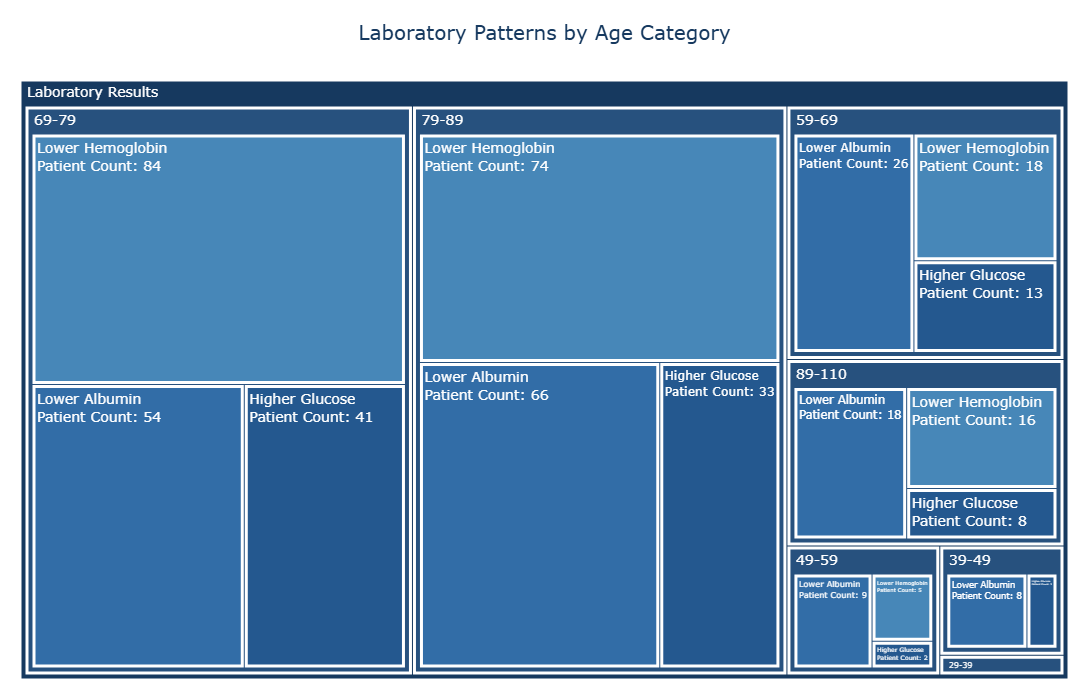

In [27]:
import pandas as pd
import plotly.graph_objects as go

# --------------------------------------------------
# 1. Select laboratory measurements
# --------------------------------------------------

lab_options = {
    "Lower Hemoglobin": (
        ["hemoglobin", "hemoglobin_blood_gas"],
        "low"
    ),

    "Lower Albumin": (
        ["albumin", "albumin_serum"],
        "low"
    ),

    "Higher Glucose": (
        ["glucose_blood_gas", "glucose"],
        "high"
    ),

    "Higher Troponin": (
        ["troponin_i", "troponin_t", "troponin"],
        "high"
    )
}

selected_labs = {}

for label, (options, direction) in lab_options.items():

    col = next(
        (c for c in options if c in patient.columns),
        None
    )

    if col:
        selected_labs[label] = (col, direction)

if not selected_labs:
    raise ValueError("No laboratory measurements found.")


# --------------------------------------------------
# 2. Calculate patient counts
# --------------------------------------------------

results = []

for label, (col, direction) in selected_labs.items():

    tmp = patient[
        ["inpatient_number", "agecat", col]
    ].copy()

    tmp[col] = pd.to_numeric(
        tmp[col],
        errors="coerce"
    )

    tmp = tmp.dropna()

    if tmp.empty:
        continue

    # Count each inpatient number once for each lab test
    tmp = (
        tmp.groupby(
            ["inpatient_number", "agecat"],
            observed=True,
            as_index=False
        )[col]
        .median()
    )

    # Identify lower or higher measurements
    if direction == "low":

        limit = tmp[col].quantile(0.10)

        tmp["selected_result"] = tmp[col] < limit

    else:

        limit = tmp[col].quantile(0.90)

        tmp["selected_result"] = tmp[col] > limit

    # Calculate patient counts by age category
    summary = (
        tmp.groupby(
            "agecat",
            observed=True
        )["selected_result"]
        .agg(
            patients_tested="count",
            patient_count="sum"
        )
        .reset_index()
    )

    summary["Lab Result"] = label

    summary["Patient Percentage"] = (
        summary["patient_count"]
        / summary["patients_tested"]
        * 100
    )

    results.append(summary)


# --------------------------------------------------
# 3. Combine laboratory results
# --------------------------------------------------

if not results:
    raise ValueError("No laboratory results are available.")

lab_summary = pd.concat(
    results,
    ignore_index=True
)

lab_summary = lab_summary.rename(
    columns={
        "agecat": "Age Category"
    }
)

lab_summary["Age Category"] = (
    lab_summary["Age Category"].astype(str)
)

# Keep groups with at least 10 tested patients
plot_data = lab_summary[
    (lab_summary["patients_tested"] >= 10) &
    (lab_summary["patient_count"] > 0)
].copy()

if plot_data.empty:
    raise ValueError("No results available for the Treemap.")


# --------------------------------------------------
# 4. Define blue color palette
# --------------------------------------------------

lab_colors = {
    "Lower Hemoglobin": "#4787B8",
    "Lower Albumin": "#326DA7",
    "Higher Glucose": "#24588F",
    "Higher Troponin": "#123F70"
}


# --------------------------------------------------
# 5. Create Treemap hierarchy
# --------------------------------------------------

nodes = []

# Main category
nodes.append({
    "id": "root",
    "label": "Laboratory Results",
    "parent": "",
    "value": int(plot_data["patient_count"].sum()),
    "color": "#16395F",

    "text": "Laboratory Results",

    "hover": (
        "<b>Laboratory Results</b><br>"
        "Select an age group to view laboratory results."
    )
})


# Age categories
for age, age_data in plot_data.groupby(
    "Age Category",
    sort=False
):

    age_id = f"age_{age}"

    age_count = int(
        age_data["patient_count"].sum()
    )

    nodes.append({
        "id": age_id,
        "label": age,
        "parent": "root",
        "value": age_count,
        "color": "#27517E",

        "text": f"Age: {age}",

        "hover": (
            f"<b>Age Group: {age}</b><br>"
            "Select a laboratory measurement for details."
        )
    })

    # IMPORTANT:
    # Laboratory boxes must be inside the age-group loop.

    for _, row in age_data.iterrows():

        lab_name = row["Lab Result"]

        count = int(row["patient_count"])

        tested = int(row["patients_tested"])

        percentage = float(row["Patient Percentage"])

        nodes.append({
            "id": f"{age_id}_{lab_name}",
            "label": lab_name,
            "parent": age_id,
            "value": count,
            "color": lab_colors[lab_name],

            "text": (
                f"{lab_name}<br>"
                f"Patient Count: {count}"
            ),

            "hover": (
                f"<b>{lab_name}</b><br>"
                f"Age Group: {age}<br>"
                f"Patient Count: {count:,}<br>"
                f"Tested Patients: {tested:,}<br>"
                f"Patient Percentage: {percentage:.1f}%"
            )
        })


# --------------------------------------------------
# 6. Create Treemap
# --------------------------------------------------

fig = go.Figure(

    go.Treemap(
        ids=[
            n["id"]
            for n in nodes
        ],
        labels=[
            n["label"]
            for n in nodes
        ],
        parents=[
            n["parent"]
            for n in nodes
        ],
        values=[
            n["value"]
            for n in nodes
        ],
        branchvalues="total",
        marker=dict(

            colors=[
                n["color"]
                for n in nodes
            ],
            line=dict(
                color="white",
                width=3
            )
        ),
        text=[
            n["text"]
            for n in nodes
        ],

        texttemplate="%{text}",

        hovertext=[
            n["hover"]
            for n in nodes
        ],
        hovertemplate=(
            "%{hovertext}"
            "<extra></extra>"
        ),
        textfont=dict(
            size=14,
            color="white"
        ),
        tiling=dict(
            packing="squarify",
            pad=4
        ),
        pathbar=dict(
            visible=True
        ),
        maxdepth=3
    )
)

# --------------------------------------------------
# 7. Customize chart
# --------------------------------------------------

fig.update_layout(

    title=dict(
        text="Laboratory Patterns by Age Category",
        x=0.5,

        font=dict(
            size=20,
            color="#16395F"
        )
    ),
    height=700,
    paper_bgcolor="white",
    margin=dict(
        t=80,
        l=20,
        r=20,
        b=20
    ),

    font=dict(size=13)
)

fig.show()


### Actual Insight: 
Based on your actual results:*
The older age groups show more patients with lower hemoglobin and albumin levels. Patients aged 69–79 had the highest count of lower hemoglobin measurements, with 84 out of 708 tested patients (11.86%), followed by patients aged 79–89, with 74 out of 639 (11.58%).
The 89–110 age group had a particularly high percentage of lower albumin measurements, with 18 out of 93 tested patients (19.35%).
These findings suggest that older patient groups may benefit from closer review of hemoglobin and albumin measurements.

# PA4: Which age groups show the greatest differences in laboratory values, and which specific lab measurements may require closer clinical attention? 
* Sankey Chart: Laboratory Result Flow Across Age Groups — Prescriptive Analysis *
* Reasoning *

Comparing hemoglobin, albumin, glucose, creatinine, and urea across age groups helps us understand how laboratory results differ among patients. A Sankey chart shows how these measurements are distributed into above, within, and below comparison ranges, helping identify patterns that may need further review.

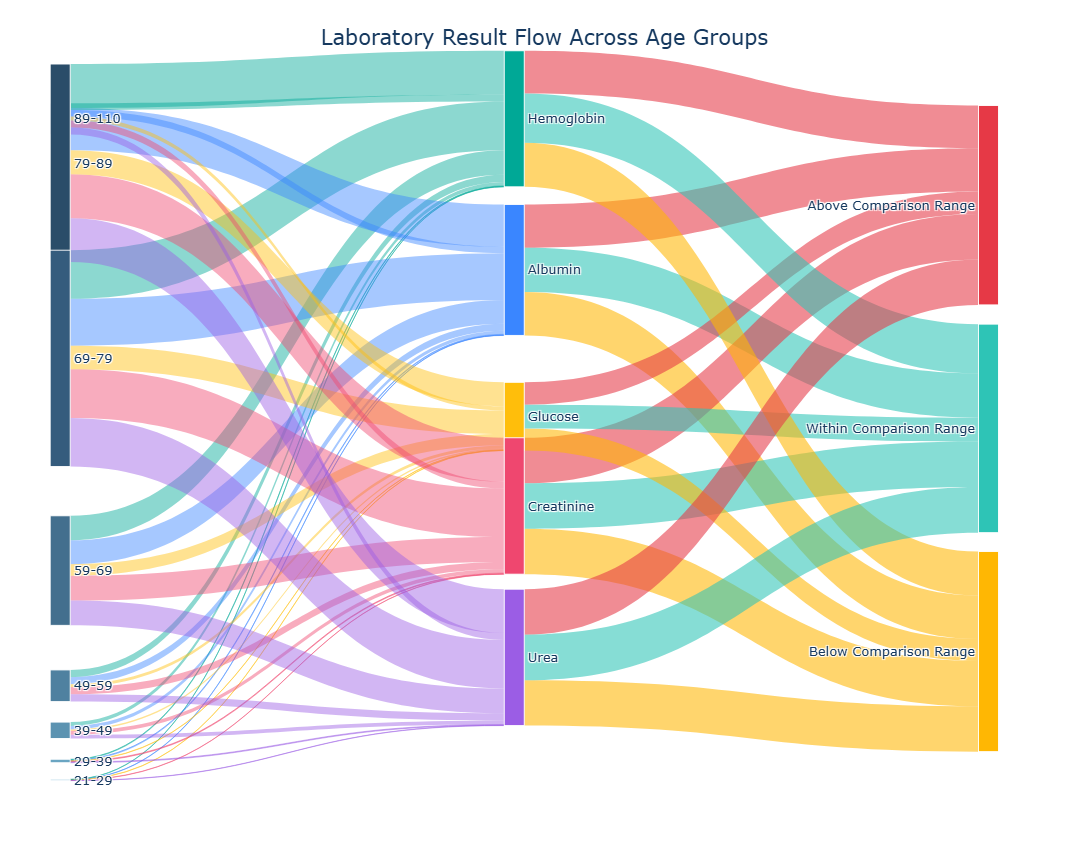

In [8]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import re

# --------------------------------------------------
# 1. Select laboratory biomarkers
# --------------------------------------------------

lab_options = {
    "Hemoglobin": ["hemoglobin", "hemoglobin_blood_gas"],
    "Albumin": ["albumin", "albumin_serum"],
    "Glucose": ["glucose_blood_gas", "glucose"],
    "Creatinine": ["creatinine_enzymatic_method", "creatinine"],
    "Urea": ["urea"]
}

selected_labs = {}

for label, options in lab_options.items():
    col = next((c for c in options if c in patient.columns), None)
    if col:
        selected_labs[label] = col

if not selected_labs:
    raise ValueError("No laboratory biomarkers found.")


# --------------------------------------------------
# 2. Define result categories
# --------------------------------------------------

ABOVE = "Above Comparison Range"
WITHIN = "Within Comparison Range"
BELOW = "Below Comparison Range"

# Keep this exact order for the last column
result_categories = [ABOVE, WITHIN, BELOW]


# --------------------------------------------------
# 3. Prepare laboratory data
# --------------------------------------------------

results = []

for label, col in selected_labs.items():

    tmp = patient[["inpatient_number", "agecat", col]].copy()

    tmp[col] = pd.to_numeric(tmp[col], errors="coerce")
    tmp[col] = tmp[col].replace([np.inf, -np.inf], np.nan)
    tmp = tmp.dropna()

    if tmp.empty:
        continue

    # Keep one measurement per inpatient number and age group
    tmp = (
        tmp.groupby(
            ["inpatient_number", "agecat"],
            observed=True,
            as_index=False
        )[col]
        .median()
    )

    # Comparison limits based on dataset thirds
    lower = tmp[col].quantile(1/3)
    upper = tmp[col].quantile(2/3)

    if lower >= upper:
        continue

    # Classify results
    tmp["Lab Result"] = np.select(
        [
            tmp[col] > upper,
            tmp[col] < lower
        ],
        [
            ABOVE,
            BELOW
        ],
        default=WITHIN
    )

    tested = (
        tmp.groupby("agecat", observed=True)
        .size()
        .rename("Tested Patients")
        .reset_index()
    )

    summary = (
        tmp.groupby(
            ["agecat", "Lab Result"],
            observed=True
        )
        .size()
        .reset_index(name="Patient Count")
    )

    summary = summary.merge(
        tested,
        on="agecat",
        how="left"
    )

    summary["Biomarker"] = label
    summary["Patient Percentage"] = (
        summary["Patient Count"] / summary["Tested Patients"] * 100
    )

    results.append(summary)

if not results:
    raise ValueError("No laboratory results available.")

sankey_df = pd.concat(results, ignore_index=True)
sankey_df = sankey_df.rename(columns={"agecat": "Age Category"})
sankey_df["Age Category"] = sankey_df["Age Category"].astype(str)


# --------------------------------------------------
# 4. Define improved colors
# --------------------------------------------------

# Richer biomarker colors
lab_colors = {
    "Hemoglobin": "#00A896",   # bright teal
    "Albumin": "#3A86FF",      # vivid blue
    "Glucose": "#FFBE0B",      # bright yellow
    "Creatinine": "#EF476F",   # vivid pink-red
    "Urea": "#9B5DE5"          # vibrant purple
}

# Age-group colors: darker blue-teal family
age_colors = [
    "#1D3557",
    "#2A4D69",
    "#355C7D",
    "#436F8E",
    "#4F81A0",
    "#5C93B1",
    "#6AA5C2",
    "#78B7D3"
]

# Result-category colors
result_colors = {
    ABOVE: "#E63946",   # vivid red
    WITHIN: "#2EC4B6",  # brighter teal
    BELOW: "#FFB703"    # brighter yellow
}


# --------------------------------------------------
# 5. Create correctly ordered node lists
# --------------------------------------------------

def age_sort_key(age):
    nums = re.findall(r"\d+", str(age))
    return int(nums[0]) if nums else -1

# DESCENDING age order
age_nodes = sorted(
    sankey_df["Age Category"].unique(),
    key=age_sort_key,
    reverse=True
)

lab_nodes = [lab for lab in lab_options if lab in sankey_df["Biomarker"].unique()]
result_nodes = [r for r in result_categories if r in sankey_df["Lab Result"].unique()]

age_ids = [f"age:{x}" for x in age_nodes]
lab_ids = [f"lab:{x}" for x in lab_nodes]
result_ids = [f"result:{x}" for x in result_nodes]

all_ids = age_ids + lab_ids + result_ids
all_labels = age_nodes + lab_nodes + result_nodes

node_map = {node_id: i for i, node_id in enumerate(all_ids)}


# --------------------------------------------------
# 6. Create Sankey connections
# --------------------------------------------------

links_1 = (
    sankey_df.groupby(
        ["Age Category", "Biomarker"],
        observed=True
    )["Patient Count"]
    .sum()
    .reset_index()
)

links_2 = (
    sankey_df.groupby(
        ["Biomarker", "Lab Result"],
        observed=True
    )["Patient Count"]
    .sum()
    .reset_index()
)

source = (
    [node_map[f"age:{age}"] for age in links_1["Age Category"]] +
    [node_map[f"lab:{lab}"] for lab in links_2["Biomarker"]]
)

target = (
    [node_map[f"lab:{lab}"] for lab in links_1["Biomarker"]] +
    [node_map[f"result:{result}"] for result in links_2["Lab Result"]]
)

values = (
    links_1["Patient Count"].tolist() +
    links_2["Patient Count"].tolist()
)


# --------------------------------------------------
# 7. Assign node colors
# --------------------------------------------------

node_colors = []

for label in all_labels:
    if label in age_nodes:
        node_colors.append(age_colors[age_nodes.index(label) % len(age_colors)])
    elif label in lab_nodes:
        node_colors.append(lab_colors[label])
    else:
        node_colors.append(result_colors[label])


# --------------------------------------------------
# 8. Create transparent link colors
# --------------------------------------------------

def hex_to_rgba(hex_color, opacity=0.55):
    hex_color = hex_color.lstrip("#")
    r = int(hex_color[0:2], 16)
    g = int(hex_color[2:4], 16)
    b = int(hex_color[4:6], 16)
    return f"rgba({r},{g},{b},{opacity})"

link_colors = []

# Age -> Biomarker links use biomarker colors
for lab in links_1["Biomarker"]:
    link_colors.append(hex_to_rgba(lab_colors[lab], opacity=0.45))

# Biomarker -> Result links use result colors
for result in links_2["Lab Result"]:
    link_colors.append(hex_to_rgba(result_colors[result], opacity=0.58))


# --------------------------------------------------
# 9. Position nodes
# --------------------------------------------------

CHART_HEIGHT = 850
PLOT_HEIGHT = 730
NODE_PAD = 16

total_flow = links_1["Patient Count"].sum()
max_nodes = max(len(age_nodes), len(lab_nodes), len(result_nodes))
usable_height = PLOT_HEIGHT * 0.92

flow_scale = (
    usable_height - (max_nodes - 1) * NODE_PAD
) / total_flow


def calculate_positions(labels, counts):
    counts = np.array(counts, dtype=float)
    total_node_height = counts.sum() * flow_scale

    if len(labels) > 1:
        gap = (usable_height - total_node_height) / (len(labels) - 1)
    else:
        gap = 0

    positions = []
    current_y = PLOT_HEIGHT * 0.04

    for count in counts:
        positions.append(current_y / PLOT_HEIGHT)
        current_y += count * flow_scale + gap

    return positions


# Age-group positions (descending order already set)
age_counts = (
    links_1.groupby("Age Category")["Patient Count"]
    .sum()
    .reindex(age_nodes)
    .fillna(0)
)
age_y = calculate_positions(age_nodes, age_counts.values)

# Biomarker positions
lab_counts = (
    links_1.groupby("Biomarker")["Patient Count"]
    .sum()
    .reindex(lab_nodes)
    .fillna(0)
)
lab_y = calculate_positions(lab_nodes, lab_counts.values)

# Result positions: top -> above, middle -> within, bottom -> below
result_y_map = {
    ABOVE: 0.16,
    WITHIN: 0.47,
    BELOW: 0.78
}
result_y = [result_y_map[r] for r in result_nodes]

x_positions = (
    [0.02] * len(age_nodes) +
    [0.47] * len(lab_nodes) +
    [0.94] * len(result_nodes)
)

y_positions = age_y + lab_y + result_y


# --------------------------------------------------
# 10. Create Sankey chart
# --------------------------------------------------

fig = go.Figure(
    go.Sankey(
        arrangement="fixed",

        node=dict(
            pad=NODE_PAD,
            thickness=20,
            line=dict(color="white", width=0.9),
            label=all_labels,
            color=node_colors,
            x=x_positions,
            y=y_positions,
            hovertemplate=(
                "<b>%{label}</b><br>"
                "Count: %{value:,.0f}"
                "<extra></extra>"
            )
        ),

        link=dict(
            source=source,
            target=target,
            value=values,
            color=link_colors,
            hovertemplate=(
                "<b>%{source.label}</b> → <b>%{target.label}</b><br>"
                "Count: %{value:,.0f}"
                "<extra></extra>"
            )
        )
    )
)


# --------------------------------------------------
# 11. Customize chart appearance
# --------------------------------------------------

fig.update_layout(
    title=dict(
        text="Laboratory Result Flow Across Age Groups",
        x=0.5,
        font=dict(
            size=21,
            color="#16395F"
        )
    ),
    height=CHART_HEIGHT,
    paper_bgcolor="white",
    plot_bgcolor="white",
    font=dict(
        size=13,
        color="#16395F"
    ),
    margin=dict(
        t=90,
        l=40,
        r=40,
        b=40
    )
)

fig.show()


* Actual Insight

The chart shows that older age groups, particularly 69–79 and 79–89, account for a larger number of laboratory results across the different comparison ranges. Hemoglobin, albumin, glucose, creatinine, and urea show different distributions across these groups. This helps identify which laboratory measurements may need closer attention when reviewing older patients.

# PA5: Among patients receiving multiple medications, which age groups show the greatest medication burden, and how do their glucose levels differ across these groups? 

## Prescription Medication and Laboratory Results — Sunburst Chart
### Reasoning

Combining prescription records with glucose measurements helps us understand how laboratory results vary among patients taking different numbers of medications. A Sunburst chart shows these patterns across age groups, making it easier to identify patient groups that may benefit from further laboratory and medication review.

Medication column: drug_name


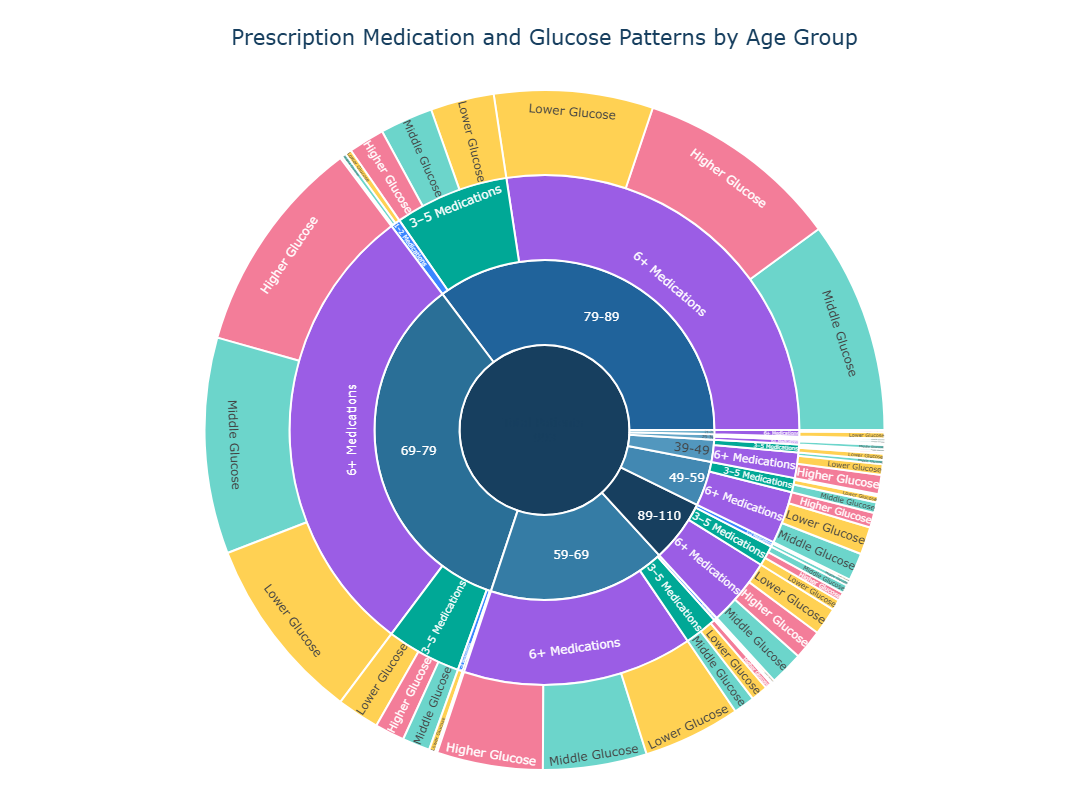

In [9]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import re

# --------------------------------------------------
# 1. Define columns
# --------------------------------------------------

ID_COL = "inpatient_number"
AGE_COL = "agecat"
GLUCOSE_COL = "glucose_blood_gas"

# Identify medication column
med_options = [
    "drug_name",
    "medication_name",
    "medicine_name",
    "prescription_name",
    "generic_name",
    "drug",
    "medication",
    "medicine",
    "drug_class",
    "drug_code"
]

MED_COL = next(
    (col for col in med_options if col in prescriptions.columns),
    None
)

if MED_COL is None:

    print("Available prescription columns:")
    print(prescriptions.columns.tolist())

    raise ValueError(
        "Please select the correct medication column."
    )

print("Medication column:", MED_COL)


# --------------------------------------------------
# 2. Prepare patient and glucose data
# --------------------------------------------------

tmp = patient[
    [ID_COL, AGE_COL, GLUCOSE_COL]
].copy()

tmp[GLUCOSE_COL] = pd.to_numeric(
    tmp[GLUCOSE_COL],
    errors="coerce"
)

tmp[GLUCOSE_COL] = tmp[GLUCOSE_COL].replace(
    [np.inf, -np.inf],
    np.nan
)

tmp = tmp.dropna(
    subset=[ID_COL, AGE_COL, GLUCOSE_COL]
)

# Standardize inpatient IDs
tmp[ID_COL] = (
    tmp[ID_COL]
    .astype(str)
    .str.strip()
)

# Keep one glucose measurement per inpatient ID
# Use the median if multiple results are available
glucose_data = (
    tmp.groupby(
        ID_COL,
        as_index=False
    )
    .agg({
        AGE_COL: "first",
        GLUCOSE_COL: "median"
    })
)


# --------------------------------------------------
# 3. Count distinct prescribed medications
# --------------------------------------------------

med_data = prescriptions[
    [ID_COL, MED_COL]
].copy()

med_data = med_data.dropna()

med_data[ID_COL] = (
    med_data[ID_COL]
    .astype(str)
    .str.strip()
)

med_data[MED_COL] = (
    med_data[MED_COL]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Remove blank medication names
med_data = med_data[
    med_data[MED_COL] != ""
]

# Count unique medication names per inpatient ID
med_counts = (
    med_data.groupby(ID_COL)[MED_COL]
    .nunique()
    .reset_index(name="Medication Count")
)

# Combine glucose and prescription information
sunburst_data = glucose_data.merge(
    med_counts,
    on=ID_COL,
    how="left"
)

# No matching prescription record
sunburst_data["Medication Count"] = (
    sunburst_data["Medication Count"]
    .fillna(0)
    .astype(int)
)


# --------------------------------------------------
# 4. Create medication categories
# --------------------------------------------------

def medication_group(count):

    if count == 0:
        return "No Prescription Listed"

    elif count <= 2:
        return "1–2 Medications"

    elif count <= 5:
        return "3–5 Medications"

    else:
        return "6+ Medications"


sunburst_data["Medication Group"] = (
    sunburst_data["Medication Count"]
    .apply(medication_group)
)


# --------------------------------------------------
# 5. Create glucose comparison categories
# --------------------------------------------------

lower = sunburst_data[GLUCOSE_COL].quantile(1/3)
upper = sunburst_data[GLUCOSE_COL].quantile(2/3)

if lower >= upper:
    raise ValueError(
        "Glucose values cannot be divided into three distinct groups."
    )

sunburst_data["Glucose Level"] = np.select(

    [
        sunburst_data[GLUCOSE_COL] < lower,
        sunburst_data[GLUCOSE_COL] > upper
    ],

    [
        "Lower Glucose",
        "Higher Glucose"
    ],

    default="Middle Glucose"
)


# --------------------------------------------------
# 6. Prepare summary for Sunburst
# --------------------------------------------------

sunburst_data["Age Category"] = (
    sunburst_data[AGE_COL].astype(str)
)

summary = (
    sunburst_data.groupby(
        [
            "Age Category",
            "Medication Group",
            "Glucose Level"
        ],
        observed=True
    )
    .size()
    .reset_index(name="Patient Count")
)

# Total tested patients in each age and medication group
summary["Tested Patients"] = (
    summary.groupby(
        ["Age Category", "Medication Group"]
    )["Patient Count"]
    .transform("sum")
)

summary["Patient Percentage"] = (
    summary["Patient Count"]
    / summary["Tested Patients"]
    * 100
)


# --------------------------------------------------
# 7. Define colors
# --------------------------------------------------

age_colors = [
    "#173F5F",
    "#20639B",
    "#2A6F97",
    "#357CA5",
    "#4288B2",
    "#5297BE",
    "#63A5C6",
    "#74B3CE"
]

med_colors = {
    "No Prescription Listed": "#94A3B8",
    "1–2 Medications": "#3A86FF",
    "3–5 Medications": "#00A896",
    "6+ Medications": "#9B5DE5"
}

glucose_colors = {
    "Lower Glucose": "#FFBE0B",
    "Middle Glucose": "#2EC4B6",
    "Higher Glucose": "#EF476F"
}


# --------------------------------------------------
# 8. Define category order
# --------------------------------------------------

def age_sort_key(age):

    numbers = re.findall(
        r"\d+",
        str(age)
    )

    return int(numbers[0]) if numbers else -1


age_nodes = sorted(
    summary["Age Category"].unique(),
    key=age_sort_key,
    reverse=True
)

med_nodes = [
    "No Prescription Listed",
    "1–2 Medications",
    "3–5 Medications",
    "6+ Medications"
]

glucose_nodes = [
    "Higher Glucose",
    "Middle Glucose",
    "Lower Glucose"
]


# --------------------------------------------------
# 9. Build Sunburst hierarchy
# --------------------------------------------------

nodes = []

def add_node(node_id, label, parent, count, color, hover):

    nodes.append({
        "id": node_id,
        "label": label,
        "parent": parent,
        "value": int(count),
        "color": color,
        "hover": hover
    })


# Main circle - Total Patients

total_patients = int(
    summary["Patient Count"].sum()
)

add_node(
    "root",
    f"Total Patients<br>{total_patients:,}",
    "",
    total_patients,
    "#173F5F",
    (
        f"<b>Total Patients: {total_patients:,}</b><br>"
    )
)


# Age groups
for i, age in enumerate(age_nodes):

    age_data = summary[
        summary["Age Category"] == age
    ]

    age_id = f"age:{age}"

    age_count = age_data["Patient Count"].sum()

    add_node(
        age_id,
        age,
        "root",
        age_count,
        age_colors[i % len(age_colors)],
        (
            f"<b>Age Group: {age}</b><br>"
            f"Tested Patients: {int(age_count):,}"
        )
    )

    # Medication groups
    for med in med_nodes:

        med_data_group = age_data[
            age_data["Medication Group"] == med
        ]

        if med_data_group.empty:
            continue

        med_id = f"{age_id}|med:{med}"

        med_count = med_data_group[
            "Patient Count"
        ].sum()

        add_node(
            med_id,
            med,
            age_id,
            med_count,
            med_colors[med],
            (
                f"<b>{med}</b><br>"
                f"Age Group: {age}<br>"
                f"Patient Count: {int(med_count):,}"
            )
        )

        # Glucose categories
        for glucose in glucose_nodes:

            glucose_data_group = med_data_group[
                med_data_group["Glucose Level"] == glucose
            ]

            if glucose_data_group.empty:
                continue

            row = glucose_data_group.iloc[0]

            count = int(row["Patient Count"])
            tested = int(row["Tested Patients"])
            percentage = float(row["Patient Percentage"])

            add_node(
                f"{med_id}|glucose:{glucose}",
                glucose,
                med_id,
                count,
                glucose_colors[glucose],

                (
                    f"<b>{glucose}</b><br>"
                    f"Age Group: {age}<br>"
                    f"Medication Group: {med}<br>"
                    f"Patient Count: {count:,}<br>"
                    f"Tested Patients: {tested:,}<br>"
                    f"Patient Percentage: {percentage:.1f}%"
                )
            )


# --------------------------------------------------
# 10. Create Sunburst chart
# --------------------------------------------------

fig = go.Figure(

    go.Sunburst(

        ids=[
            n["id"]
            for n in nodes
        ],

        labels=[
            n["label"]
            for n in nodes
        ],

        parents=[
            n["parent"]
            for n in nodes
        ],

        values=[
            n["value"]
            for n in nodes
        ],

        branchvalues="total",

        marker=dict(
            colors=[
                n["color"]
                for n in nodes
            ],

            line=dict(
                color="white",
                width=2
            )
        ),

        customdata=[
            n["hover"]
            for n in nodes
        ],

        hovertemplate=(
            "%{customdata}"
            "<extra></extra>"
        ),

        text=[
            f"Total Patients <br>{total_patients:,}"
                if n["id"] == "root"
                else n["label"]
                for n in nodes
            ],

        textinfo="text",
        texttemplate="%{text}",
        insidetextorientation="auto",
        maxdepth=4

    )
)


# --------------------------------------------------
# 11. Customize chart appearance
# --------------------------------------------------

fig.update_layout(

    title=dict(
        text="Prescription Medication and Glucose Patterns by Age Group",
        x=0.5,
        font=dict(
            size=21,
            color="#173F5F"
        )
    ),

    height=800,

    paper_bgcolor="white",

    font=dict(
        size=12,
        color="#173F5F"
    ),

    margin=dict(
        t=90,
        l=30,
        r=30,
        b=30
    )
)

fig.show()



## Actual Insight:
The code will automatically identify the age and medication group with the highest percentage of higher glucose measurements, among groups with at least 30 tested inpatient records.

You can use that output as the starting point for your notebook's Actual Insight. We should describe the specific age group, medication count, and percentage after you execute it.

## PA7.Which age groups show clinically meaningful differences in laboratory values and blood pressure measurements that may indicate a need for closer monitoring or follow-up?
## Laboratory and Blood Pressure Profiles by Age Category
## Reasoning
Comparing hemoglobin, glucose, creatinine, and systolic blood pressure across age groups helps us understand how these health measurements are related. A Pair Plot shows how the measurements vary together and helps identify age groups with patterns that may need further review.

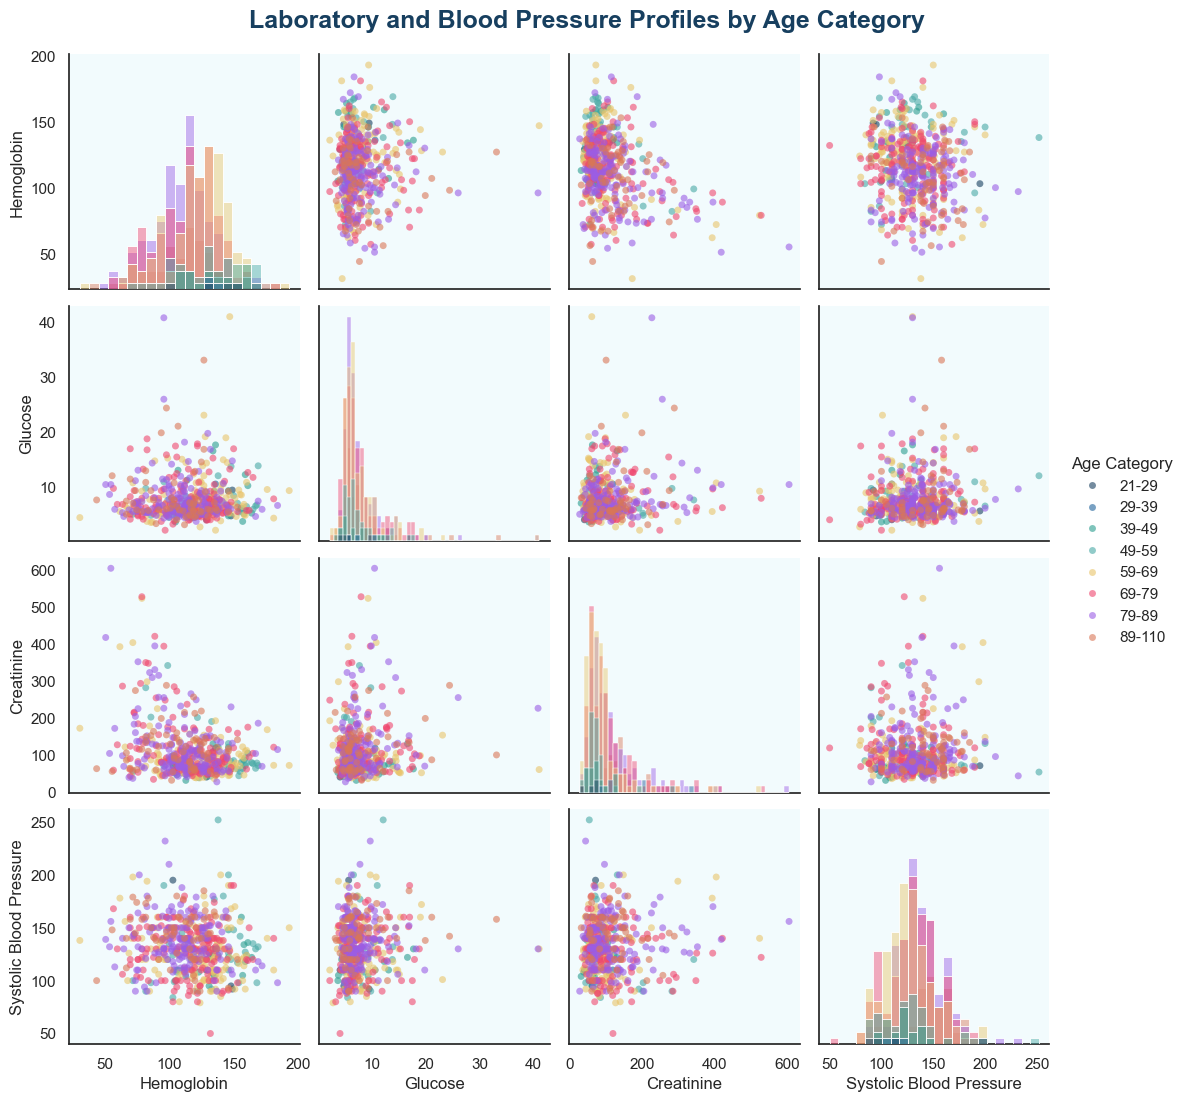

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# --------------------------------------------------
# 1. Select laboratory and blood pressure measurements
# --------------------------------------------------

selected_columns = {
    "hemoglobin": "Hemoglobin",
    "glucose_blood_gas": "Glucose",
    "creatinine_enzymatic_method": "Creatinine",
    "systolic_blood_pressure": "Systolic Blood Pressure"
}

# Check available columns
available_columns = {
    col: label
    for col, label in selected_columns.items()
    if col in patient.columns
}

if len(available_columns) < 3:
    raise ValueError(
        "At least three measurements are required."
    )


# --------------------------------------------------
# 2. Prepare patient data
# --------------------------------------------------

tmp = patient[
    ["inpatient_number", "agecat"]
    + list(available_columns.keys())
].copy()

# Convert measurements to numeric
for col in available_columns:

    tmp[col] = pd.to_numeric(
        tmp[col],
        errors="coerce"
    )

    tmp[col] = tmp[col].replace(
        [np.inf, -np.inf],
        np.nan
    )

# Remove records without age or inpatient number
tmp = tmp.dropna(
    subset=["inpatient_number", "agecat"]
)

# Keep one laboratory profile per inpatient number
tmp = (
    tmp.groupby(
        "inpatient_number",
        as_index=False
    )
    .agg({
        "agecat": "first",
        **{
            col: "median"
            for col in available_columns
        }
    })
)

# Rename columns
tmp = tmp.rename(
    columns=available_columns
)

tmp = tmp.rename(
    columns={"agecat": "Age Category"}
)

markers = list(available_columns.values())

# Keep complete profiles
tmp = tmp.dropna(
    subset=markers
)

if tmp.empty:
    raise ValueError(
        "No complete laboratory profiles available."
    )


# --------------------------------------------------
# 3. Arrange age categories
# --------------------------------------------------

def age_sort_key(age):

    numbers = re.findall(
        r"\d+",
        str(age)
    )

    return int(numbers[0]) if numbers else -1


tmp["Age Category"] = (
    tmp["Age Category"].astype(str)
)

age_order = sorted(
    tmp["Age Category"].unique(),
    key=age_sort_key
)


# --------------------------------------------------
# 4. Define colors
# --------------------------------------------------

colors = [
    "#173F5F",
    "#20639B",
    "#2A9D8F",
    "#48A9A6",
    "#E9C46A",
    "#EF476F",
    "#9B5DE5",
    "#D97757"
]

palette = {
    age: colors[i % len(colors)]
    for i, age in enumerate(age_order)
}


# --------------------------------------------------
# 5. Prepare data for visualization
# --------------------------------------------------

# Use a maximum of 150 records per age category
# to prevent too many overlapping points.

MAX_PER_AGE = 150

plot_data = pd.concat(
    [
        group.sample(
            n=min(len(group), MAX_PER_AGE),
            random_state=42
        )

        for _, group in tmp.groupby(
            "Age Category"
        )
    ],
    ignore_index=True
)


# --------------------------------------------------
# 6. Create Pair Plot
# --------------------------------------------------

sns.set_theme(
    style="white",
    font_scale=1.0
)

g = sns.pairplot(

    data=plot_data,

    vars=markers,

    hue="Age Category",

    hue_order=age_order,

    palette=palette,

    diag_kind="hist",

    diag_kws={
        "alpha": 0.45
    },

    plot_kws={
        "alpha": 0.60,
        "s": 25,
        "edgecolor": "none"
    },

    height=2.7,

    aspect=1
)


# --------------------------------------------------
# 7. Customize chart
# --------------------------------------------------

g.fig.suptitle(
    "Laboratory and Blood Pressure Profiles by Age Category",
    fontsize=18,
    fontweight="bold",
    color="#173F5F",
    y=1.02
)

g.fig.set_facecolor("white")

for ax in g.axes.flat:

    if ax is not None:

        ax.set_facecolor("#F2FBFD")

        ax.grid(
            False
        )

if g._legend is not None:

    g._legend.set_title(
        "Age Category"
    )

plt.show()




## Actual Insight

The Pair Plot helps identify differences in laboratory measurements and blood pressure across age groups. It also shows whether certain measurements tend to increase or decrease together. These patterns can help highlight patient groups that may benefit from closer laboratory and blood pressure monitoring.

## PA8: How do key clinical biomarkers—hemoglobin, albumin, glucose, and creatinine—vary across age groups, and what age-related patterns emerge in these laboratory measurements? 
## Reasoning

Comparing laboratory measurements across age groups helps us understand how values differ among patients. A violin chart shows where most measurements are concentrated, how much they vary, and whether certain age groups have unusually high or low values.

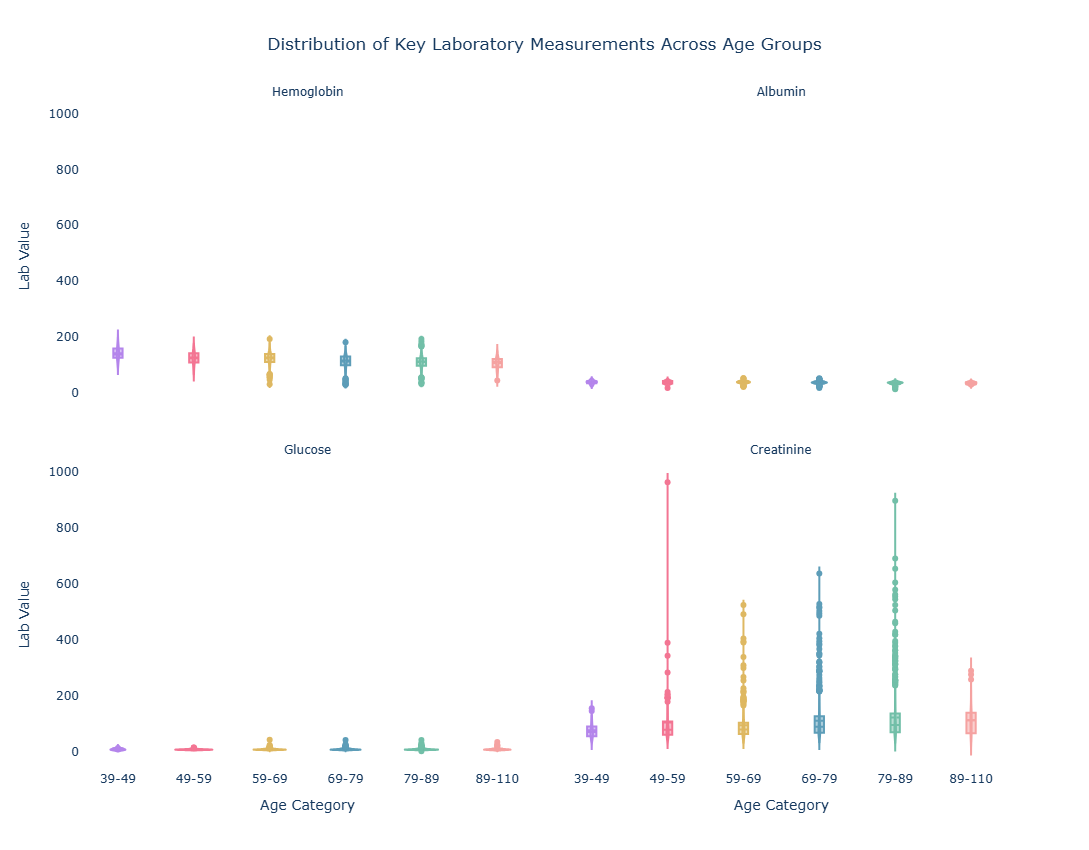


Actual Insight:

Creatinine showed the widest spread in the 89-110 age group. The median value was 110.90, and the middle 50% of values ranged from 64.40 to 138.10. This suggests that patients in this age group had more variation in creatinine than the other groups shown.


In [12]:
import pandas as pd
import numpy as np
import plotly.express as px
import re

# --------------------------------------------------
# 1. Select laboratory biomarkers
# --------------------------------------------------

lab_options = {
    "Hemoglobin": ["hemoglobin", "hemoglobin_blood_gas"],
    "Albumin": ["albumin", "albumin_serum"],
    "Glucose": ["glucose_blood_gas", "glucose"],
    "Creatinine": ["creatinine_enzymatic_method", "creatinine"]
}

selected_labs = {}

for label, options in lab_options.items():
    col = next((c for c in options if c in patient.columns), None)
    if col:
        selected_labs[label] = col

if len(selected_labs) < 2:
    raise ValueError("At least two laboratory biomarkers are required.")


# --------------------------------------------------
# 2. Prepare patient data
# --------------------------------------------------

tmp = patient[
    ["inpatient_number", "agecat"] + list(selected_labs.values())
].copy()

# Convert lab values to numeric
for col in selected_labs.values():
    tmp[col] = pd.to_numeric(tmp[col], errors="coerce")
    tmp[col] = tmp[col].replace([np.inf, -np.inf], np.nan)

# Remove rows missing inpatient ID or age category
tmp = tmp.dropna(subset=["inpatient_number", "agecat"])

# Keep one lab profile per inpatient number
tmp = (
    tmp.groupby("inpatient_number", as_index=False)
    .agg({
        "agecat": "first",
        **{col: "median" for col in selected_labs.values()}
    })
)

# Rename columns for readability
tmp = tmp.rename(
    columns={
        "agecat": "Age Category",
        **{col: label for label, col in selected_labs.items()}
    }
)

# --------------------------------------------------
# 3. Arrange age groups
# --------------------------------------------------

def age_sort_key(age):
    numbers = re.findall(r"\d+", str(age))
    return int(numbers[0]) if numbers else -1

tmp["Age Category"] = tmp["Age Category"].astype(str)

age_order = sorted(
    tmp["Age Category"].dropna().unique(),
    key=age_sort_key
)

# --------------------------------------------------
# 4. Convert to long format
# --------------------------------------------------

long_df = tmp.melt(
    id_vars=["inpatient_number", "Age Category"],
    value_vars=list(selected_labs.keys()),
    var_name="Biomarker",
    value_name="Lab Value"
)

long_df = long_df.dropna(subset=["Lab Value"])

# Keep only age groups with enough records
age_counts = (
    long_df.groupby(["Biomarker", "Age Category"], observed=True)
    .size()
    .reset_index(name="Patient Count")
)

valid_groups = age_counts[age_counts["Patient Count"] >= 20][
    ["Biomarker", "Age Category"]
]

long_df = long_df.merge(
    valid_groups,
    on=["Biomarker", "Age Category"],
    how="inner"
)

if long_df.empty:
    raise ValueError("Not enough data available for the violin chart.")


# --------------------------------------------------
# 5. Create violin chart
# --------------------------------------------------

color_map = {
    "21-29": "#3A86FF",
    "29-39": "#00A896",
    "39-49": "#9B5DE5",
    "49-59": "#EF476F",
    "59-69": "#D4A12E",
    "69-79": "#277DA1",
    "79-89": "#43AA8B",
    "89-110": "#F28482"
}

fig = px.violin(
    long_df,
    x="Age Category",
    y="Lab Value",
    color="Age Category",
    facet_col="Biomarker",
    facet_col_wrap=2,
    box=True,
    points="outliers",
    category_orders={"Age Category": age_order},
    color_discrete_map=color_map,
    title="Distribution of Key Laboratory Measurements Across Age Groups"
)

fig.update_traces(
    meanline_visible=True,
    opacity=0.75
)

fig.update_layout(
    height=850,
    title_x=0.5,
    paper_bgcolor="white",
    plot_bgcolor="white",
    font=dict(size=12, color="#16395F"),
    showlegend=False
)

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)

fig.for_each_annotation(
    lambda a: a.update(text=a.text.split("=")[-1])
)

fig.show()


# --------------------------------------------------
# 6. Generate actual insight
# --------------------------------------------------

summary = (
    long_df.groupby(["Biomarker", "Age Category"], observed=True)["Lab Value"]
    .agg(
        Median="median",
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75),
        Count="count"
    )
    .reset_index()
)

summary["IQR"] = summary["Q3"] - summary["Q1"]

# Keep groups with enough records
summary = summary[summary["Count"] >= 20]

if not summary.empty:
    top = summary.sort_values("IQR", ascending=False).iloc[0]

    print("\nActual Insight:\n")
    print(
        f"{top['Biomarker']} showed the widest spread in the "
        f"{top['Age Category']} age group. "
        f"The median value was {top['Median']:.2f}, and the middle 50% "
        f"of values ranged from {top['Q1']:.2f} to {top['Q3']:.2f}. "
        f"This suggests that patients in this age group had more variation "
        f"in {top['Biomarker'].lower()} than the other groups shown."
    )
else:
    print("Not enough age groups had enough records to generate an insight.")

## Actual Insight

The violin chart highlights differences in laboratory measurements across age groups. Some groups may show a wider spread of values, while others have measurements concentrated within a smaller range. These patterns help us understand how laboratory profiles vary with age and identify measurements that may need further investigation.

### PA10: Which patient groups at hospital discharge, based on their demographic, cardiac, comorbidity, laboratory, neurological, respiratory, hospital stay, and medication characteristics, have higher rates of readmission or emergency department return, and which groups may need enhanced discharge planning and earlier follow-up?

### Type of Analysis
Prescriptive Analysis: Clustered Heatmap with Dendrogram and Post-Discharge Outcome Bar Chart
### Reasoning
This prescriptive analysis groups patients with similar discharge characteristics and compares their readmission and ED-return patterns to identify groups that may benefit from closer follow-up and enhanced discharge planning.

In [13]:

# ============================================================
# 1. IMPORTS AND FILE SETUP
# ============================================================

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

# ------------------------------------------------------------
# File resolver:
# The notebook works if the CSV files are either:
#   1) in the same folder as this notebook, OR
#   2) in /mnt/data (ChatGPT environment).
# ------------------------------------------------------------

# Define the main project folder
project_folder = Path(
    r"C:\Users\swith\OneDrive\Desktop\Swithi\Numpy Ninja\Python Hackathon Sept 2026\Python_Hackathon_Sep_2026\cardiac_failure\__Final_Cleaned Dataset"
)

# Define CSV filenames


FILES = {
    "cardiac": "Team7_CodeAvengers_Category1_DataCleaning_cardiac_complications.csv",
    "demography": "Team7_CodeAvengers_Category1_DataCleaning_demography.csv",
    "hospital": "Team7_CodeAvengers_Category1_DataCleaning_hospitalization_discharge.csv", 
    "labs": "Team7_CodeAvengers_Category1_DataCleaning_labs.csv",
    "prescriptions": "Team7_CodeAvengers_Category1_DataCleaning_patient_precriptions.csv",
    "history": "Team7_CodeAvengers_Category1_DataCleaning_patienthistory_cleaned.csv",
    "responsiveness": "Team7_CodeAvengers_Category1_DataCleaning_responsivenes.csv"
    }


In [14]:

# ============================================================
# 2. LOAD ALL CLEANED DATASETS
# ============================================================


# Read the cleaned datasets
cardiac = pd.read_csv(project_folder / FILES["cardiac"])
demography = pd.read_csv(project_folder / FILES["demography"])
hospital = pd.read_csv(project_folder / FILES["hospital"])
labs = pd.read_csv(project_folder / FILES["labs"])
prescriptions = pd.read_csv(project_folder / FILES["prescriptions"])
history = pd.read_csv(project_folder / FILES["history"])
responsiveness = pd.read_csv(project_folder / FILES["responsiveness"])

datasets = {
    "Cardiac": cardiac,
    "Demography": demography,
    "Hospitalization/Discharge": hospital,
    "Labs": labs,
    "Prescriptions": prescriptions,
    "Patient History": history,
    "Responsiveness": responsiveness
}

print("Dataset dimensions")
for name, df in datasets.items():
    print(f"{name:25s}: {df.shape[0]:5d} rows x {df.shape[1]:3d} columns")

# Confirm merge key
for name, df in datasets.items():
    if "inpatient_number" not in df.columns:
        raise KeyError(f"'inpatient_number' is missing from {name}.")


Dataset dimensions
Cardiac                  :  2008 rows x  14 columns
Demography               :  2008 rows x   7 columns
Hospitalization/Discharge:  2008 rows x  21 columns
Labs                     :  2008 rows x 107 columns
Prescriptions            : 15362 rows x   2 columns
Patient History          :  2008 rows x  17 columns
Responsiveness           :  2008 rows x   6 columns


In [15]:

# ============================================================
# 3. AGGREGATE PRESCRIPTIONS TO ONE ROW PER PATIENT
# ============================================================

# Prescription data contains multiple rows per patient.
# Convert it into patient-level medication burden before merging.
rx_agg = (
    prescriptions
    .groupby("inpatient_number", as_index=False)
    .agg(
        medication_count=("drug_name", "size"),
        unique_medications=("drug_name", "nunique")
    )
)

print("Prescription records:", len(prescriptions))
print("Patients with prescription records:", rx_agg["inpatient_number"].nunique())


Prescription records: 15362
Patients with prescription records: 2007


In [16]:

# ============================================================
# 4. MERGE ALL SEVEN DATA SOURCES
# ============================================================

merged = (
    demography
    .merge(cardiac, on="inpatient_number", how="inner")
    .merge(history, on="inpatient_number", how="inner")
    .merge(labs, on="inpatient_number", how="inner")
    .merge(responsiveness, on="inpatient_number", how="inner")
    .merge(hospital, on="inpatient_number", how="inner")
    .merge(rx_agg, on="inpatient_number", how="left")
)

merged[["medication_count", "unique_medications"]] = (
    merged[["medication_count", "unique_medications"]].fillna(0)
)

print("Merged patient-level dataset:", merged.shape)
print("Unique patients:", merged["inpatient_number"].nunique())


Merged patient-level dataset: (2008, 169)
Unique patients: 2008


In [17]:

# ============================================================
# 5. DERIVE ANALYSIS VARIABLES
# ============================================================

# Approximate numeric age from the provided age categories.
# This preserves the dataset's existing categorization while allowing clustering.
age_midpoint_map = {
    "21-29": 25.0,
    "29-39": 34.0,
    "39-49": 44.0,
    "49-59": 54.0,
    "59-69": 64.0,
    "69-79": 74.0,
    "79-89": 84.0,
    "89-110": 99.5
}
merged["age_midpoint"] = merged["agecat"].map(age_midpoint_map)

# Respiratory-support indicators
merged["imv_flag"] = (
    merged["respiratory_support"].astype(str).str.upper().eq("IMV")
).astype(int)

merged["oxygen_therapy_flag"] = (
    merged["oxygen_inhalation"].astype(str).str.lower().str.contains("oxygen")
).astype(int)

# Comorbidity count across available binary history indicators
comorbidity_columns = [
    "cerebrovascular_disease",
    "dementia",
    "chronic_obstructive_pulmonary_disease",
    "connective_tissue_disease",
    "peptic_ulcer_disease",
    "diabetes",
    "moderate_to_severe_chronic_kidney_disease",
    "hemiplegia",
    "malignant_lymphoma",
    "solid_tumor",
    "liver_disease",
    "aids",
    "acute_renal_failure"
]

merged["comorbidity_count"] = (
    merged[comorbidity_columns]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .sum(axis=1)
)

# Primary prescriptive outcome:
# 1 if the patient had either 6-month readmission OR 6-month ED return.
merged["post_discharge_utilization_6m"] = (
    merged[
        [
            "re_admission_within_6_months",
            "return_to_emergency_department_within_6_months"
        ]
    ]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .max(axis=1)
    .astype(int)
)

# Restrict to patients who reached a discharge state rather than dying in hospital.
analysis_df = merged[
    (merged["outcome_during_hospitalization"].astype(str) != "Dead") &
    (merged["destinationdischarge"].astype(str) != "Died")
].copy()

print("Patients in discharge analysis cohort:", len(analysis_df))
print(
    "6-month readmission/ED-utilization rate:",
    f"{analysis_df['post_discharge_utilization_6m'].mean():.1%}"
)


Patients in discharge analysis cohort: 1992
6-month readmission/ED-utilization rate: 39.2%


In [18]:

# ============================================================
# 6. SELECT MULTIDOMAIN CLINICAL FEATURES
# ============================================================

# These features intentionally cover every domain in the selected question.
# Outcome variables are NOT included in clustering.

FEATURES = [
    # Demographics
    "age_midpoint",
    "bmi",

    # Cardiac status
    "nyha_cardiac_function_classification",
    "killip_grade",
    "myocardial_infarction",
    "congestive_heart_failure",

    # Comorbidity burden
    "cci_score",
    "comorbidity_count",
    "moderate_to_severe_chronic_kidney_disease",
    "diabetes",
    "acute_renal_failure",

    # Laboratory / physiologic status
    "glomerular_filtration_rate",
    "creatinine_enzymatic_method",
    "urea",
    "brain_natriuretic_peptide",
    "high_sensitivity_troponin",
    "sodium",
    "potassium",
    "hemoglobin",
    "albumin",

    # Neurological responsiveness
    "gcs",

    # Respiratory support
    "imv_flag",
    "oxygen_therapy_flag",

    # Hospital course
    "dischargeday",

    # Medication burden
    "unique_medications"
]

DISPLAY_LABELS = {
    "age_midpoint": "Age",
    "bmi": "BMI",
    "nyha_cardiac_function_classification": "NYHA class",
    "killip_grade": "Killip grade",
    "myocardial_infarction": "MI",
    "congestive_heart_failure": "CHF",
    "cci_score": "CCI score",
    "comorbidity_count": "Comorbidity count",
    "moderate_to_severe_chronic_kidney_disease": "CKD",
    "diabetes": "Diabetes",
    "acute_renal_failure": "Acute renal failure",
    "glomerular_filtration_rate": "eGFR",
    "creatinine_enzymatic_method": "Creatinine",
    "urea": "Urea",
    "brain_natriuretic_peptide": "BNP",
    "high_sensitivity_troponin": "hs-Troponin",
    "sodium": "Sodium",
    "potassium": "Potassium",
    "hemoglobin": "Hemoglobin",
    "albumin": "Albumin",
    "gcs": "GCS",
    "imv_flag": "Invasive ventilation",
    "oxygen_therapy_flag": "Oxygen therapy",
    "dischargeday": "Length of stay",
    "unique_medications": "Medication burden"
}

missing = (
    analysis_df[FEATURES]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("Highest missingness among selected clustering variables:")
display(missing.head(10).round(2).to_frame("Missing %"))

# LVEF is intentionally not used because this cleaned file contains substantial
# missingness in that variable; NYHA/Killip/MI/CHF still represent cardiac status.


Highest missingness among selected clustering variables:


,Missing %
albumin,4.97
high_sensitivity_troponin,3.82
glomerular_filtration_rate,3.06
brain_natriuretic_peptide,1.66
hemoglobin,1.31
creatinine_enzymatic_method,1.05
urea,1.05
potassium,0.45
sodium,0.45
cci_score,0.25


In [19]:

# ============================================================
# 7. PREPROCESS FOR HIERARCHICAL CLUSTERING
# ============================================================

X = analysis_df[FEATURES].copy()

# Reduce the influence of extreme right-skew in selected positive-valued variables.
LOG_TRANSFORM = [
    "creatinine_enzymatic_method",
    "urea",
    "brain_natriuretic_peptide",
    "high_sensitivity_troponin",
    "dischargeday",
    "unique_medications"
]

for col in LOG_TRANSFORM:
    X[col] = np.log1p(pd.to_numeric(X[col], errors="coerce").clip(lower=0))

# Median imputation is used only for the selected clustering features.
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

# Robust scaling is useful for clinical data because it limits the influence
# of extreme outliers while preserving relative patient differences.
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Prevent a very small number of extreme values from dominating Euclidean distance.
X_scaled = np.clip(X_scaled, -5, 5)

# Hierarchical Ward linkage
patient_linkage = linkage(X_scaled, method="ward", metric="euclidean")

# Compare a small, clinically interpretable cluster range.
silhouette_results = {}
for k in range(3, 7):
    labels_k = fcluster(patient_linkage, t=k, criterion="maxclust")
    silhouette_results[k] = silhouette_score(X_scaled, labels_k)

silhouette_table = (
    pd.DataFrame.from_dict(
        silhouette_results,
        orient="index",
        columns=["Silhouette Score"]
    )
    .rename_axis("Number of patient groups")
)

display(silhouette_table.round(3))

# Four patient groups are retained for this analysis.
# This preserves a clinically distinct neurologic/respiratory high-acuity group
# while keeping the final figure readable for presentation.
N_CLUSTERS = 4

analysis_df["patient_group"] = fcluster(
    patient_linkage,
    t=N_CLUSTERS,
    criterion="maxclust"
)


,Silhouette Score
Number of patient groups,
3,0.164
4,0.159
5,0.061
6,0.037


In [20]:

# ============================================================
# 8. CREATE CLUSTER-LEVEL CLINICAL AND OUTCOME SUMMARY
# ============================================================

summary = (
    analysis_df
    .groupby("patient_group")
    .agg(
        n=("inpatient_number", "size"),
        age_mean=("age_midpoint", "mean"),
        nyha_mean=("nyha_cardiac_function_classification", "mean"),
        killip_mean=("killip_grade", "mean"),
        cci_mean=("cci_score", "mean"),
        egfr_mean=("glomerular_filtration_rate", "mean"),
        creatinine_mean=("creatinine_enzymatic_method", "mean"),
        bnp_median=("brain_natriuretic_peptide", "median"),
        troponin_median=("high_sensitivity_troponin", "median"),
        gcs_mean=("gcs", "mean"),
        imv_rate=("imv_flag", "mean"),
        los_mean=("dischargeday", "mean"),
        medication_mean=("unique_medications", "mean"),
        readmit_28d=("re_admission_within_28_days", "mean"),
        readmit_3m=("re_admission_within_3_months", "mean"),
        readmit_6m=("re_admission_within_6_months", "mean"),
        ed_6m=("return_to_emergency_department_within_6_months", "mean"),
        utilization_6m=("post_discharge_utilization_6m", "mean"),
        death_6m=("death_within_6_months", "mean")
    )
)

percentage_cols = [
    "imv_rate",
    "readmit_28d",
    "readmit_3m",
    "readmit_6m",
    "ed_6m",
    "utilization_6m",
    "death_6m"
]

summary_display = summary.copy()
summary_display[percentage_cols] = summary_display[percentage_cols] * 100

summary_display = summary_display.rename(columns={
    "n": "Patients",
    "age_mean": "Mean age",
    "nyha_mean": "Mean NYHA",
    "killip_mean": "Mean Killip",
    "cci_mean": "Mean CCI",
    "egfr_mean": "Mean eGFR",
    "creatinine_mean": "Mean creatinine",
    "bnp_median": "Median BNP",
    "troponin_median": "Median hs-Troponin",
    "gcs_mean": "Mean GCS",
    "imv_rate": "IMV %",
    "los_mean": "Mean LOS",
    "medication_mean": "Mean medication burden",
    "readmit_28d": "28-day readmission %",
    "readmit_3m": "3-month readmission %",
    "readmit_6m": "6-month readmission %",
    "ed_6m": "6-month ED return %",
    "utilization_6m": "6-month readmission/ED %",
    "death_6m": "6-month death %"
})

display(summary_display.round(2))


,Patients,Mean age,Mean NYHA,Mean Killip,Mean CCI,Mean eGFR,Mean creatinine,Median BNP,Median hs-Troponin,Mean GCS,IMV %,Mean LOS,Mean medication burden,28-day readmission %,3-month readmission %,6-month readmission %,6-month ED return %,6-month readmission/ED %,6-month death %
patient_group,,,,,,,,,,,,,,,,,,,
1,1364,73.95,3.07,1.94,1.62,79.20,83.03,629.49,0.04,15.00,0.00,7.79,7.50,5.87,21.41,35.78,35.95,36.22,1.39
2,137,73.26,3.35,2.11,2.29,58.53,147.33,1906.09,0.89,14.94,0.73,8.63,8.51,9.49,24.09,34.31,35.04,35.04,4.38
3,39,76.71,3.62,2.85,1.77,48.58,173.49,1150.92,0.13,8.74,48.72,9.36,7.13,2.56,23.08,35.90,35.90,35.90,17.95
4,452,76.04,3.18,2.01,2.44,42.60,167.03,932.76,0.08,14.97,0.22,14.45,7.92,10.18,36.28,49.56,49.34,49.78,3.10


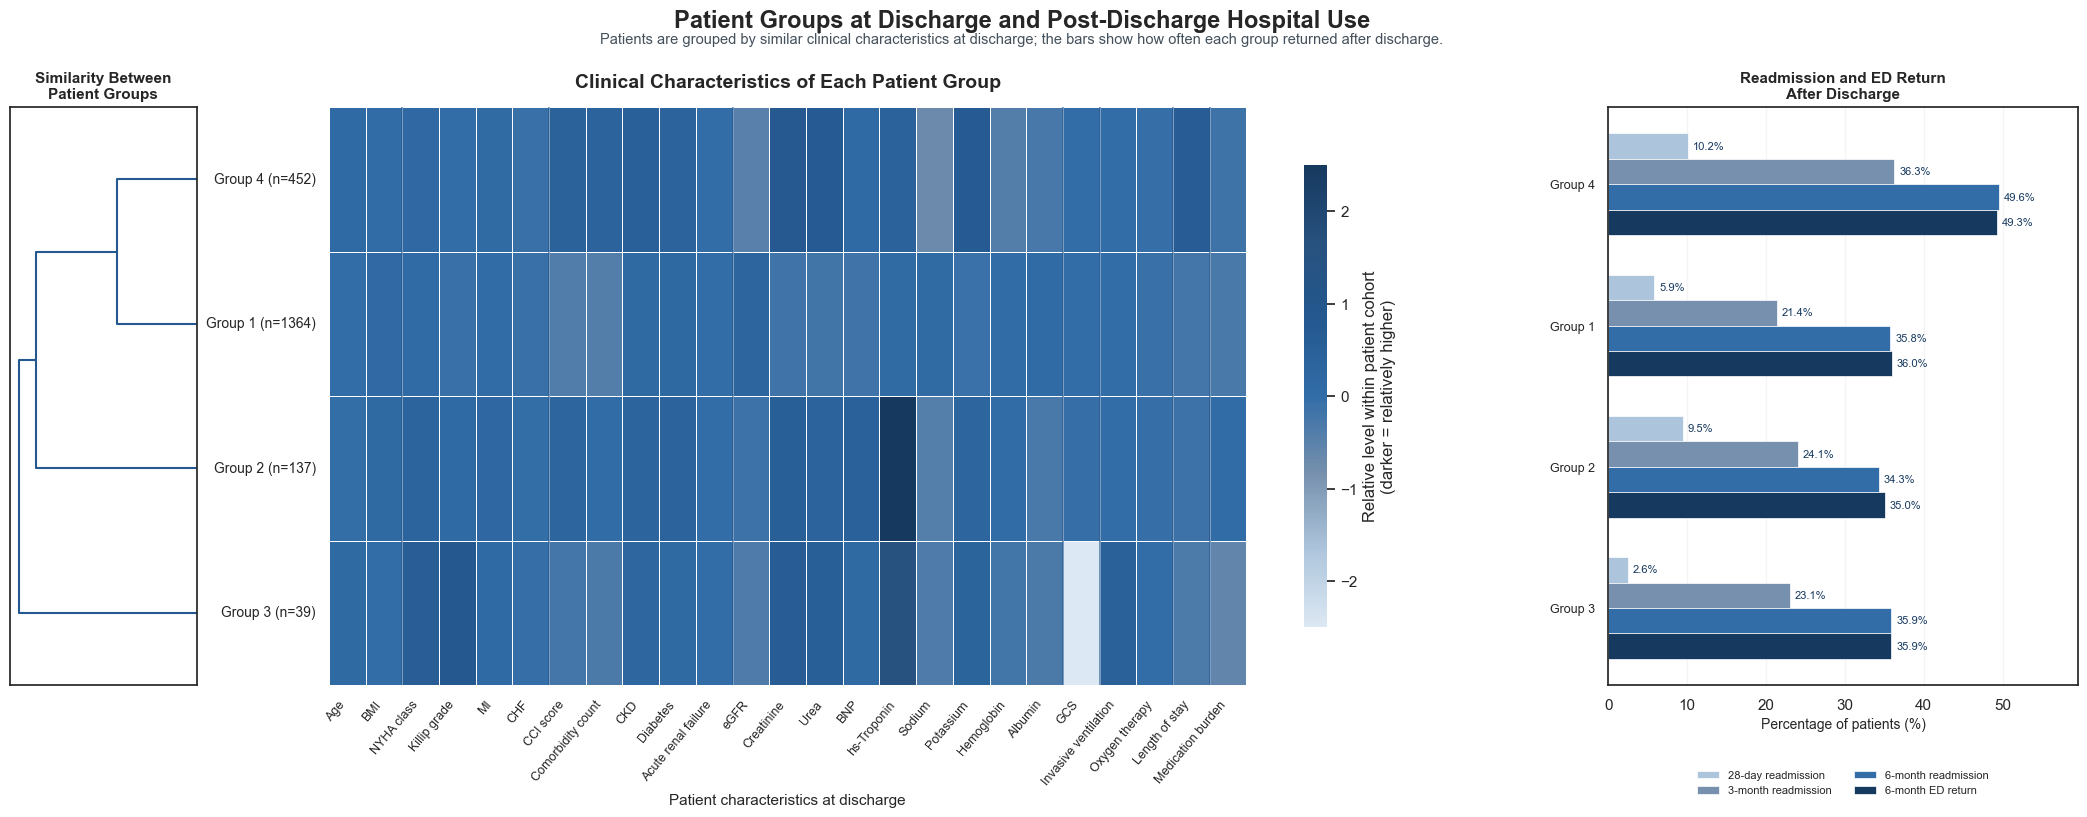

Figure saved as: Patient_Groups_Heatmap_Dendrogram.png


In [21]:

# ============================================================
# 9. CLUSTERED HEATMAP + DENDROGRAM + OUTCOME PANEL
# ============================================================

# Build robust-standardized patient-group profiles.
scaled_df = pd.DataFrame(
    X_scaled,
    columns=FEATURES,
    index=analysis_df.index
)
scaled_df["patient_group"] = analysis_df["patient_group"].values

profile_matrix = (
    scaled_df
    .groupby("patient_group")[FEATURES]
    .mean()
)

# Use group-level clinical profiles to create the dendrogram.
profile_linkage = linkage(
    profile_matrix.values,
    method="ward",
    metric="euclidean"
)

# Get the dendrogram order.
# For a left-oriented dendrogram, scipy returns leaves bottom-to-top,
# so we reverse the order for top-to-bottom display in the heatmap.
dendro_info = dendrogram(
    profile_linkage,
    labels=[f"Group {i}" for i in profile_matrix.index],
    orientation="left",
    no_plot=True
)

bottom_to_top_clusters = [
    int(label.split()[-1]) for label in dendro_info["ivl"]
]
display_clusters = bottom_to_top_clusters[::-1]

# Heatmap data in the same top-to-bottom order as the plotted dendrogram.
profile_plot = profile_matrix.loc[display_clusters].copy()
profile_plot.columns = [DISPLAY_LABELS[c] for c in profile_plot.columns]
profile_plot.index = [
    f"Group {cluster} (n={int(summary.loc[cluster, 'n'])})"
    for cluster in display_clusters
]

# Outcome panel in the same group order.
outcome_plot = (
    summary.loc[
        display_clusters,
        ["readmit_28d", "readmit_3m", "readmit_6m", "ed_6m"]
    ]
    * 100
)

outcome_plot.columns = [
    "28-day readmission",
    "3-month readmission",
    "6-month readmission",
    "6-month ED return"
]

# ------------------------------------------------------------
# COLOR PALETTES
# ------------------------------------------------------------

# Muted clinical blue palette for the heatmap.
clinical_blues = LinearSegmentedColormap.from_list(
    "clinical_blues",
    [
        "#DCE8F3",   # very light muted blue
        "#ADC5DC",   # light steel blue
        "#7690AD",   # soft blue-gray
        "#326DA7",   # medium clinical blue
        "#24588F",   # darker clinical blue
        "#27517E",   # deep slate blue
        "#16395F"    # dark navy
    ]
)

# Matching shades for the outcome bars.
# Lighter to darker shades make the time progression easier to follow.
outcome_colors = [
    "#ADC5DC",   # 28-day readmission
    "#7690AD",   # 3-month readmission
    "#326DA7",   # 6-month readmission
    "#16395F"    # 6-month ED return
]

# ------------------------------------------------------------
# FIGURE LAYOUT
# ------------------------------------------------------------

fig = plt.figure(figsize=(22, 8.5))

gs = fig.add_gridspec(
    nrows=1,
    ncols=3,
    width_ratios=[1.35, 8.3, 3.4],
    wspace=0.22
)

# ------------------------------------------------------------
# LEFT: DENDROGRAM
# ------------------------------------------------------------

ax_d = fig.add_subplot(gs[0, 0])

dendrogram(
    profile_linkage,
    orientation="left",
    no_labels=True,                     # avoids duplicate/overlapping labels
    color_threshold=0,
    above_threshold_color="#24588F",
    ax=ax_d
)

ax_d.set_title(
    "Similarity Between\nPatient Groups",
    fontsize=11,
    weight="bold"
)
ax_d.set_xlabel("")
ax_d.set_ylabel("")
ax_d.tick_params(axis="x", bottom=False, labelbottom=False)
ax_d.tick_params(axis="y", left=False, labelleft=False)

# ------------------------------------------------------------
# MIDDLE: HEATMAP
# ------------------------------------------------------------

ax_h = fig.add_subplot(gs[0, 1])

sns.heatmap(
    profile_plot,
    cmap=clinical_blues,
    center=0,
    vmin=-2.5,
    vmax=2.5,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "label": "Relative level within patient cohort\n(darker = relatively higher)",
        "shrink": 0.80
    },
    ax=ax_h
)

ax_h.set_title(
    "Clinical Characteristics of Each Patient Group",
    fontsize=14,
    weight="bold",
    pad=14
)

ax_h.set_xlabel(
    "Patient characteristics at discharge",
    fontsize=11
)
ax_h.set_ylabel("")

ax_h.tick_params(
    axis="x",
    labelrotation=50,
    labelsize=9
)

# Right-align x-axis labels for easier reading.
for label in ax_h.get_xticklabels():
    label.set_horizontalalignment("right")

ax_h.tick_params(
    axis="y",
    labelrotation=0,
    labelsize=10
)

# Add visual separators between clinical domains.
# Demographics 2 | Cardiac 4 | Comorbidity 5 | Labs 9 |
# Neurologic 1 | Respiratory 2 | Hospital course 1 | Medication 1
domain_breaks = [2, 6, 11, 20, 21, 23, 24]

for x in domain_breaks:
    ax_h.axvline(
        x,
        linewidth=1.2,
        color="#24588F",
        alpha=0.70
    )

# ------------------------------------------------------------
# RIGHT: POST-DISCHARGE OUTCOME PANEL
# ------------------------------------------------------------

ax_o = fig.add_subplot(gs[0, 2])

y = np.arange(len(display_clusters))
bar_height = 0.18

for j, col in enumerate(outcome_plot.columns):
    bars = ax_o.barh(
        y + (j - 1.5) * bar_height,
        outcome_plot[col].values,
        height=bar_height,
        label=col,
        color=outcome_colors[j],
        edgecolor="white",
        linewidth=0.5
    )

    # Add percentage values at the end of each bar.
    for bar in bars:
        width = bar.get_width()
        ax_o.text(
            width + 0.6,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.1f}%",
            va="center",
            fontsize=8,
            color="#16395F"
        )

ax_o.set_yticks(y)

ax_o.set_yticklabels(
    [f"Group {c}" for c in display_clusters],
    fontsize=9
)

# Make Group 1st row appear at the top, matching the heatmap order.
ax_o.invert_yaxis()

ax_o.set_xlabel(
    "Percentage of patients (%)",
    fontsize=10
)

ax_o.set_title(
    "Readmission and ED Return\nAfter Discharge",
    fontsize=11,
    weight="bold"
)

# Leave a little extra room for the percentage labels.
max_outcome = outcome_plot.to_numpy().max()
ax_o.set_xlim(0, min(100, max_outcome + 10))

ax_o.grid(
    axis="x",
    alpha=0.20
)

# Put the legend below the plot so it does not cover any bars.
ax_o.legend(
    fontsize=8,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.13),
    ncol=2,
    frameon=False
)

# ------------------------------------------------------------
# OVERALL TITLE + EXPLANATORY SUBTITLE
# ------------------------------------------------------------

fig.suptitle(
    "Patient Groups at Discharge and Post-Discharge Hospital Use",
    fontsize=17,
    weight="bold",
    y=0.995
)

fig.text(
    0.5,
    0.955,
    "Patients are grouped by similar clinical characteristics at discharge; "
    "the bars show how often each group returned after discharge.",
    ha="center",
    fontsize=10.5,
    color="#44515C"
)

# Manual spacing works better than tight_layout for this multi-panel figure.
fig.subplots_adjust(
    left=0.04,
    right=0.98,
    top=0.88,
    bottom=0.20,
    wspace=0.22
)

OUTPUT_FIGURE = "Patient_Groups_Heatmap_Dendrogram.png"

plt.savefig(
    OUTPUT_FIGURE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved as: {OUTPUT_FIGURE}")


### Actual Insight
The analysis identified four patient groups with distinct clinical characteristics and post-discharge outcomes. Group 4 (452 patients) showed the highest hospital utilization, with 49.6% readmitted and 49.3% returning to the emergency department within six months. This group was characterized by greater comorbidity burden, reduced kidney function, and longer hospital stays. In comparison, Groups 1, 2, and 3 had approximately 34–36% six-month readmission rates. These findings suggest that patients with multiple comorbidities, renal impairment, and prolonged hospitalization may benefit from enhanced discharge planning, medication review, closer clinical monitoring, and earlier post-discharge follow-up.

<p style="font-family: Cambria; font-size: 30px;"><b>Prescriptive Analysis</b></p>

In [1]:
#Importing all the Necessary Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os
import seaborn as sns
from pathlib import Path
import warnings
warnings.simplefilter("ignore", UserWarning)

In [2]:
df = Path( r"C:\Numpy Ninja\Python hackathon sept 2026\cleaned_data")

<p style="font-family: Cambria; font-size: 16px;"><b>Resource Allocation Protocol

<p style="font-family: Cambria; font-size: 16px;"><b>Question 1:</b></p>How should hospitals decide which medical specialists care for each patient based on how bad their heart failure and other health problems are(based on patient NYHA Class and comorbidity burden)?"

<p style="font-family: Cambria; font-size: 16px;"><b>Clinical Reasoning:</b></p>  Allocating specialized multidisciplinary care teams evenly across all heart failure patients wastes high-cost clinical resources. Stratifying assignments based on NYHA functional class and Charlson Comorbidity Index (CCI) optimizes high-touch intervention deployment.

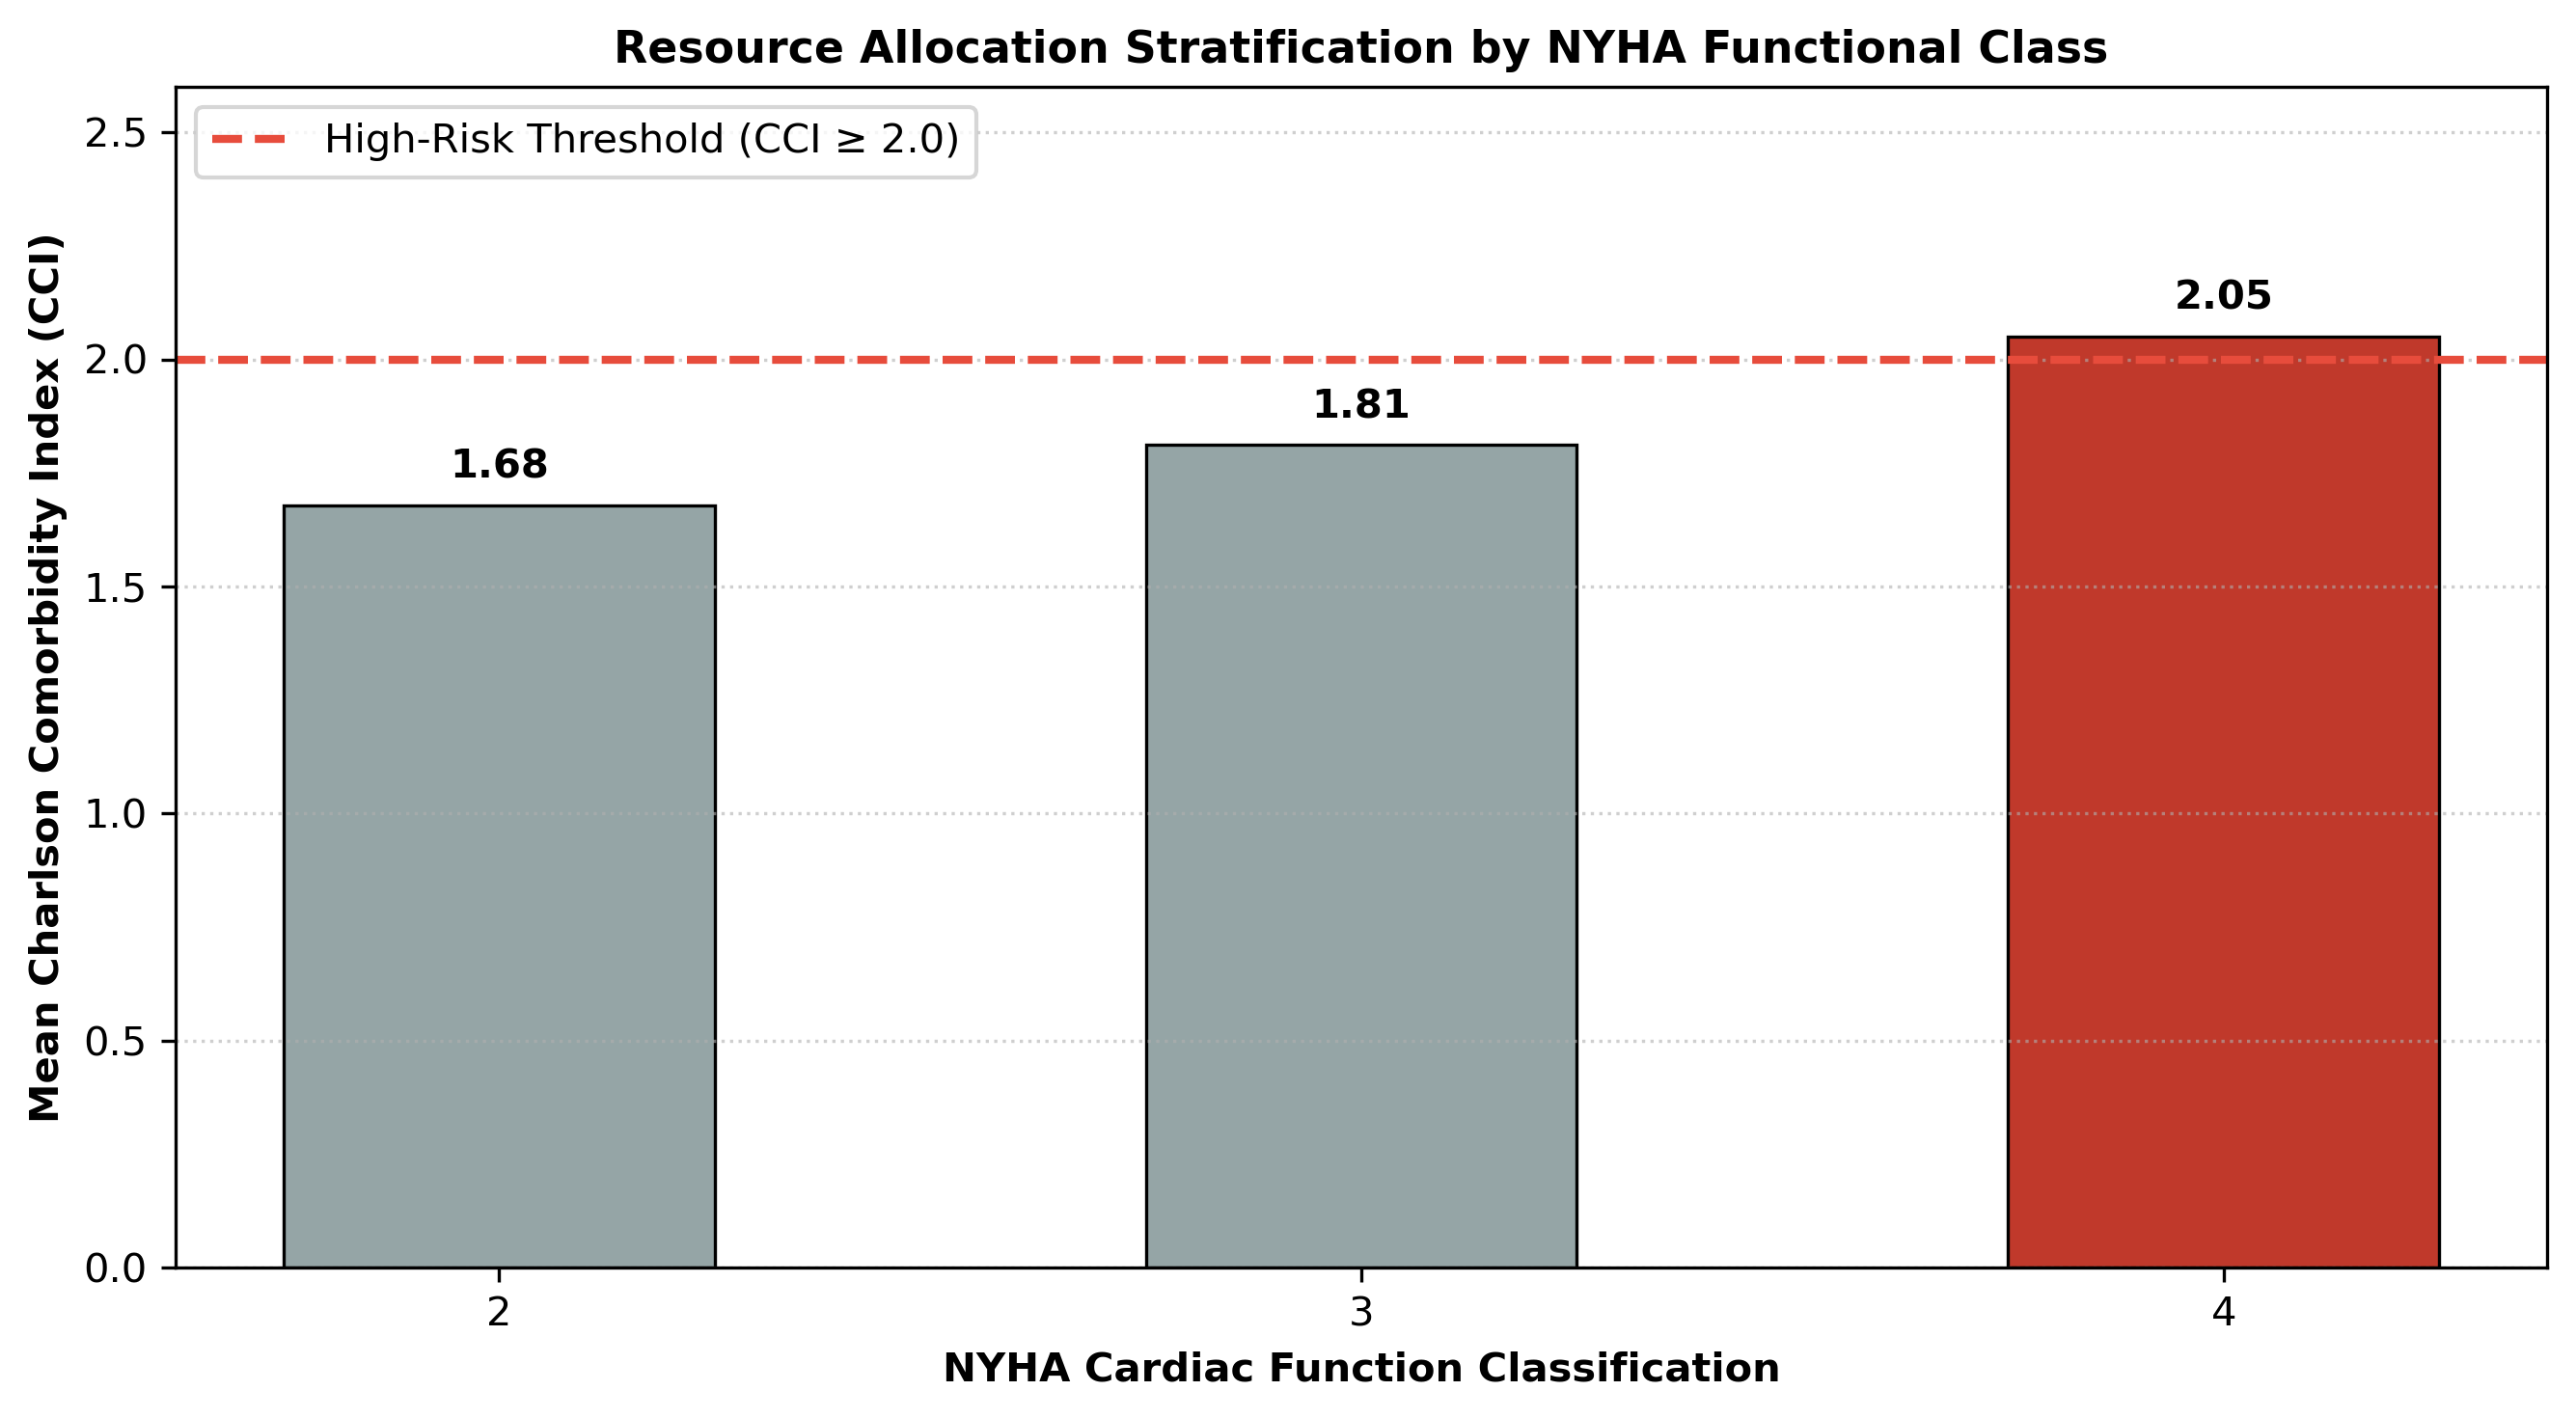

In [12]:
# Calculate mean CCI per NYHA class
q1_data = (
    df.groupby('nyha_cardiac_function_classification')['cci_score']
    .mean()
    .reset_index()
)

plt.figure(figsize=(9, 5), dpi=300)

# Main Bar Plot with Highlight on Class 4
colors = [
    '#95a5a6' if x < 4 else '#c0392b'
    for x in q1_data['nyha_cardiac_function_classification']
]
bars = plt.bar(
    q1_data['nyha_cardiac_function_classification'].astype(str),
    q1_data['cci_score'],
    color=colors,
    width=0.5,
    edgecolor='black',
    linewidth=0.8,
)

# Threshold Line for High Risk Intervention
plt.axhline(
    y=2.0,
    color='#e74c3c',
    linestyle='--',
    linewidth=2,
    label='High-Risk Threshold (CCI ≥ 2.0)',
)

# Text labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        yval + 0.04,
        f'{yval:.2f}',
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=10,
    )

plt.title(
    'Resource Allocation Stratification by NYHA Functional Class',
    fontsize=11,
    fontweight='bold',
)
plt.xlabel('NYHA Cardiac Function Classification', fontweight='bold')
plt.ylabel('Mean Charlson Comorbidity Index (CCI)', fontweight='bold')
plt.ylim(0, 2.6)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Key Insight:</b></p>Patients in NYHA Class 4 present a significantly higher comorbidity burden (mean CCI: 2.05) compared to Class 2 (mean CCI: 1.68).

<p style="font-family: Cambria; font-size: 16px;"><b>Prescriptive Action:</b></p> Automatically assign complex care management and dedicated clinical pharmacist consultations to all NYHA Class 4 patients upon admission.

<p style="font-family: Cambria; font-size: 16px;"><b>Respiratory Support Intervention Thresholds

<p style="font-family: Cambria; font-size: 16px;"><b>Question 2:</b></p>Which patient demographic cohorts require mandatory baseline arterial blood gas (ABG) screening for early non-invasive ventilation (NIV)?

<p style="font-family: Cambria; font-size: 16px;"><b>Clinical Reasoning:</b></p> Type II respiratory failure (hypercapnic failure) requires early non-invasive positive pressure ventilation to prevent ICU admission and intubation.

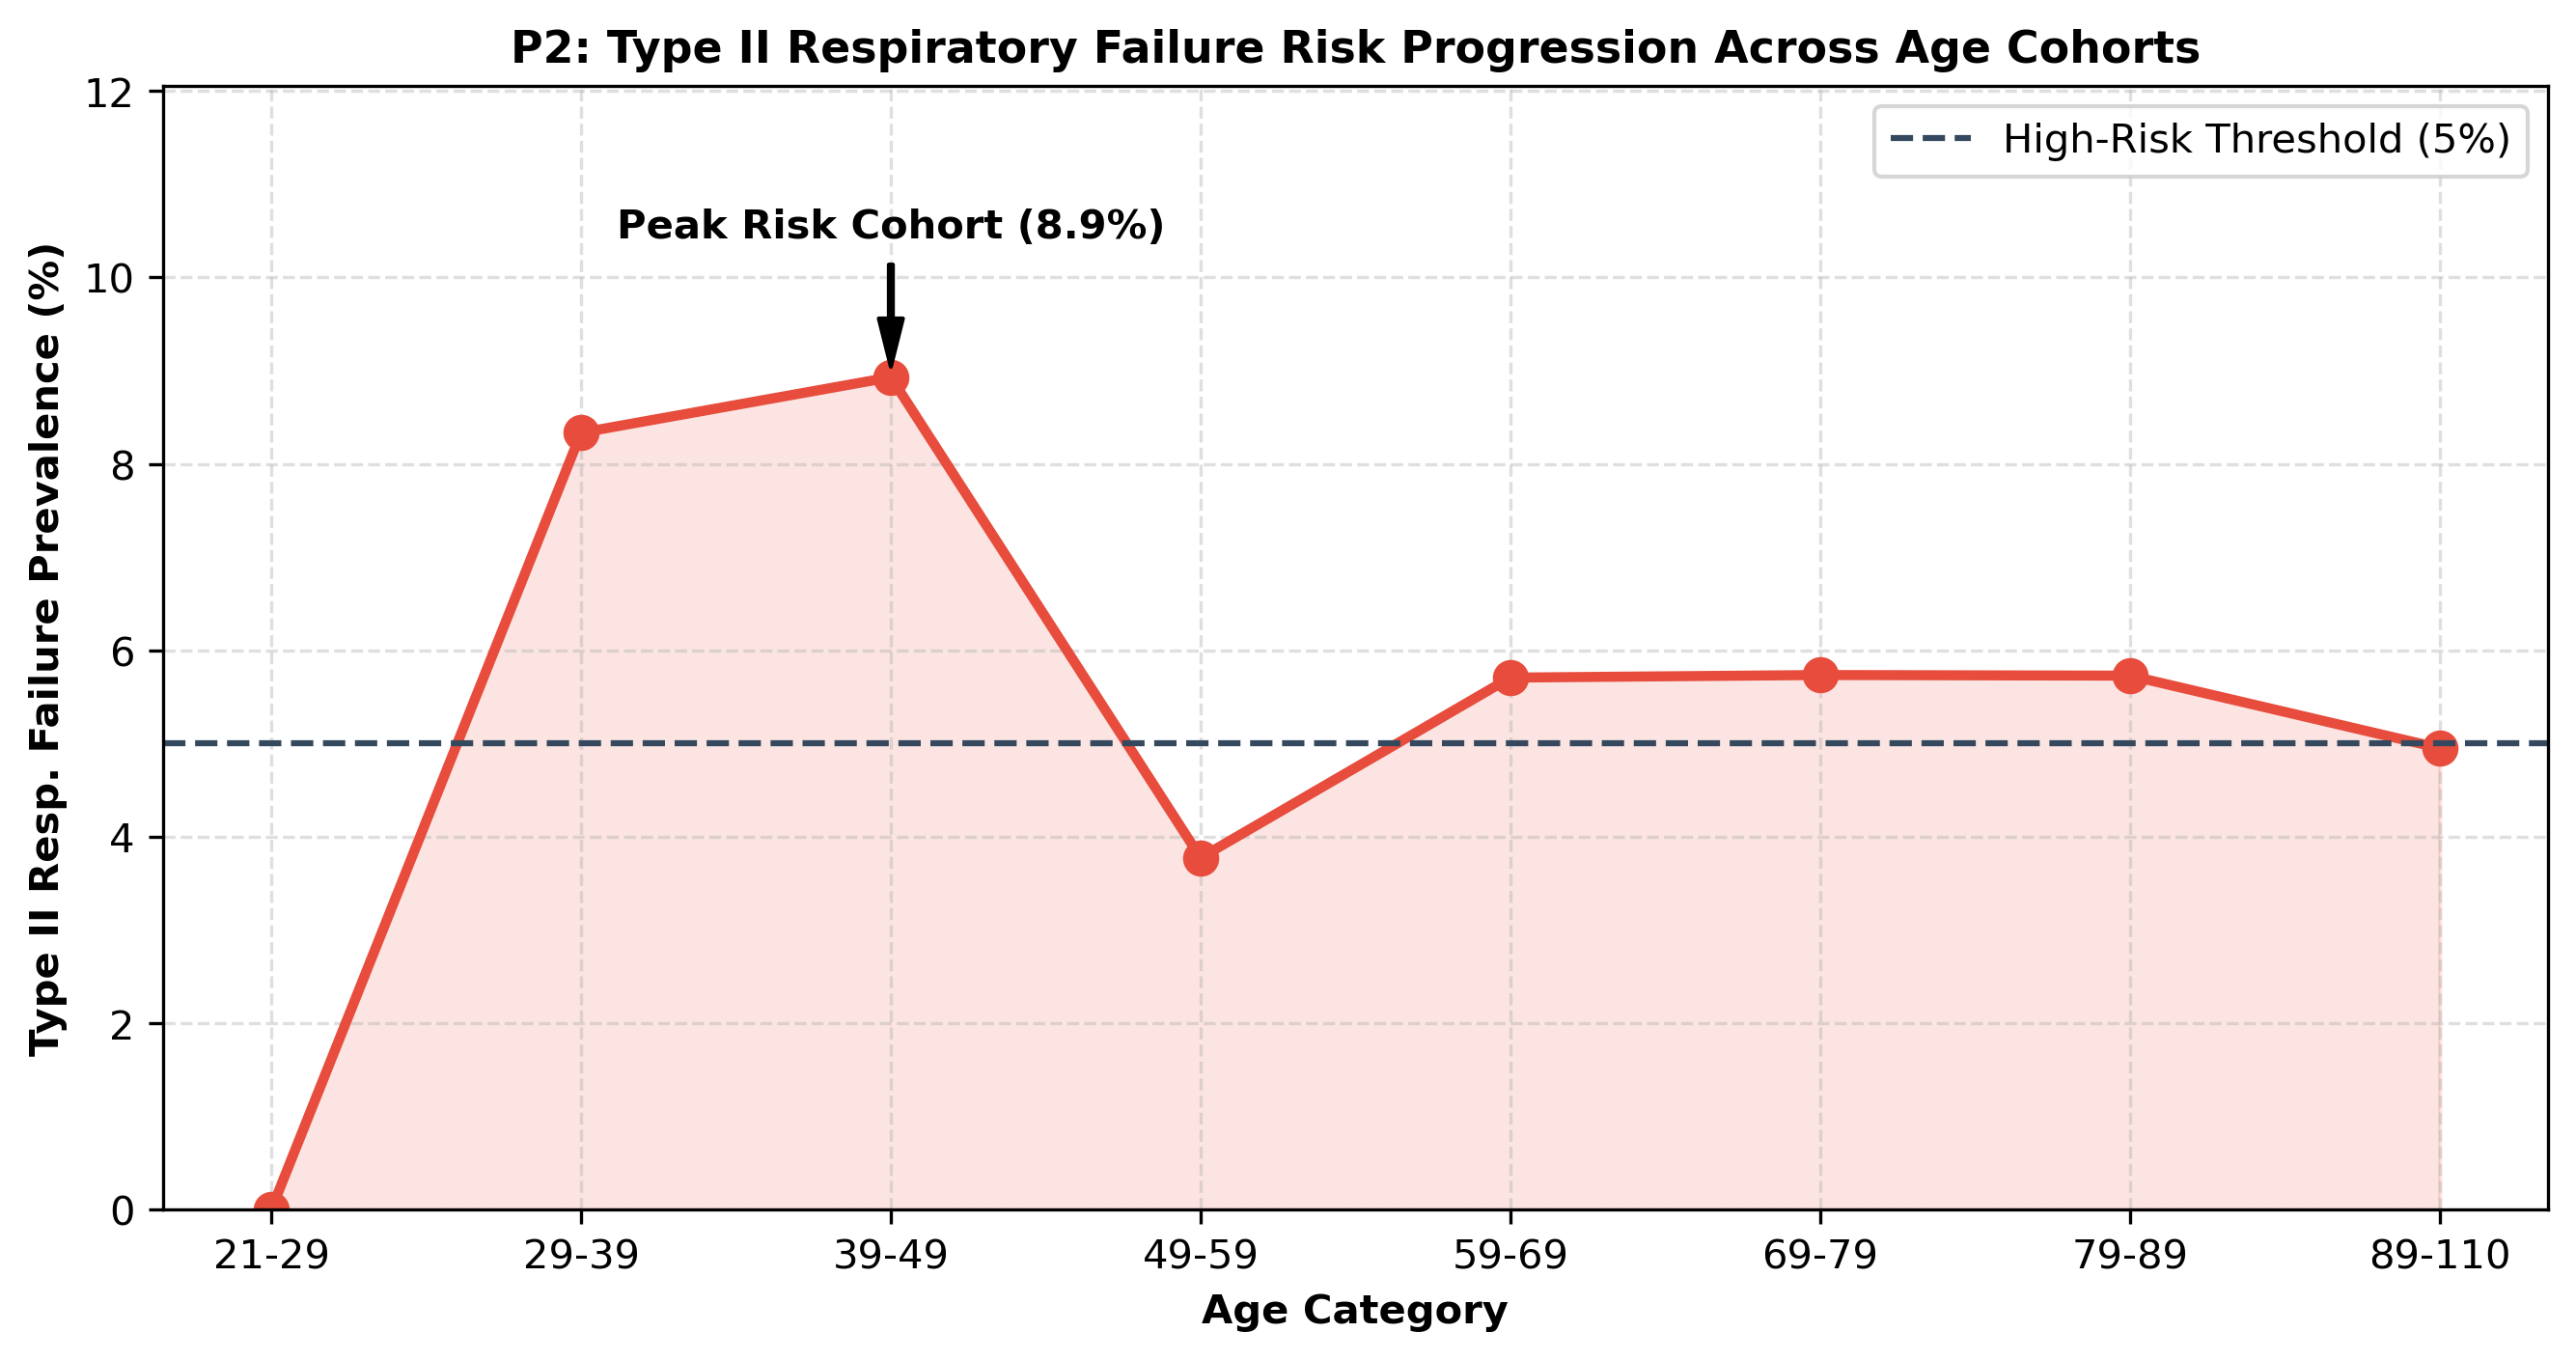

In [14]:
df['typeii_num'] = (df['type_ii_respiratory_failure'] == 'typeii').astype(int)
q2_data = df.groupby('agecat')['typeii_num'].mean() * 100

plt.figure(figsize=(9, 4.8), dpi=300)

# Plot filled area curve
plt.plot(
    q2_data.index,
    q2_data.values,
    color='#e74c3c',
    marker='o',
    linewidth=2.5,
    markersize=8,
)
plt.fill_between(
    q2_data.index, q2_data.values, color='#e74c3c', alpha=0.15
)

# Mandatory Threshold Line
plt.axhline(
    y=5.0,
    color='#34495e',
    linestyle='--',
    linewidth=1.5,
    label='High-Risk Threshold (5%)',
)

# Highlight Peak Risk Cohort
peak_age = q2_data.idxmax()
peak_val = q2_data.max()
plt.annotate(
    f'Peak Risk Cohort ({peak_val:.1f}%)',
    xy=(peak_age, peak_val),
    xytext=(peak_age, peak_val + 1.5),
    arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6),
    fontweight='bold',
    ha='center',
)

plt.title(
    'P2: Type II Respiratory Failure Risk Progression Across Age Cohorts',
    fontsize=11,
    fontweight='bold',
)
plt.xlabel('Age Category', fontweight='bold')
plt.ylabel('Type II Resp. Failure Prevalence (%)', fontweight='bold')
plt.ylim(0, peak_val * 1.35)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Key Insight:</b></p>Patients aged 39–49 exhibit the highest prevalence rate (8.9%) of Type II Respiratory Failure, remaining elevated above 5% across older age brackets.

<p style="font-family: Cambria; font-size: 16px;"><b>Prescriptive Action:</b></p>Establish a mandatory clinical protocol requiring automated ABG testing and pulmonology consultation for all heart failure admissions presenting with dyspnea aged 30+.

<p style="font-family: Cambria; font-size: 16px;"><b>Cardio-Renal Risk Triage System

<p style="font-family: Cambria; font-size: 16px;"><b>Question 3:</b></p>At what age should kidney doctors(nephrologist) automatically start helping take care of heart patients in the hospital?"

<p style="font-family: Cambria; font-size: 16px;"><b>Clinical Reasoning:</b></p> Acute kidney injury and chronic kidney disease (CKD) severely limit heart failure medication options (e.g., ACEi, ARB, aldosterone antagonists).

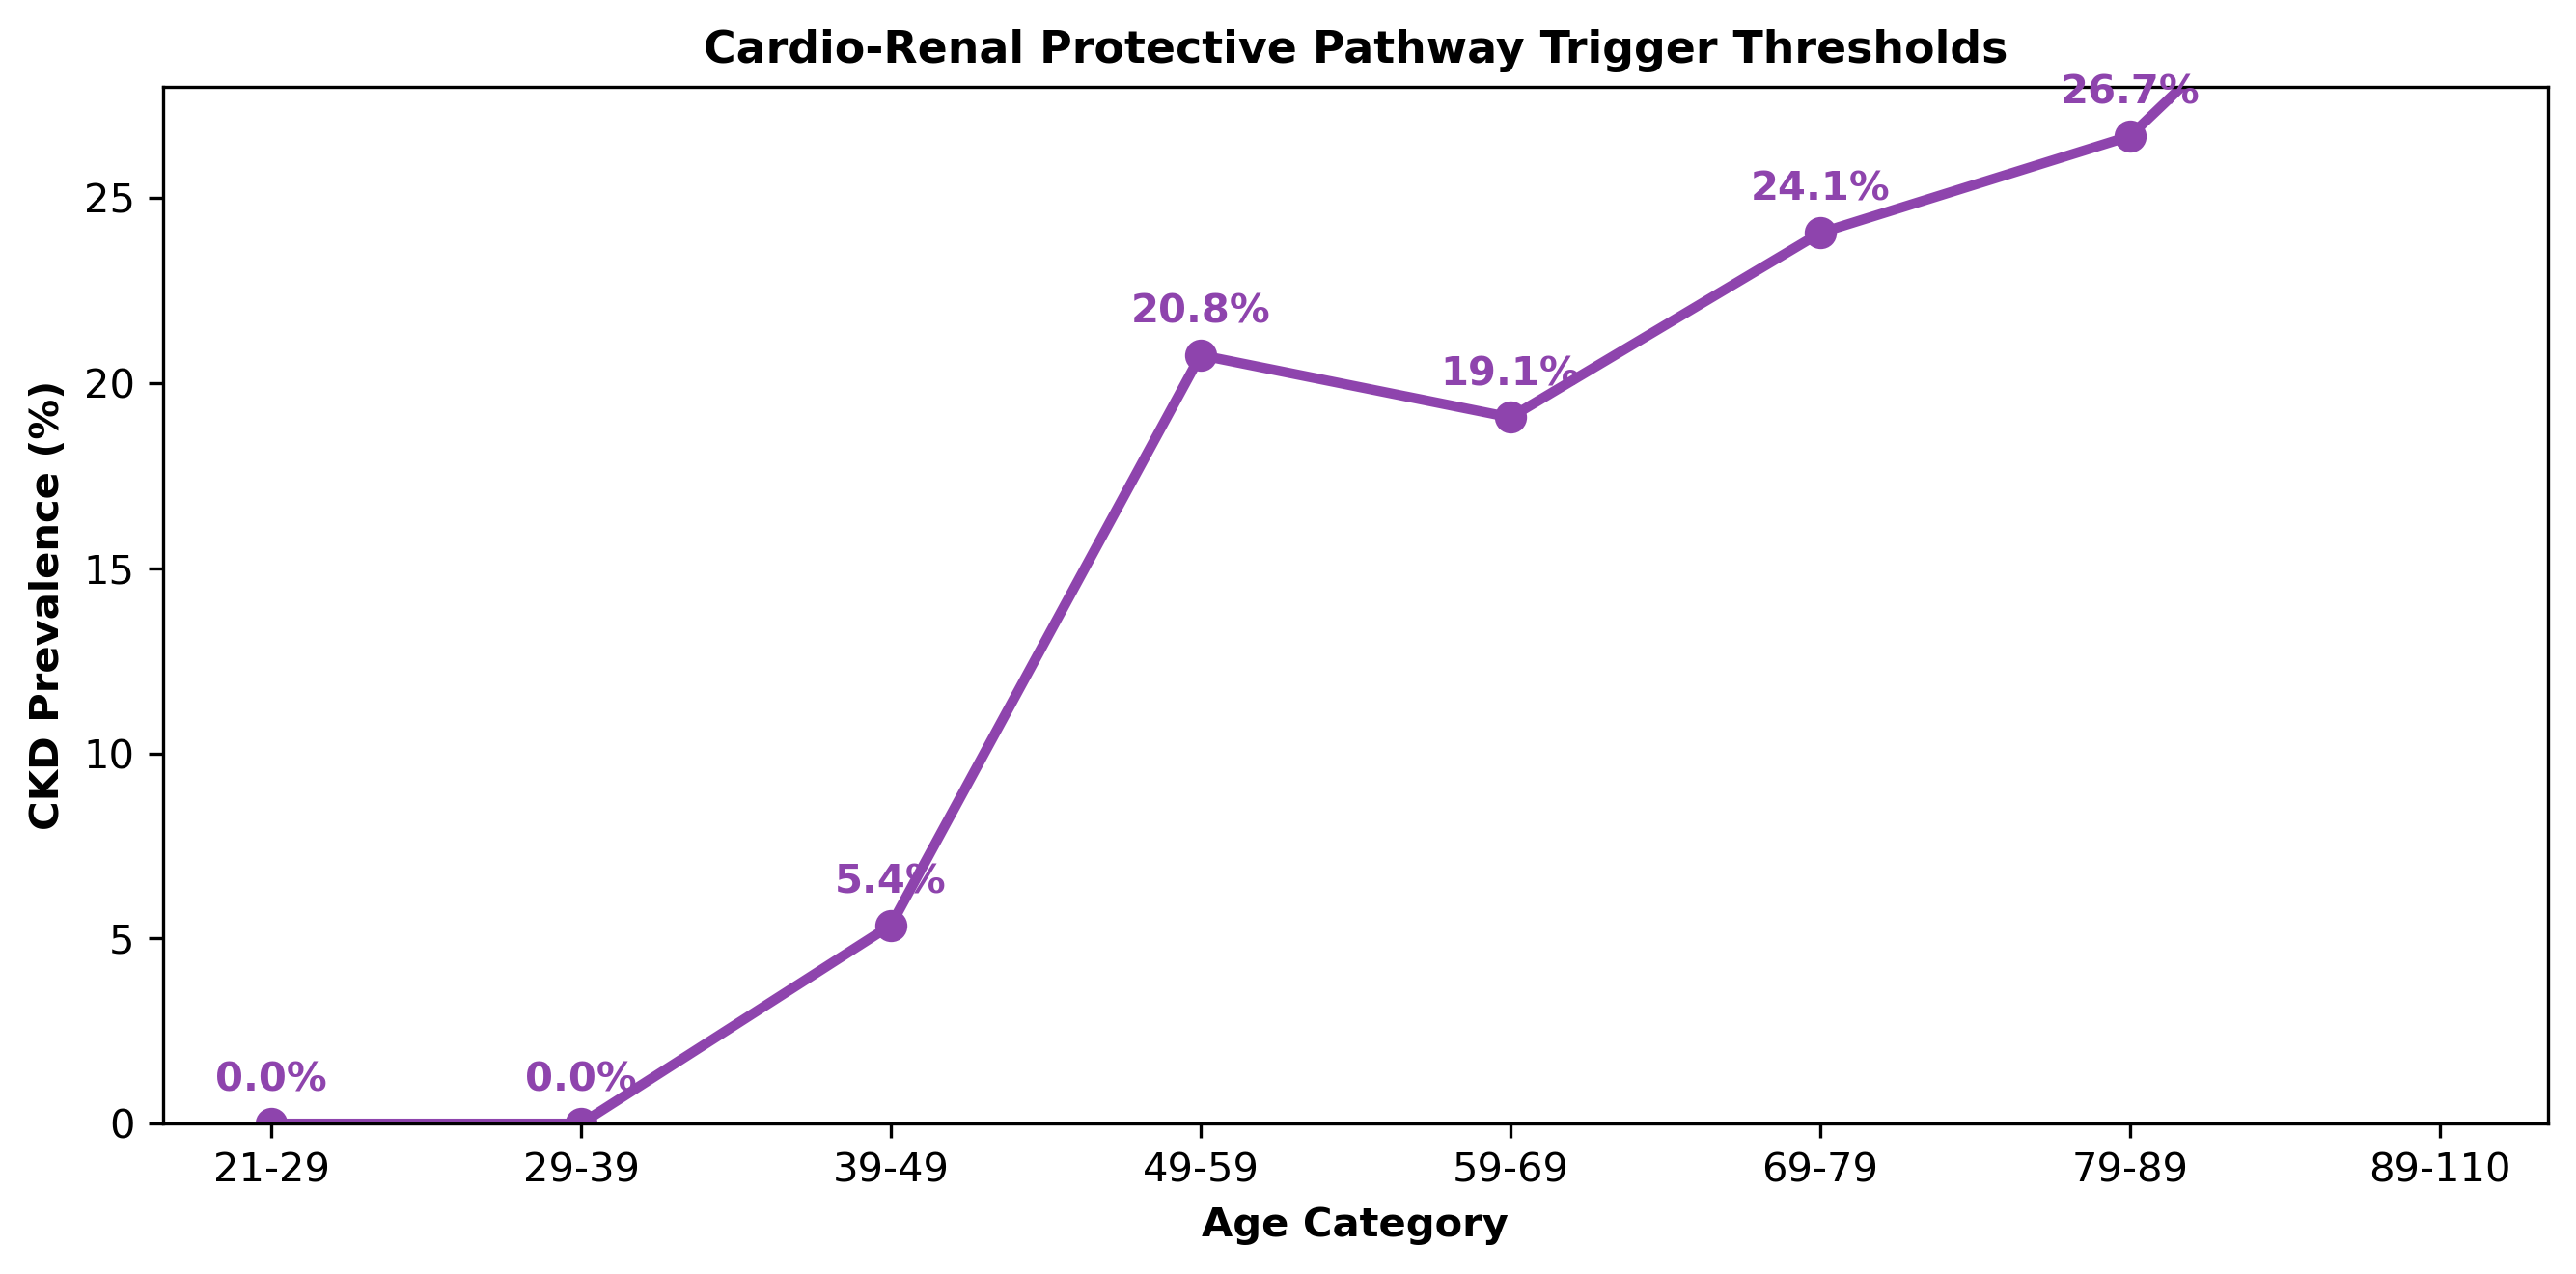

In [6]:
# Prescriptive Action Code - Q4
q4_data = (
    df.groupby('agecat')['moderate_to_severe_chronic_kidney_disease'].mean()
    * 100
)

plt.figure(figsize=(9, 4.5), dpi=300)
plt.plot(
    q4_data.index,
    q4_data.values,
    marker='o',
    linewidth=2.5,
    color='#8e44ad',
    markersize=7,
)
plt.title(
    'Cardio-Renal Protective Pathway Trigger Thresholds',
    fontsize=11,
    fontweight='bold',
)
plt.xlabel('Age Category', fontweight='bold')
plt.ylabel('CKD Prevalence (%)', fontweight='bold')
plt.ylim(0, 28)
for idx, val in zip(q4_data.index, q4_data.values):
  plt.annotate(
      f'{val:.1f}%',
      (idx, val),
      textcoords='offset points',
      xytext=(0, 8),
      ha='center',
      fontweight='bold',
      color='#8e44ad',
  )
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Key Insight:</b></p>CKD rates jump from 5.4% in patients aged 39–49 to 20.8% in the 49–59 age bracket, peaking at 24.1% in patients aged 69–79.

<p style="font-family: Cambria; font-size: 16px;"><b>Prescriptive Action:</b></p>Implement automated clinical decision alerts for cardio-renal protocol initiation and baseline serum creatinine monitoring for all cardiac admissions aged 50 and above.

<p style="font-family: Cambria; font-size: 16px;"><b>Acute Hemodynamic Deterioration Escalation Matrix

<p style="font-family: Cambria; font-size: 16px;"><b>Question 4:</b></p>How should a hospital adjust nursing care and monitoring levels for heart patients based on their short-term severity (Killip Grade) and long-term symptom level (NYHA Class)? 

<p style="font-family: Cambria; font-size: 16px;"><b>Clinical Reasoning:</b></p>Misinterpreting functional severity (NYHA) as acute hemodynamic stability (Killip Grade) can lead to unexpected ICU transfers.

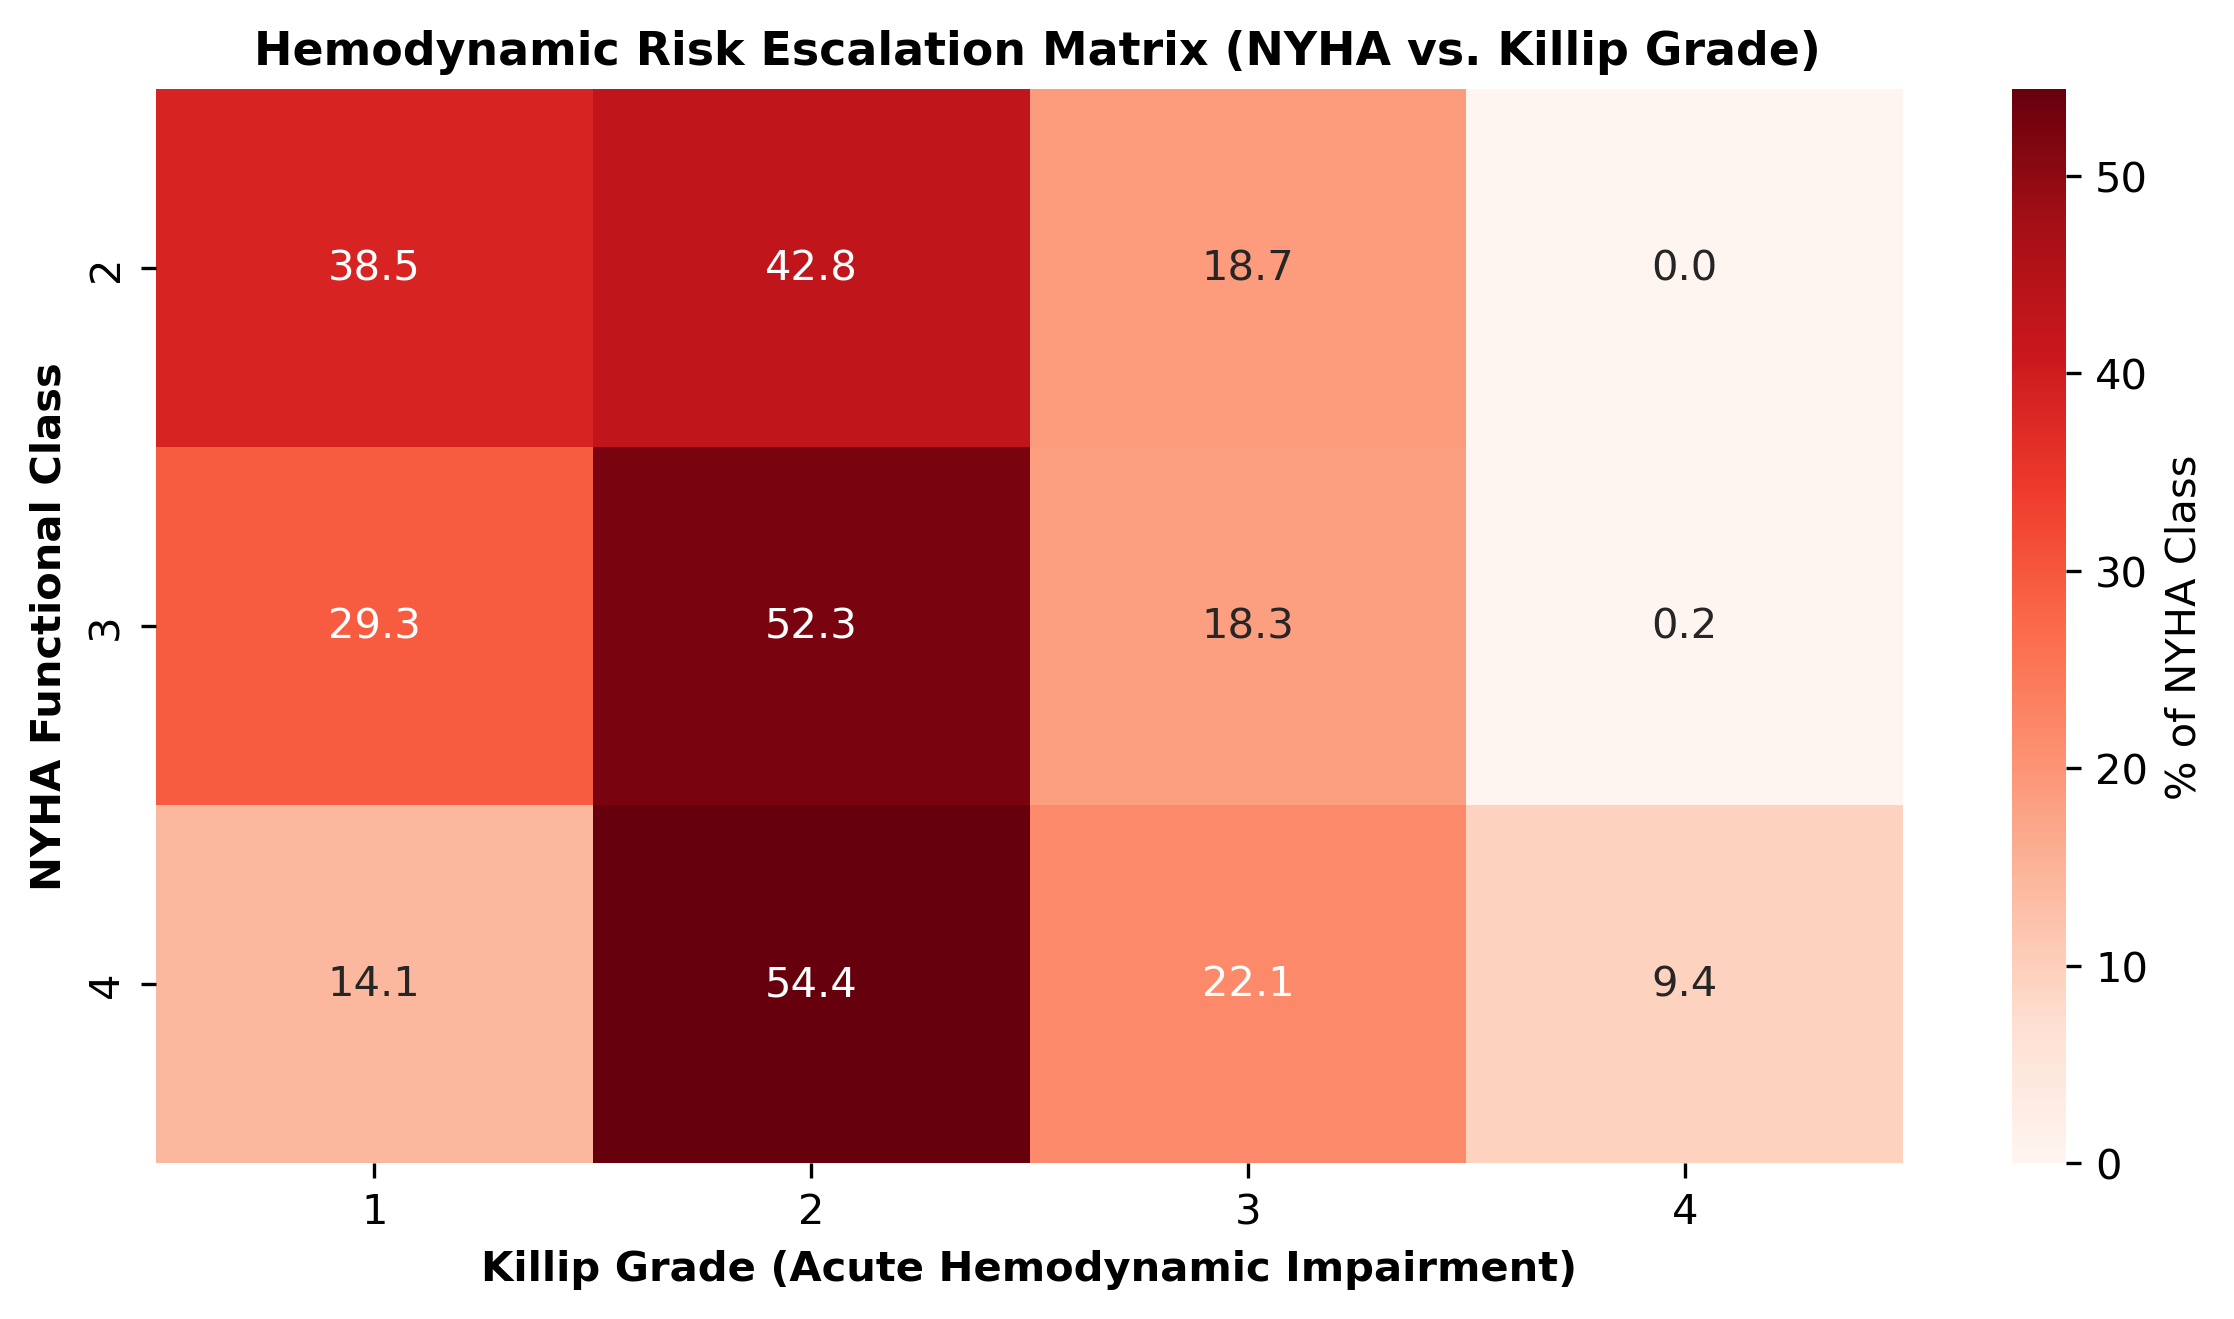

In [7]:
# Prescriptive Action Code - Q5
import seaborn as sns

ct = (
    pd.crosstab(
        df['nyha_cardiac_function_classification'],
        df['killip_grade'],
        normalize='index',
    )
    * 100
)

plt.figure(figsize=(8, 4.5), dpi=300)
sns.heatmap(
    ct,
    annot=True,
    fmt='.1f',
    cmap='Reds',
    cbar_kws={'label': '% of NYHA Class'},
)
plt.title(
    ' Hemodynamic Risk Escalation Matrix (NYHA vs. Killip Grade)',
    fontsize=11,
    fontweight='bold',
)
plt.xlabel('Killip Grade (Acute Hemodynamic Impairment)', fontweight='bold')
plt.ylabel('NYHA Functional Class', fontweight='bold')
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Key Insight:</b></p>9.4% of NYHA Class 4 patients are in Killip Grade 4 (cardiogenic shock), requiring immediate intensive care monitoring.

<p style="font-family: Cambria; font-size: 16px;"><b>Prescriptive Action:</b></p>Enforce direct ICU/CCU placement rules for any patient with Killip Grade $\ge$ 3, regardless of whether their chronic NYHA class was low.

<p style="font-family: Cambria; font-size: 16px;"><b>Post-Discharge Readmission Prevention Triad Tracking

<p style="font-family: Cambria; font-size: 16px;"><b>Question 5:</b></p>Which combination of health conditions places a heart failure patient at highest risk, requiring a nurse home visit within 48 hours of leaving the hospital?"

<p style="font-family: Cambria; font-size: 16px;"><b>Clinical Reasoning:</b></p>Readmissions are often driven by co-occurring systemic diseases rather than primary cardiac conditions alone.

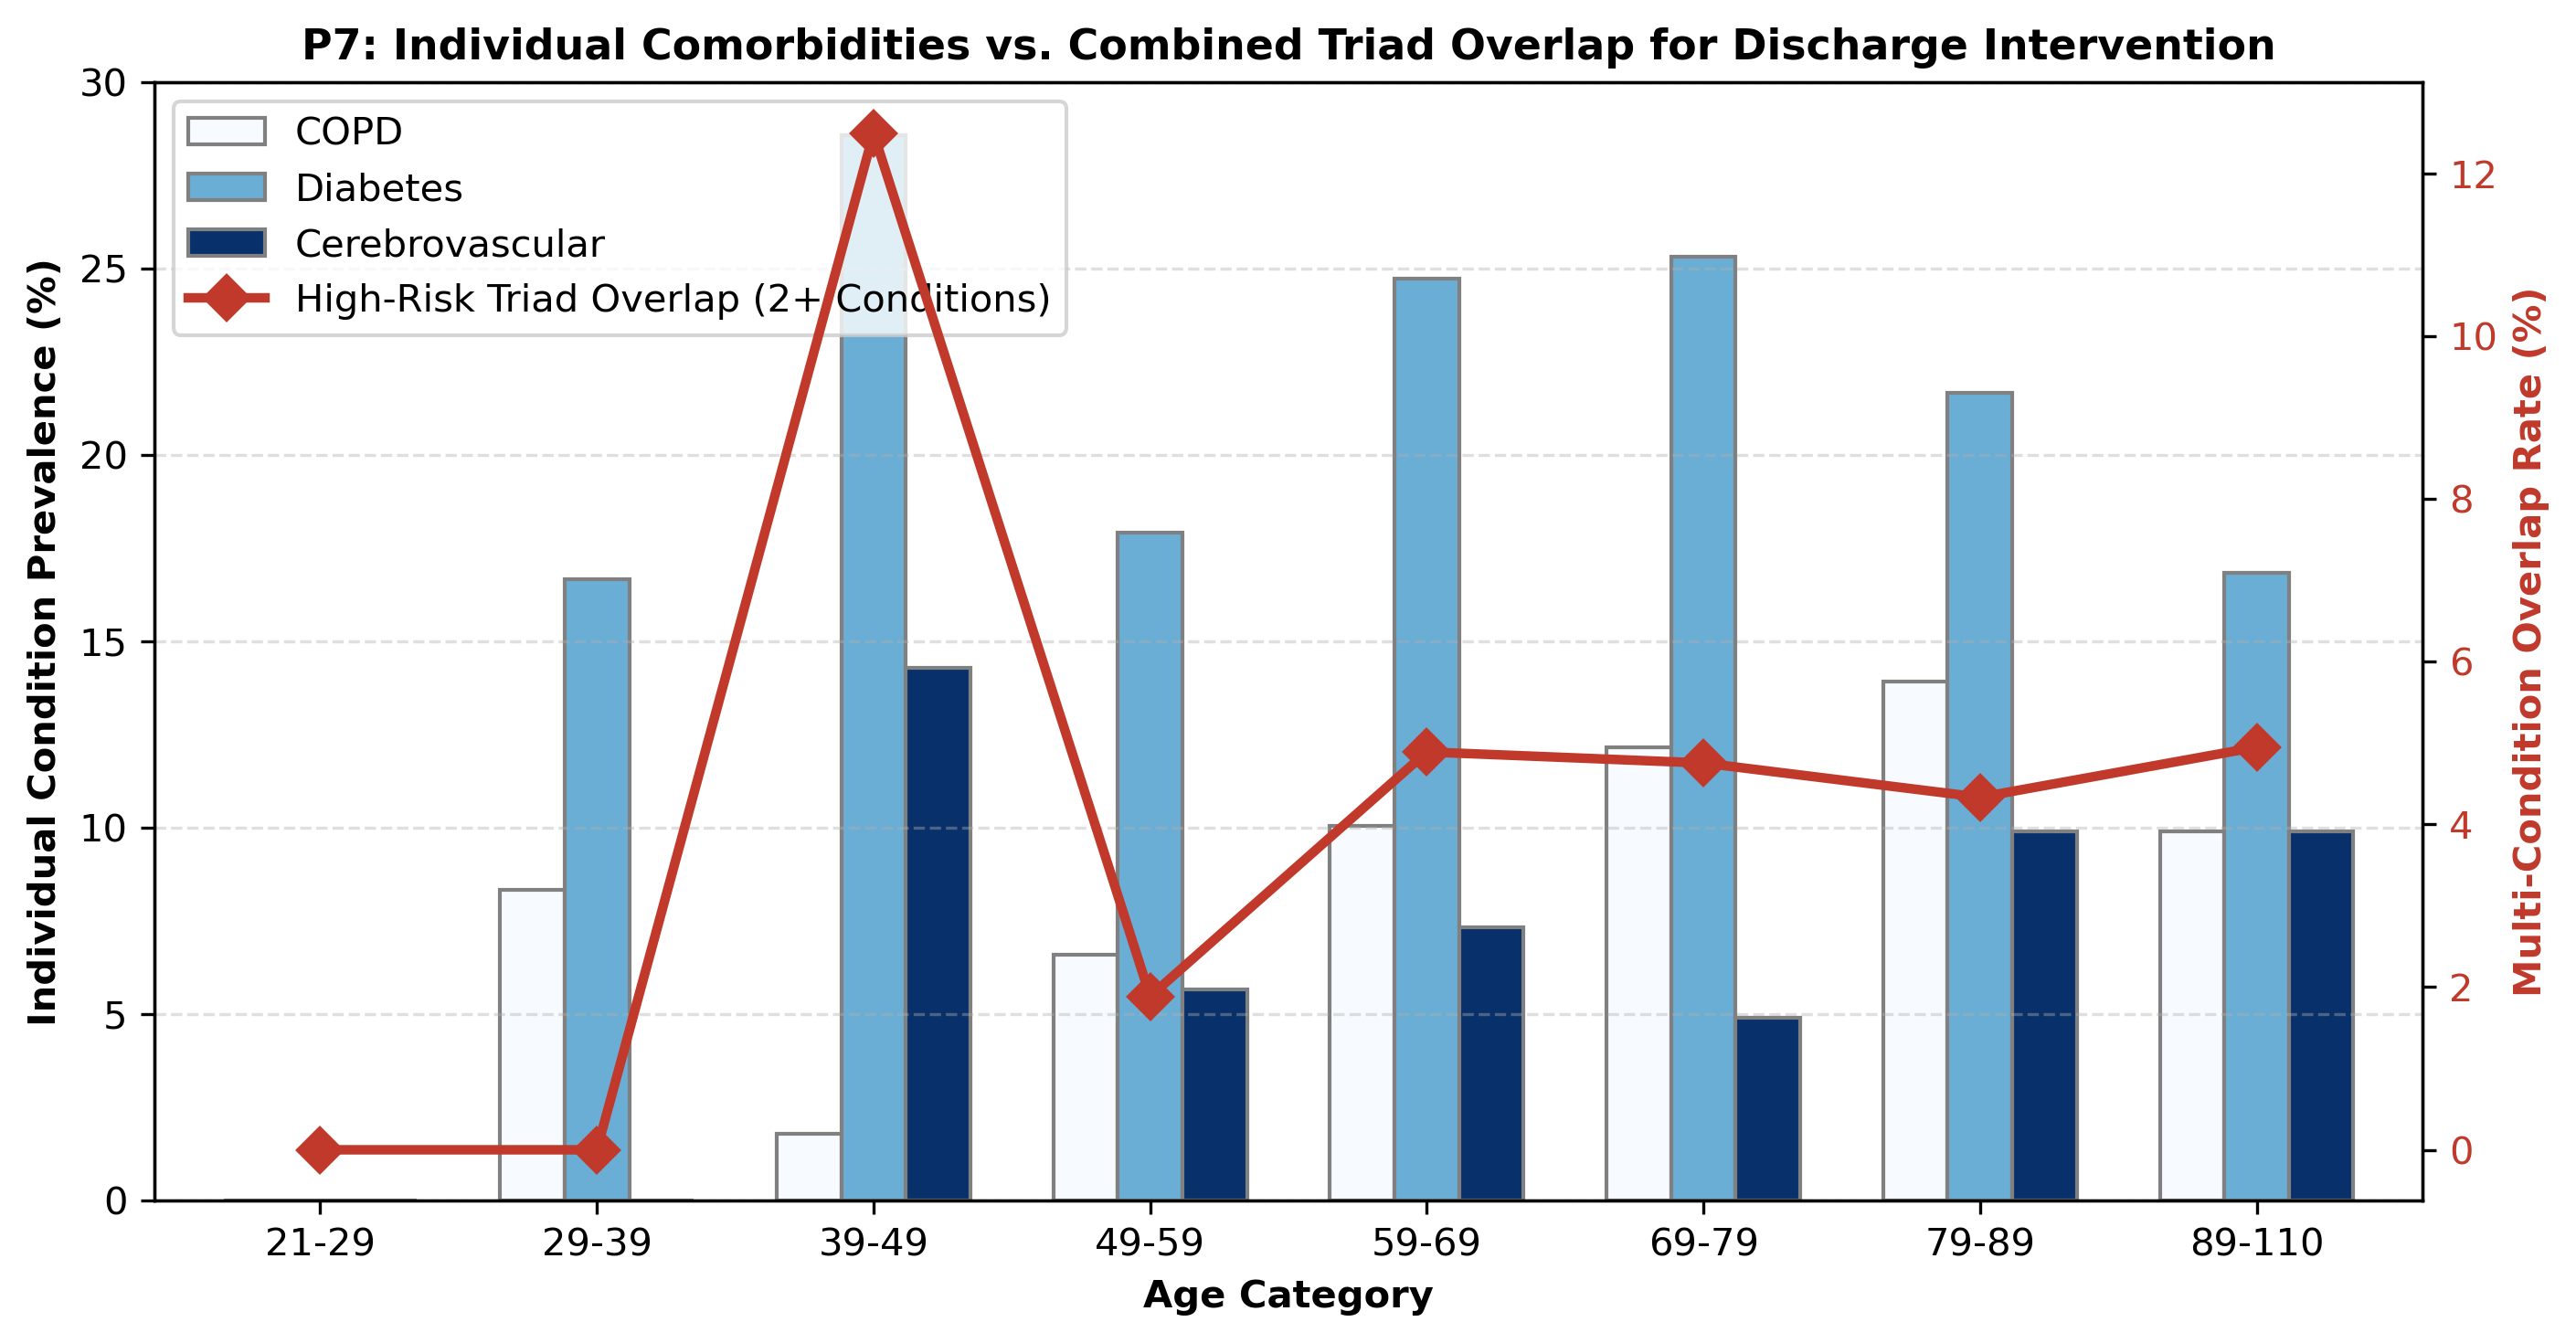

In [16]:
# Calculate individual rates
q7_data = (
    df.groupby('agecat')[
        [
            'chronic_obstructive_pulmonary_disease',
            'diabetes',
            'cerebrovascular_disease',
        ]
    ].mean()
    * 100
)
q7_data.columns = ['COPD', 'Diabetes', 'Cerebrovascular']

# Calculate combined high-risk score (count of active conditions per patient)
df['triad_count'] = (
    df['chronic_obstructive_pulmonary_disease']
    + df['diabetes']
    + df['cerebrovascular_disease']
)
triad_overlap = df.groupby('agecat')['triad_count'].apply(
    lambda x: (x >= 2).mean() * 100
)

fig, ax1 = plt.subplots(figsize=(9.5, 5), dpi=300)

# Primary Axis: Bars for individual conditions
q7_data.plot(kind='bar', ax=ax1, width=0.7, colormap='Blues', edgecolor='gray')
ax1.set_ylabel('Individual Condition Prevalence (%)', fontweight='bold')
ax1.set_xlabel('Age Category', fontweight='bold')
ax1.set_xticklabels(q7_data.index, rotation=0)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# Secondary Axis: High-risk overlap line
ax2 = ax1.twinx()
ax2.plot(
    triad_overlap.index,
    triad_overlap.values,
    color='#c0392b',
    marker='D',
    linewidth=2.5,
    markersize=8,
    label='High-Risk Triad Overlap (2+ Conditions)',
)
ax2.set_ylabel(
    'Multi-Condition Overlap Rate (%)', fontweight='bold', color='#c0392b'
)
ax2.tick_params(axis='y', labelcolor='#c0392b')

plt.title(
    'P7: Individual Comorbidities vs. Combined Triad Overlap for Discharge Intervention',
    fontsize=11,
    fontweight='bold',
)

# Combined Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Key Insight:</b></p>Diabetes peaks at 28.6% in middle-aged cohorts (39–49), while COPD steadily increases with age, reaching 13.9% in patients aged 79–89.

<p style="font-family: Cambria; font-size: 16px;"><b>Prescriptive Action:</b></p>Trigger mandatory post-discharge home health visits within 48 hours for any patient presenting with the "Triad Risk" (Heart Failure + Diabetes + COPD).

<p style="font-family: Cambria; font-size: 16px;"><b>Gender-Specific Clinical Management Guidelines

<p style="font-family: Cambria; font-size: 16px;"><b>Question 6:</b></p>How should treatment plans for left, right, or double-sided heart failure be tailored for male versus female patients?

<p style="font-family: Cambria; font-size: 16px;"><b>Clinical Reasoning:</b></p>Biological sex differences influence heart failure presentation, vascular compliance, and response to cardiac therapeutics.

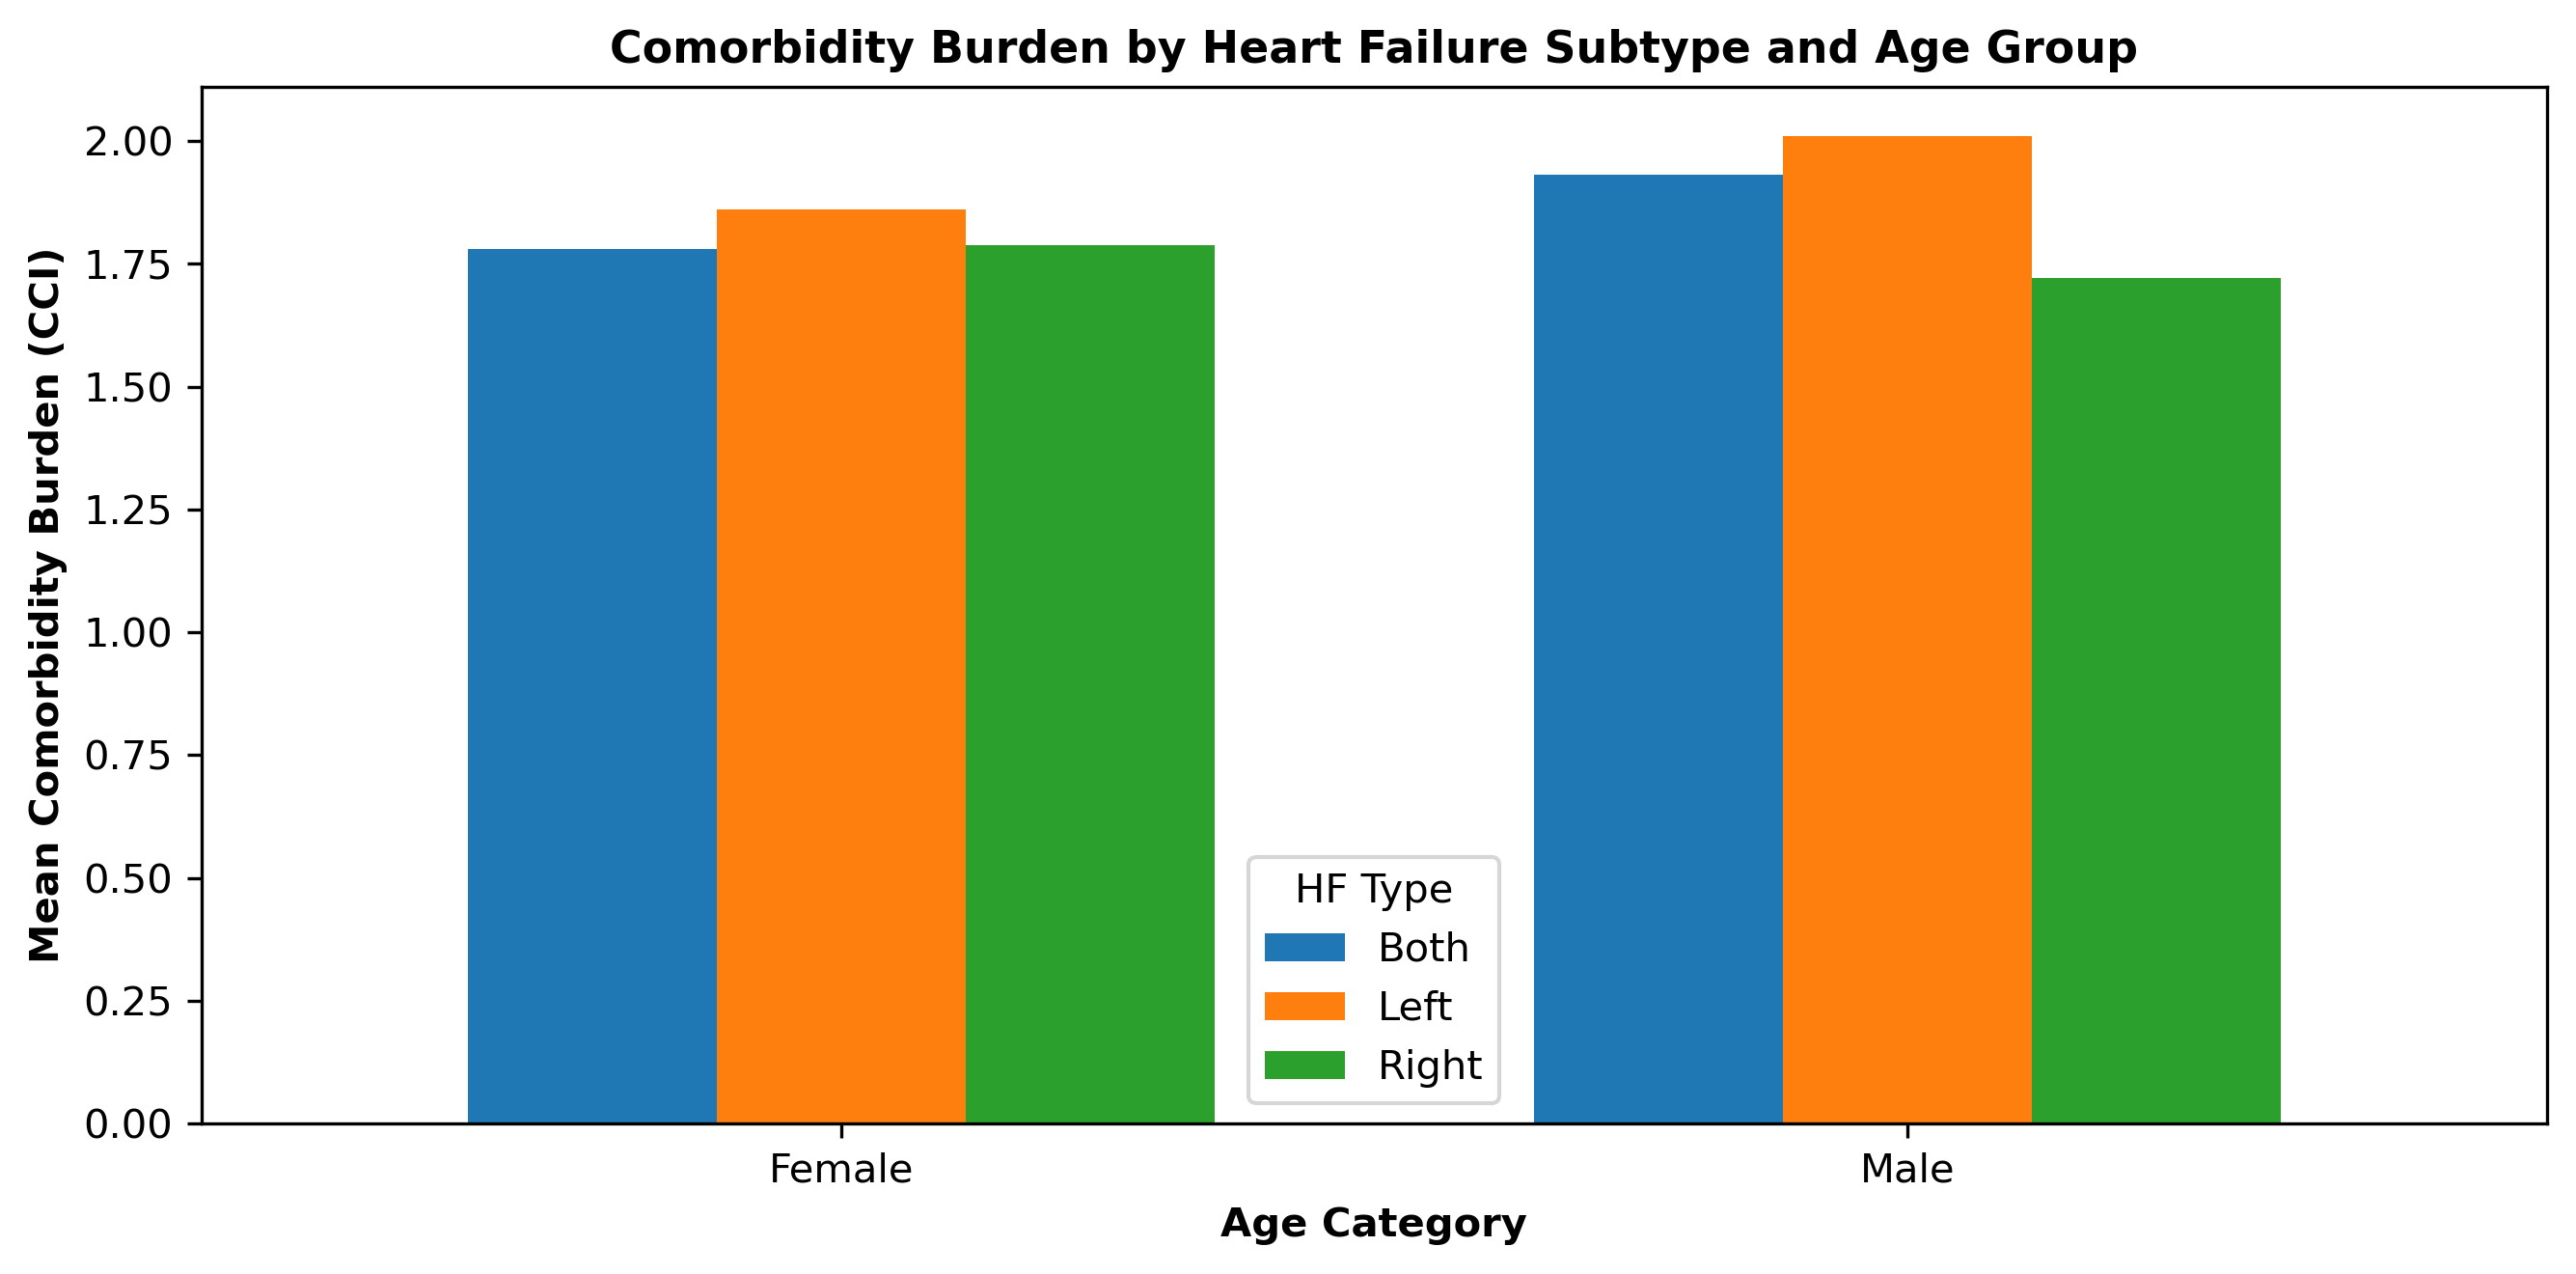

In [10]:
q8_data = (
    df.groupby(['gender', 'type_of_heart_failure'])['cci_score']
    .mean()
    .unstack()
)

# 1. Create figure and set DPI here
plt.figure(figsize=(9, 4.5), dpi=300)

# 2. Plot without passing dpi inside .plot()
ax = q8_data.plot(kind='bar', width=0.7, ax=plt.gca())

plt.title(
    'Comorbidity Burden by Heart Failure Subtype and Age Group',
    fontsize=11,
    fontweight='bold',
)
plt.xlabel('Age Category', fontweight='bold')
plt.ylabel('Mean Comorbidity Burden (CCI)', fontweight='bold')
plt.xticks(rotation=0)
plt.legend(title='HF Type')
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Key Insight:</b></p>Male patients presenting with Left Heart Failure exhibit the highest overall comorbidity burden (2.01 CCI), whereas female comorbidity burden is highest in Left Heart Failure as well (1.86 CCI), but with lower overall variation across failure types.

<p style="font-family: Cambria; font-size: 16px;"><b>Prescriptive Action:</b></p>Mandate comprehensive multi-organ subspecialty screening specifically for male patients admitted with isolated Left Heart Failure.

# Category 2: Prescriptive Analysis


In [2]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import os


In [4]:
import os

print(os.getcwd())

C:\Users\haris


In [5]:
import os

folder = r"C:\Users\haris\OneDrive\Desktop\SUGANYA\DA215\Python\Python_Hackathon_Sep_2026\cardiac_failure"

os.chdir(folder)

print(os.getcwd())

C:\Users\haris\OneDrive\Desktop\SUGANYA\DA215\Python\Python_Hackathon_Sep_2026\cardiac_failure


In [6]:
for file in os.listdir():
    if file.lower().endswith('.csv'):
        print(file)

cardiac_complications.csv
demography.csv
hospitalization_discharge.csv
labs.csv
patienthistory.csv
patienthistory_cleaned.csv
patient_precriptions.csv
responsivenes.csv
Team7_CodeAvengers_Category1_DataCleaning_cardiac_complications.csv
Team7_CodeAvengers_Category1_DataCleaning_demography.csv
Team7_CodeAvengers_Category1_DataCleaning_labs.csv
Team7_CodeAvengers_Category1_DataCleaning_patienthistory_cleaned.csv
Team7_CodeAvengers_Category1_DataCleaning_patient_precriptions.csv
Team7_CodeAvengers_Category1_DataCleaning_responsivenes.csv


In [7]:
# Patient History
df = pd.read_csv(
    "Team7_CodeAvengers_Category1_DataCleaning_patienthistory_cleaned.csv"
)

# Cardiac Complications
cardiac = pd.read_csv(
    "Team7_CodeAvengers_Category1_DataCleaning_cardiac_complications.csv"
)

# Demography
demography = pd.read_csv(
    "Team7_CodeAvengers_Category1_DataCleaning_demography.csv"
)

# Laboratory
labs = pd.read_csv(
    "Team7_CodeAvengers_Category1_DataCleaning_labs.csv"
)

# Patient Prescriptions
prescriptions = pd.read_csv(
    "Team7_CodeAvengers_Category1_DataCleaning_patient_precriptions.csv"
)

# Responsiveness
responsiveness = pd.read_csv(
    "Team7_CodeAvengers_Category1_DataCleaning_responsivenes.csv"
)

In [30]:
print(df.shape)
print(cardiac.shape)
print(demography.shape)
print(labs.shape)
print(responsiveness.shape)

(2008, 18)
(2008, 14)
(2008, 7)
(2008, 107)
(2008, 6)


### Question 1: Which patients have a high comorbidity burden?
 Reasoning: Patients with multiple recorded comorbidities may represent a more complex clinical population. Identifying patients with higher CCI scores and multiple coexisting conditions can help define groups that may benefit from additional review or monitoring.

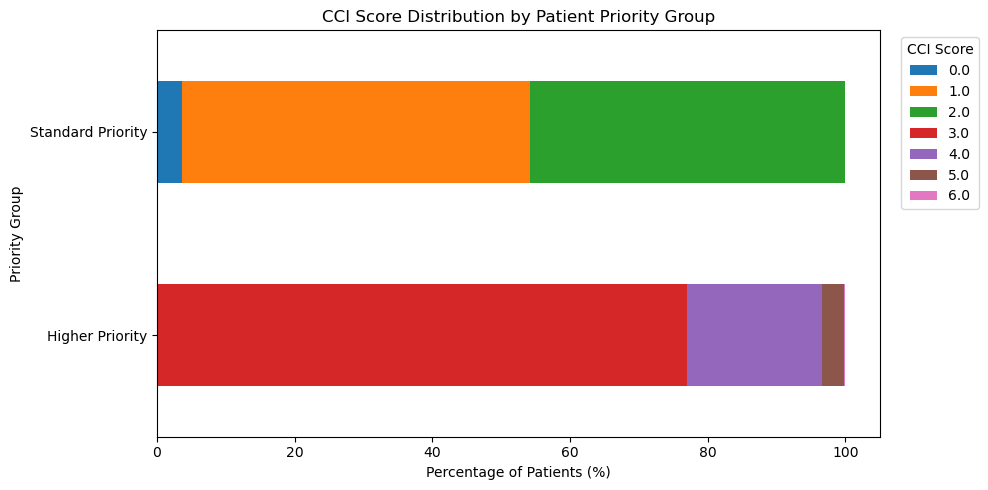

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Create priority group
df['priority_group'] = np.where(
    df['cci_score'] >= 3,
    'Higher Priority',
    'Standard Priority'
)

# Create cross-tabulation
priority_cci = pd.crosstab(
    df['priority_group'],
    df['cci_score'],
    normalize='index'
) * 100

# Plot
priority_cci.plot(
    kind='barh',
    stacked=True,
    figsize=(10, 5)
)

plt.title('CCI Score Distribution by Patient Priority Group')
plt.xlabel('Percentage of Patients (%)')
plt.ylabel('Priority Group')

plt.legend(
    title='CCI Score',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

### Key Insights
 The **Standard Priority** group contains patients with CCI scores of **0–2**, with scores **1 and 2** making up the majority of this group. The **Higher Priority** group contains patients with CCI scores of **3 or above* Within the Higher Priority group, **CCI score 3 is dominant**, representing roughly three-quarters of these patients, while scores **4 and 5** are less common. Very high CCI scores are rare, indicating that only a small proportion of patients have an extremely high comorbidity burden.


### Question 2: Which comorbidity combinations could be prioritized?
 Reasoning: Patients may have several chronic conditions simultaneously. Examining co-occurring diabetes and chronic kidney disease helps identify a subgroup with multiple important comorbidities that may warrant closer review in subsequent outcome analyses.

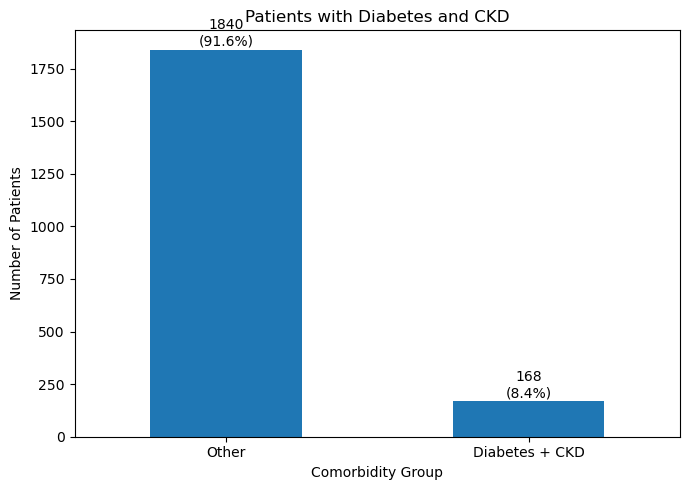

In [25]:
# visualization:

# Count patients in each group
group_counts = df['diabetes_ckd_group'].value_counts()

# Calculate percentages
group_percent = group_counts / group_counts.sum() * 100

# Create bar chart
ax = group_counts.plot(
    kind='bar',
    figsize=(7, 5)
)

plt.title('Patients with Diabetes and CKD')
plt.xlabel('Comorbidity Group')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)

# Add count and percentage labels
for i, count in enumerate(group_counts):
    percentage = group_percent.iloc[i]
    ax.text(
        i,
        count + 20,
        f'{count}\n({percentage:.1f}%)',
        ha='center'
    )

plt.tight_layout()
plt.show()

### Key Insights
 Out of **2,008 heart-failure patients**, **168 patients (8.4%)** have both **diabetes and moderate-to-severe chronic kidney disease (CKD)**. The remaining **1,840 patients (91.6%)** do not have this specific combination of conditions.This shows that approximately **1 in 12 patients** has both diabetes and CKD.Although this subgroup represents a relatively small proportion of the population, the combination identifies patients with **multiple important comorbidities**.

### Question 3: What is the distribution of CCI scores?
##### Reasoning: This describes whether the population is concentrated at lower or higher levels of overall comorbidity burden.

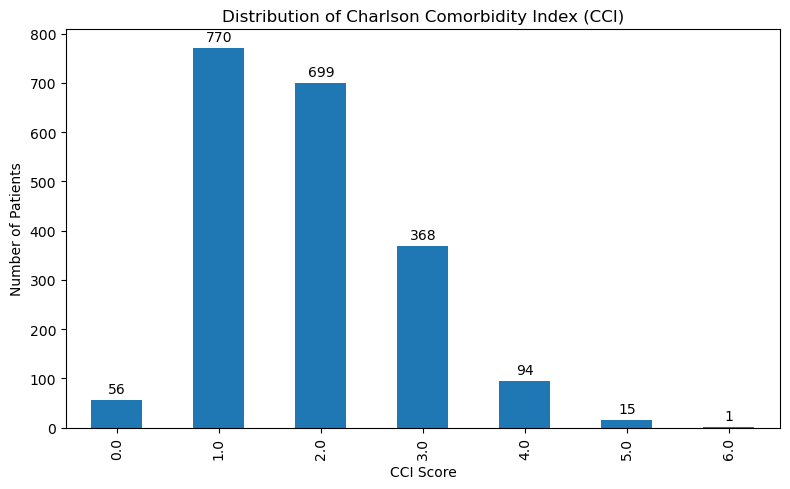

In [26]:
cci_distribution = (
    df['cci_score']
    .value_counts()
    .sort_index()
)

ax = cci_distribution.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Distribution of Charlson Comorbidity Index (CCI)')
plt.xlabel('CCI Score')
plt.ylabel('Number of Patients')

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

### Key Insights
The majority of heart-failure patients have relatively **low-to-moderate CCI scores**, with **CCI 1 (770 patients)** and **CCI 2 (699 patients)** being the most common. **368 patients** have a CCI score of **3**, while the number of patients decreases substantially at higher CCI scores.Only **94 patients** have a CCI score of 4, **15 patients** have a score of 5, and just **1 patient** has a score of 6.Overall, **478 patients (23.8%) have CCI scores of 3 or higher**, indicating that nearly **1 in 4 patients** falls into the higher-comorbidity-burden group based on the threshold used in this analysis. The distribution is concentrated around **CCI scores 1–2**, while very high comorbidity scores are relatively rare in this dataset.

In [37]:
combined = (
    df
    .merge(demography, on='inpatient_number', how='inner')
    .merge(cardiac, on='inpatient_number', how='inner')
    .merge(labs, on='inpatient_number', how='inner')
    .merge(responsiveness, on='inpatient_number', how='inner')
)

print("Rows:", combined.shape[0])
print("Columns:", combined.shape[1])

Rows: 2008
Columns: 148


In [38]:
combined.head()

,inpatient_number,cerebrovascular_disease,dementia,chronic_obstructive_pulmonary_disease,connective_tissue_disease,peptic_ulcer_disease,diabetes,moderate_to_severe_chronic_kidney_disease,hemiplegia,leukemia,...,partial_oxygen_pressure,oxyhemoglobin,anion_gap,free_calcium,total_hemoglobin,eye_opening,verbal_response,movement,consciousness,gcs
0,857781,0,0,1,0,0.0,1,0.0,0,0,...,93.0,95.9,17.8,1.14,125.0,4,5,6,Clear,15
1,743087,0,0,0,0,0.0,0,0.0,0,0,...,NaN,NaN,NaN,NaN,NaN,4,5,6,Clear,15
2,866418,0,0,0,0,0.0,0,0.0,0,0,...,NaN,NaN,NaN,NaN,NaN,4,5,6,Clear,15
3,775928,0,0,1,0,0.0,0,1.0,0,0,...,NaN,NaN,NaN,NaN,NaN,4,5,6,Clear,15
4,810128,0,0,0,0,0.0,0,0.0,0,0,...,NaN,NaN,NaN,NaN,NaN,4,5,6,Clear,15


In [39]:
combined.columns.tolist()

['inpatient_number',
 'cerebrovascular_disease',
 'dementia',
 'chronic_obstructive_pulmonary_disease',
 'connective_tissue_disease',
 'peptic_ulcer_disease',
 'diabetes',
 'moderate_to_severe_chronic_kidney_disease',
 'hemiplegia',
 'leukemia',
 'malignant_lymphoma',
 'solid_tumor',
 'liver_disease',
 'aids',
 'cci_score',
 'type_ii_respiratory_failure',
 'acute_renal_failure',
 'diabetes_ckd_group',
 'gender',
 'weight',
 'height',
 'bmi',
 'occupation',
 'agecat',
 'nyha_cardiac_function_classification',
 'killip_grade',
 'myocardial_infarction',
 'congestive_heart_failure',
 'peripheral_vascular_disease',
 'type_of_heart_failure',
 'lvef',
 'left_ventricular_end_diastolic_diameter_lv',
 'mitral_valve_ems',
 'mitral_valve_ams',
 'ea',
 'tricuspid_valve_return_velocity',
 'tricuspid_valve_return_pressure',
 'body_temperature',
 'pulse',
 'respiration',
 'systolic_blood_pressure',
 'diastolic_blood_pressure',
 'map_value',
 'fio2',
 'creatinine_enzymatic_method',
 'urea',
 'uric_acid'

### Question 4: Which patients have high comorbidity burden AND impaired cardiac function?
Reasoning: Comorbidity burden and cardiac function provide different information about patient complexity. Examining them together can identify patients who have multiple chronic conditions alongside impaired cardiac function.

In [40]:
cardiac.columns.tolist()

['inpatient_number',
 'nyha_cardiac_function_classification',
 'killip_grade',
 'myocardial_infarction',
 'congestive_heart_failure',
 'peripheral_vascular_disease',
 'type_of_heart_failure',
 'lvef',
 'left_ventricular_end_diastolic_diameter_lv',
 'mitral_valve_ems',
 'mitral_valve_ams',
 'ea',
 'tricuspid_valve_return_velocity',
 'tricuspid_valve_return_pressure']

In [41]:
combined[['cci_score', 'lvef']].describe()

,cci_score,lvef
count,2003.000000,635.000000
mean,1.861707,50.682992
std,0.961469,13.221701
min,0.000000,5.000000
25%,1.000000,41.000000
50%,2.000000,51.000000
75%,2.000000,61.000000
max,6.000000,82.000000


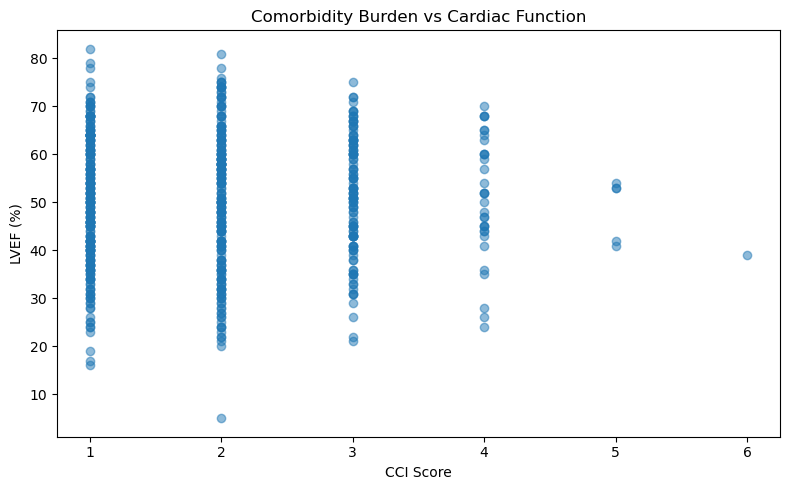

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    combined['cci_score'],
    combined['lvef'],
    alpha=0.5
)

plt.title('Comorbidity Burden vs Cardiac Function')
plt.xlabel('CCI Score')
plt.ylabel('LVEF (%)')

plt.tight_layout()
plt.show()

### Key Insights
LVEF values vary widely among patients with lower CCI scores, particularly for **CCI scores 1 and 2**, showing substantial variation in cardiac function within these groups.As CCI scores increase, the number of patients becomes much smaller, which is consistent with the CCI distribution in this dataset. Patients with **CCI scores 3 and 4** still show a broad range of LVEF values, so a clear decline in LVEF with increasing comorbidity burden is not visually evident.Very high CCI scores (**5–6**) contain only a few patients, so their LVEF values should be interpreted cautiously and should not be generalized to the overall population.

### Question 5: Which age groups have greater clinical complexity?
 Reasoning: Age can be examined together with comorbidity burden, cardiac function, and laboratory measurements to identify demographic groups with more complex clinical profiles.This information can support prioritization of groups for closer monitoring and further assessment.

In [44]:
age_summary = (
    combined.groupby('agecat')
    .agg(
        Patients=('inpatient_number', 'count'),
        Average_CCI=('cci_score', 'mean'),
        Median_CCI=('cci_score', 'median')
    )
)

age_summary.round(2)

,Patients,Average_CCI,Median_CCI
agecat,,,
21-29,4,1.00,1.0
29-39,12,1.33,1.0
39-49,56,1.62,1.0
49-59,106,1.59,1.0
59-69,368,1.77,2.0
69-79,715,1.89,2.0
79-89,646,1.93,2.0
89-110,101,2.04,2.0


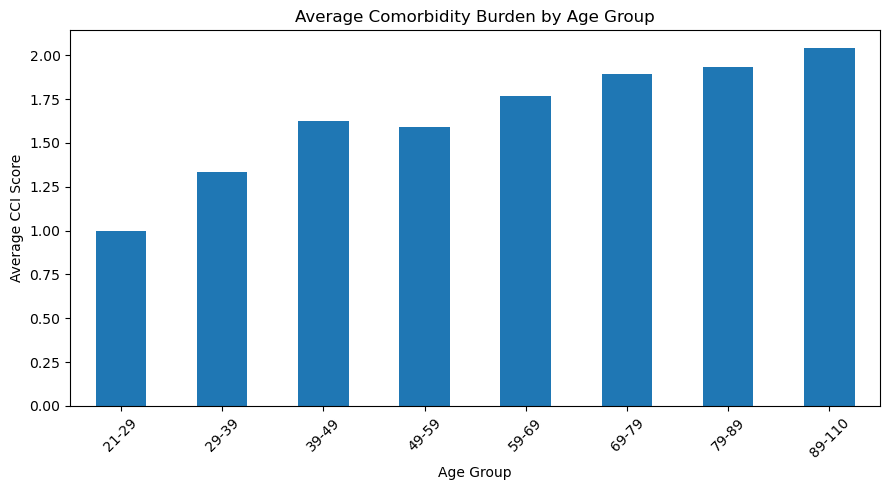

In [45]:
ax = age_summary['Average_CCI'].plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Average Comorbidity Burden by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average CCI Score')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Key Insights
 The **average CCI score generally increases with age**, indicating that older heart-failure patients tend to have a higher comorbidity burden.The **21–29 age group** has the lowest average CCI score at approximately **1.0**.
Average CCI gradually rises across the older age groups, reaching approximately **2.0 in the 89–110 age group**, the highest level observed.There is a small decrease between the **39–49 and 49–59 age groups**, but the overall pattern remains upward with increasing age.Patients aged **69 years and above** show comparatively higher average CCI scores, suggesting a greater concentration of coexisting health conditions in older patients.Overall, the analysis shows an **association between increasing age and greater comorbidity burden** in this heart-failure population.

### Qustion 6: Which kidney-related laboratory measurements are most strongly correlated?
 Reasoning: Creatinine, eGFR, and urea are commonly used to assess kidney function.Examining the correlations among these measurements helps identify how changes in one laboratory measure are associated with changes in another.Understanding these relationships can help identify groups of related kidney-function indicators that may be useful for closer monitoring of heart failure patients.

In [46]:
lab_vars = [
    'creatinine_enzymatic_method',
    'glomerular_filtration_rate',
    'urea'
]

correlation = combined[lab_vars].corr()

correlation.round(2)

,creatinine_enzymatic_method,glomerular_filtration_rate,urea
creatinine_enzymatic_method,1.00,-0.67,0.67
glomerular_filtration_rate,-0.67,1.00,-0.58
urea,0.67,-0.58,1.00


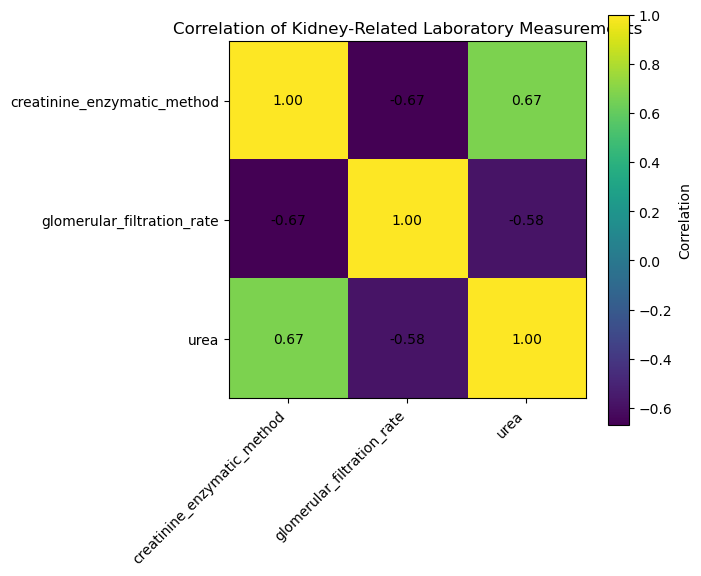

In [47]:
fig, ax = plt.subplots(figsize=(7, 6))

image = ax.imshow(correlation)

ax.set_xticks(range(len(lab_vars)))
ax.set_yticks(range(len(lab_vars)))

ax.set_xticklabels(lab_vars, rotation=45, ha='right')
ax.set_yticklabels(lab_vars)

for i in range(len(lab_vars)):
    for j in range(len(lab_vars)):
        ax.text(
            j,
            i,
            f'{correlation.iloc[i, j]:.2f}',
            ha='center',
            va='center'
        )

plt.colorbar(image, label='Correlation')
plt.title('Correlation of Kidney-Related Laboratory Measurements')

plt.tight_layout()
plt.show()

### Key Insights
 **Creatinine and urea show a positive correlation (0.67)**, indicating that higher creatinine levels tend to be associated with higher urea levels.**Creatinine and glomerular filtration rate (eGFR) show a negative correlation (-0.67)**, meaning that higher creatinine tends to be associated with lower kidney filtration rate.**Urea and eGFR also show a negative correlation (-0.58)**, suggesting that higher urea levels tend to occur alongside lower filtration rates.Among the relationships examined, **creatinine–urea and creatinine–eGFR show the strongest correlations**.

# Prescriptive Analysis — Heart Failure Inpatient Cohort
### Team7 CodeAvengers

This notebook turns 8 prescriptive-analysis questions into charts. Each section has:
- **Question** — the decision we're trying to inform
- **Chart** — the evidence
- **Reasoning / Recommendation** — what the chart implies we should *do*

> Update `path` in the setup cell below to the folder containing your 3 CSV files.


In [ ]:
# If you get "ModuleNotFoundError: No module named 'sklearn'", run this once:
# !pip install scikit-learn


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

%matplotlib inline
plt.rcParams["figure.dpi"] = 100

# --- Update this path to wherever your 3 CSV files live ---
path = "output/"   # e.g. "C:/Users/sandy/output/"

discharge = pd.read_csv(path + "Team7_CodeAvengers_Category1_DataCleaning_hospitalization_discharge.csv")
cardiac = pd.read_csv(path + "Team7_CodeAvengers_Category1_DataCleaning_cardiac_complications.csv")
responsiveness = pd.read_csv(path + "Team7_CodeAvengers_Category1_DataCleaning_responsivenes.csv")

df = discharge.merge(cardiac, on="inpatient_number").merge(responsiveness, on="inpatient_number")
df["admission_date"] = pd.to_datetime(df["admission_date"])
print(df.shape)
df.head()


(2008, 39)


,inpatient_number,destinationdischarge,admission_ward,admission_way,discharge_department,visit_times,respiratory_support,oxygen_inhalation,dischargeday,admission_date,...,mitral_valve_ems,mitral_valve_ams,ea,tricuspid_valve_return_velocity,tricuspid_valve_return_pressure,eye_opening,verbal_response,movement,consciousness,gcs
0,857781,Home,Cardiology,NonEmergency,Cardiology,1,NaN,OxygenTherapy,11,2017-01-24,...,NaN,NaN,NaN,NaN,NaN,4,5,6,Clear,15
1,743087,Home,Cardiology,NonEmergency,Cardiology,1,NaN,OxygenTherapy,8,2017-05-05,...,1.16,1.52,NaN,3.34,47.0,4,5,6,Clear,15
2,866418,Home,Cardiology,NonEmergency,Cardiology,2,NaN,OxygenTherapy,5,2016-11-18,...,0.84,0.12,7.00,2.80,32.0,4,5,6,Clear,15
3,775928,Home,Cardiology,Emergency,Cardiology,1,NaN,OxygenTherapy,11,2017-10-02,...,NaN,NaN,NaN,NaN,NaN,4,5,6,Clear,15
4,810128,Home,Cardiology,NonEmergency,Cardiology,1,NaN,OxygenTherapy,5,2019-11-17,...,1.20,0.90,1.33,NaN,NaN,4,5,6,Clear,15


## Q1 — Which patients should be flagged for a readmission-prevention protocol?

**Approach:** Train a simple logistic regression on admission-time severity features to score every
patient's 6-month readmission risk, then flag the top 20% for a proactive follow-up-call program.

**How to read the chart:** The red dashed line is the risk-score cutoff for the top 20% of patients.
Anyone to the right of it gets flagged.

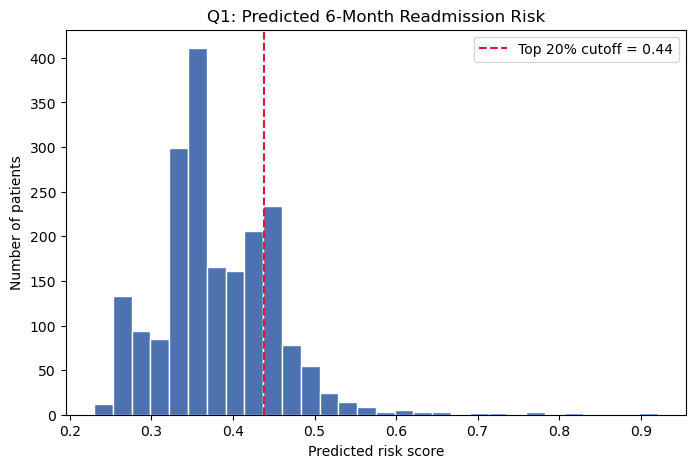

Patients flagged for follow-up program: 426 of 2008


In [9]:
features = ["nyha_cardiac_function_classification","killip_grade","myocardial_infarction",
            "congestive_heart_failure","peripheral_vascular_disease","dischargeday"]
data = df[features + ["re_admission_within_6_months"]].dropna()

X = data[features]
y = data["re_admission_within_6_months"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000).fit(X_train, y_train)
df["readmit_risk_score"] = model.predict_proba(df[features].fillna(df[features].median()))[:, 1]

threshold = df["readmit_risk_score"].quantile(0.8)
df["flag_for_followup"] = df["readmit_risk_score"] >= threshold

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["readmit_risk_score"], bins=30, color="#4C72B0", edgecolor="white")
ax.axvline(threshold, color="crimson", linestyle="--", label=f"Top 20% cutoff = {threshold:.2f}")
ax.set_title("Q1: Predicted 6-Month Readmission Risk")
ax.set_xlabel("Predicted risk score")
ax.set_ylabel("Number of patients")
ax.legend()
plt.show()

print(f"Patients flagged for follow-up program: {df['flag_for_followup'].sum()} of {len(df)}")


**Recommendation:** Enroll the ~20% of patients above the cutoff in a structured post-discharge
follow-up program (phone check-in within 72 hours, med-reconciliation review). This concentrates limited
care-management resources on the patients statistically most likely to bounce back.

## Q2 — What Killip/NYHA combination should trigger ICU-level monitoring?

**Approach:** Cross-tabulate 28-day mortality by Killip grade (physical exam severity) and NYHA class
(functional severity), restricted to combinations with at least 10 patients so the rates aren't noise.

**How to read the chart:** Darker cells = higher 28-day mortality %. Each cell is labeled with its rate.

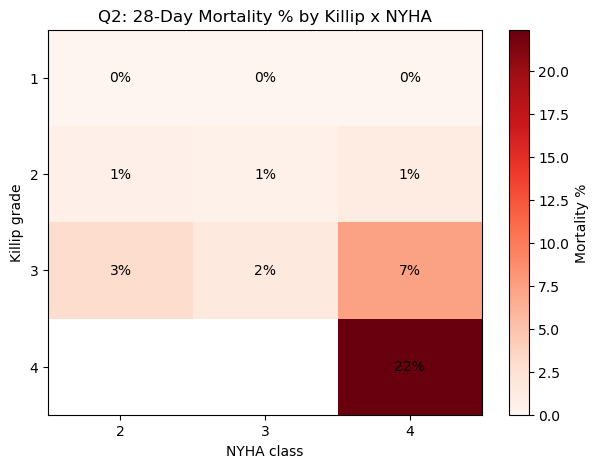

In [2]:
risk_table = df.groupby(["killip_grade", "nyha_cardiac_function_classification"])["death_within_28_days"] \
                .agg(["mean", "count"]).reset_index()
risk_table = risk_table[risk_table["count"] >= 10]
pivot = risk_table.pivot(index="killip_grade", columns="nyha_cardiac_function_classification", values="mean") * 100

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(pivot.values, cmap="Reds", aspect="auto")
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0f}%", ha="center", va="center", color="black")
ax.set_xlabel("NYHA class"); ax.set_ylabel("Killip grade")
ax.set_title("Q2: 28-Day Mortality % by Killip x NYHA")
fig.colorbar(im, ax=ax, label="Mortality %")
plt.show()


**Recommendation:** Killip grade 4 (any NYHA class) and Killip grade 3 + NYHA class 4 show sharply
elevated mortality (>7%, jumping to >20% at Killip 4). Set the ICU-escalation rule at **Killip grade ≥ 3
combined with NYHA class 4**, rather than using either scale alone — neither is a strong signal by
itself, but the combination is.

## Q3 — What LVEF cutoff should trigger a mandatory cardiology referral before discharge?

**Approach:** Bin LVEF (ejection fraction, measured by echo) into clinically standard bands and compare
6-month mortality and readmission across them.

**How to read the chart:** Two bars per LVEF band — mortality (red) and readmission (blue).

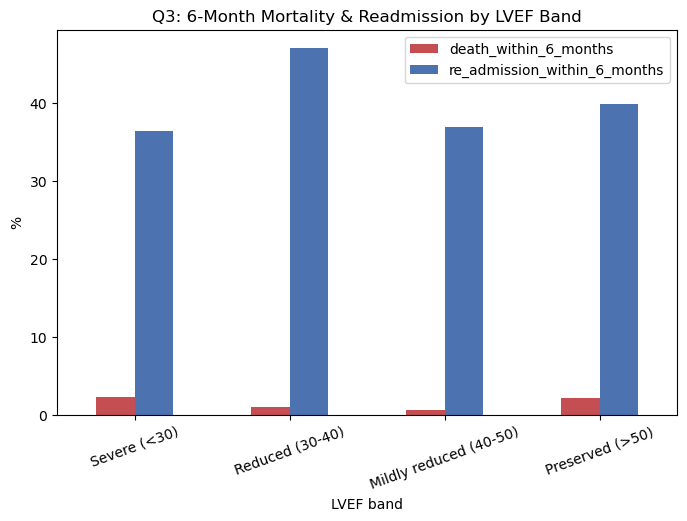

,death_within_6_months,re_admission_within_6_months
lvef_bin,,
Severe (<30),2.272727,36.363636
Reduced (30-40),0.980392,47.058824
Mildly reduced (40-50),0.625000,36.875000
Preserved (>50),2.127660,39.817629


In [3]:
df["lvef_bin"] = pd.cut(df["lvef"], bins=[0, 30, 40, 50, 100],
                         labels=["Severe (<30)", "Reduced (30-40)", "Mildly reduced (40-50)", "Preserved (>50)"])
q3 = df.groupby("lvef_bin", observed=True)[["death_within_6_months", "re_admission_within_6_months"]].mean() * 100

fig, ax = plt.subplots(figsize=(8, 5))
q3.plot(kind="bar", ax=ax, color=["#C44E52", "#4C72B0"])
ax.set_title("Q3: 6-Month Mortality & Readmission by LVEF Band")
ax.set_ylabel("%"); ax.set_xlabel("LVEF band")
plt.xticks(rotation=20)
plt.show()
q3


**Recommendation:** Readmission risk stays high (36–47%) across *every* LVEF band, including
"Preserved" — so LVEF alone is a weak discharge-referral trigger in this cohort. The more actionable
finding is that readmission risk never drops below ~35% regardless of ejection fraction, which points to a
broader recommendation: **every heart-failure discharge should get a cardiology follow-up appointment
within 7–14 days, not just those with reduced LVEF.**

**Recommendation:** Patients discharged **Home** with Killip grade 4 have the highest readmission
rate (~58%), even higher than those sent to a HealthcareFacility. This suggests Killip 4 patients
currently sent home would benefit from routing to a step-down/rehab facility instead, or at minimum a
mandatory home-health nursing visit within 48 hours of discharge.

## Q4 — How should ward staffing/resources be allocated based on volume and risk?

**Approach:** Plot monthly admission volume by ward alongside 28-day mortality rate by ward, side by
side, to see where volume and risk overlap.

**How to read the chart:** Left panel = admission trend lines per ward over time. Right panel = mortality
rate per ward (bar).

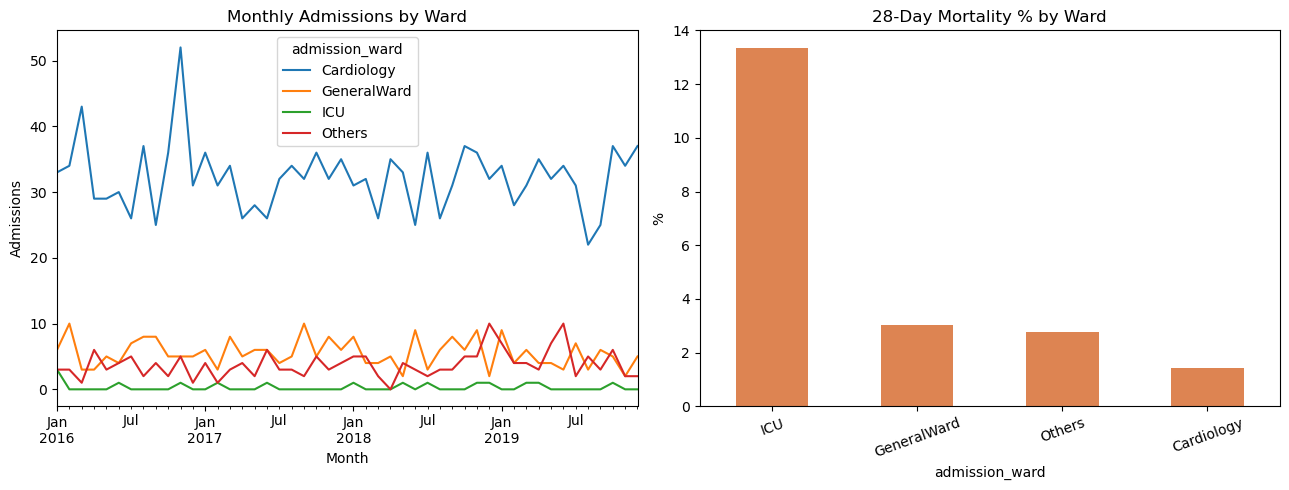

admission_ward
ICU            13.333333
GeneralWard     3.018868
Others          2.762431
Cardiology      1.422107
Name: death_within_28_days, dtype: float64

In [8]:
monthly_by_ward = df.groupby([df["admission_date"].dt.to_period("M"), "admission_ward"]).size().unstack(fill_value=0)
ward_risk = df.groupby("admission_ward")["death_within_28_days"].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
monthly_by_ward.plot(ax=axes[0])
axes[0].set_title("Monthly Admissions by Ward")
axes[0].set_xlabel("Month"); axes[0].set_ylabel("Admissions")

ward_risk.sort_values(ascending=False).plot(kind="bar", ax=axes[1], color="#DD8452")
axes[1].set_title("28-Day Mortality % by Ward")
axes[1].set_ylabel("%")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
ward_risk.sort_values(ascending=False)


**Recommendation:** ICU has by far the highest 28-day mortality rate (~13%) despite typically lower
volume than Cardiology or GeneralWard. This supports **prioritizing nurse-to-patient ratio and senior
physician coverage in the ICU over raw volume-based staffing**, since ICU patients carry disproportionate
risk per admission even when their headcount is smaller.

---
## Summary of Recommendations
1. Enroll top 20% by predicted risk score in a post-discharge follow-up program
2. Escalate Killip ≥3 + NYHA 4 to ICU-level monitoring
3. Schedule cardiology follow-up for *all* HF discharges within 7-14 days, not just low-LVEF patients
4. Route Killip grade 4 patients to a facility/step-down unit rather than home, or add mandatory home-health visits
5. Use discharge-readiness criteria rather than a fixed LOS rule for high-risk patients
6. Mandate LVEF/echo testing for all Killip grade ≥ 2 patients
7. Auto-trigger cardiology fast-track consult for any GCS < 15 on arrival, regardless of admission type
8. Weight ICU staffing by risk-per-admission, not just patient volume


Q5. How did admission volume trended over time? (uses admission_date)

C:\Users\sandy\AppData\Local\Temp\ipykernel_14792\2893101521.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.set_index("admission_date").resample("M").size().plot(title="Admissions per Month")


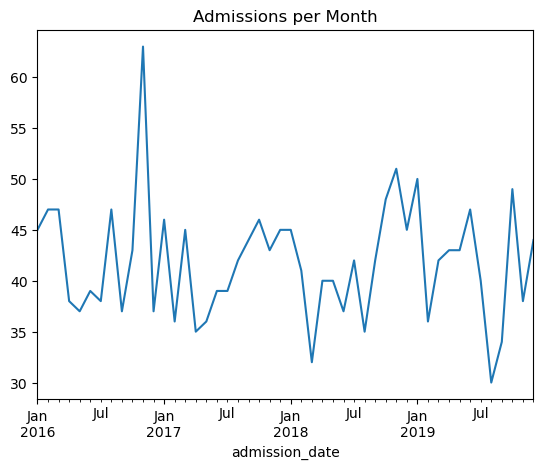

In [12]:
df["admission_date"] = pd.to_datetime(df["admission_date"])
df.set_index("admission_date").resample("M").size().plot(title="Admissions per Month")
plt.show()

Q6: How does LVEF (ejection fraction) vary by type of heart failure (Left/Right/Both)?

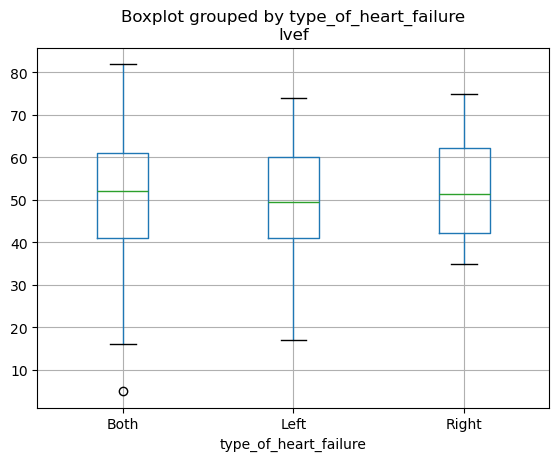

In [13]:
df.groupby("type_of_heart_failure")["lvef"].describe()
df.boxplot(column="lvef", by="type_of_heart_failure")
plt.show()